# Task

- Implement and train an unconditional Diffusion Model using DDPM
- Implement DDIM for faster inference
- Use pixel-space training on the MNIST dataset
- Evaluate sample quality by generated images across diffusion steps for both DDPM and DDIM
- (bonus) Implement DeepCache for the U-Net backbone. Explore how reducing recomputation (skipping steps) influences inference speed and final image quality

# Disclaimer

This notebook is both an implementation and a report with visualizations and justifications of approaches and results. There is no separate final report due to the inconvenience of reproducing the same structure in pdf.

# Imports

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm.auto import tqdm
import math
import time
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data Preparation

In [2]:
def get_mnist_loaders(
    dataset: str = "mnist",
    data_root: str = "./data",
    batch_size: int = 128,
    val_split: float = 0.1,
):
    if dataset == "mnist":
        DatasetClass = datasets.MNIST
    else:
        DatasetClass = datasets.FashionMNIST

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),  # (x - 0.5) / 0.5 -> [-1, 1]
    ])

    full_train = DatasetClass(root=data_root, train=True, download=True, transform=transform)
    test_ds = DatasetClass(root=data_root, train=False, download=True, transform=transform)

    n_total = len(full_train)
    n_val = int(n_total * val_split)
    n_train = n_total - n_val

    print(f"\n--- {dataset.upper()} DATASET ---")
    print(f"Total train images: {n_total}")
    print(f"  Train split:      {n_train}")
    print(f"  Validation split: {n_val}")
    print(f"Test set size:      {len(test_ds)}\n")

    train_ds, val_ds = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


def show_samples(loader, title: str):
    x, y = next(iter(loader))
    x, y = x[:4], y[:4]
    fig, axes = plt.subplots(1, 4, figsize=(8, 2))
    fig.suptitle(title)
    for i in range(4):
        axes[i].imshow(x[i].squeeze(0), cmap="gray")
        axes[i].set_title(f"label: {y[i].item()}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.17MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.97MB/s]



--- MNIST DATASET ---
Total train images: 60000
  Train split:      54000
  Validation split: 6000
Test set size:      10000



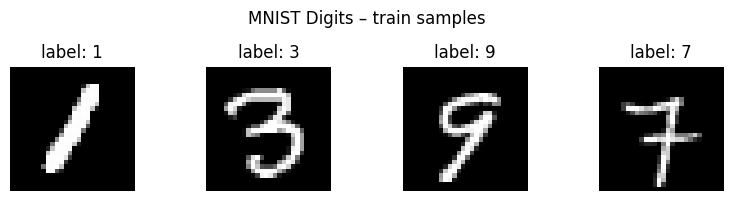

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.5MB/s]



--- FASHION DATASET ---
Total train images: 60000
  Train split:      54000
  Validation split: 6000
Test set size:      10000



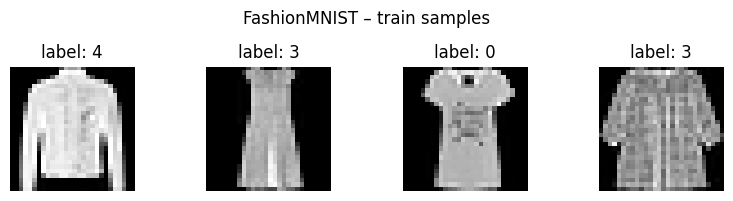

In [3]:
train_digits, val_digits, test_digits = get_mnist_loaders(dataset="mnist", batch_size=128)
show_samples(train_digits, "MNIST Digits – train samples")

train_fashion, val_fashion, test_fashion = get_mnist_loaders(dataset="fashion", batch_size=128)
show_samples(train_fashion, "FashionMNIST – train samples")

# General Helpers

## Visualization

In [4]:
def denormalize(x: torch.Tensor) -> torch.Tensor:
    """Convert images from [-1, 1] back to [0, 1]."""
    return (x.clamp(-1, 1) + 1) / 2


def show_generated_grid(
    samples: torch.Tensor,
    nrow: int = 8,
    title: str = "Generated Samples",
    figsize: Tuple = (10, 10),
):
    """Display a grid of generated images."""
    samples = denormalize(samples).cpu()
    n = samples.shape[0]
    ncol = min(nrow, n)
    nrows = math.ceil(n / ncol)

    fig, axes = plt.subplots(nrows, ncol, figsize=figsize)
    if nrows == 1:
        axes = axes[None, :]
    fig.suptitle(title, fontsize=14)

    for i in range(nrows):
        for j in range(ncol):
            idx = i * ncol + j
            if idx < n:
                axes[i, j].imshow(samples[idx].squeeze(0), cmap="gray")
            axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()


def show_denoising_process(
    intermediates: List[torch.Tensor],
    step_labels: List[str],
    n_samples: int = 4,
    title: str = "Denoising Process",
):
    """Visualize intermediate denoising steps.

    Args:
        intermediates: list of (B, 1, 28, 28) tensors at various steps.
        step_labels:   labels for each column (e.g., "t=1000", "t=500", ...).
    """
    n_steps = len(intermediates)
    fig, axes = plt.subplots(n_samples, n_steps, figsize=(2 * n_steps, 2 * n_samples))
    if n_samples == 1:
        axes = axes[None, :]
    fig.suptitle(title, fontsize=14)

    for col, (imgs, label) in enumerate(zip(intermediates, step_labels)):
        imgs = denormalize(imgs).cpu()
        for row in range(n_samples):
            axes[row, col].imshow(imgs[row].squeeze(0), cmap="gray")
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(label, fontsize=10)
    plt.tight_layout()
    plt.show()


def plot_losses(train_losses: list, val_losses: list, title: str = "Training & Validation Loss"):
    """Plot training and validation loss curves."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_losses, label="Train Loss")
    ax.plot(val_losses, label="Val Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Training

**What is EMA (Exponential Moving Average)**

Instead of using the *current* weights $\theta_t$ directly for sampling, we keep a second set of weights $s_t$ (also called shadow) that changes more slowly and averages the recent history of model parameters. As the diffusion training process can be noisy because of model parameters, that slightly jump after each optimizer step due to stochastic gradients like different mini-batches and Adam/SGD noise, EMA provides and typically produces better samples.


**1) Recursive (update) formula:**

Let:
- $\theta_t$ be the model parameters after the $t$-th optimizer update
- $s_t$ be the EMA (shadow) parameters
- $\beta \in [0,1)$ be the decay ($0.9999$)

The EMA update is:

$$
s_t = \beta\, s_{t-1} + (1-\beta)\, \theta_t
$$

Or in code:

$$
\text{shadow} \leftarrow \beta \cdot \text{shadow} + (1-\beta)\cdot \text{current_weights}
$$

**2) Expanded (closed-form) standard formula:**

If we recursively expand the update rule, we get:

$$
s_t = (1-\beta)\sum_{k=0}^{t}\beta^{k}\,\theta_{t-k} \;+\; \beta^{t+1}s_{-1}
$$

If we initialize $s_0 \approx \theta_0$, then after a few steps the term $\beta^{t+1}s_{-1}$ becomes negligible, and we can interpret EMA as:

$$
s_t \approx (1-\beta)\left(\theta_t + \beta\theta_{t-1} + \beta^2\theta_{t-2} + \dots\right)
$$

So, EMA is a weighted average of all past parameter vectors, where older parameters have exponentially smaller weights.


**3) Example**

This shows explicitly how $s_3$ contains information about $\theta_1, \theta_2, \theta_3$, with older weights downweighted by powers of $\beta$

1. Assume we start EMA from the first weights $s_1 = \theta_1$
2. Then $s_2 = \beta s_1 + (1-\beta)\theta_2 = \beta\theta_1 + (1-\beta)\theta_2$
3. $s_3 = \beta s_2 + (1-\beta)\theta_3 \rightarrow \text{substitute} s_2 \rightarrow s_3 = \beta(\beta\theta_1 + (1-\beta)\theta_2) + (1-\beta)\theta_3 \rightarrow \text{distribute} \beta \rightarrow s_3 = \beta^2\theta_1 + \beta(1-\beta)\theta_2 + (1-\beta)\theta_3$

In [5]:
@dataclass
class TrainConfig:
    epochs: int = 30
    lr: float = 2e-4
    grad_clip: float = 1.0
    ema_decay: float = 0.9999


class EMA:
    """Exponential Moving Average for model parameters"""
    def __init__(self, model: nn.Module, decay: float = 0.9999):
        self.decay = decay
        self.shadow = {
            name: p.clone().detach()
            for name, p in model.named_parameters() if p.requires_grad
        }

    @torch.no_grad()
    def update(self, model: nn.Module):
        for name, p in model.named_parameters():
            if p.requires_grad and name in self.shadow:
                self.shadow[name].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    def apply(self, model: nn.Module):
        """Copy EMA weights into model (for inference)"""
        self.backup = {name: p.data.clone() for name, p in model.named_parameters() if p.requires_grad}
        for name, p in model.named_parameters():
            if name in self.shadow:
                p.data.copy_(self.shadow[name])

    def restore(self, model: nn.Module):
        """Restore original weights from backup"""
        for name, p in model.named_parameters():
            if name in self.backup:
                p.data.copy_(self.backup[name])

# DDPM (Denoising Diffusion Probabilistic Model)

[DDPM](https://arxiv.org/pdf/2006.11239) defines a forward (noising) and learned reverse (denoising) process.

**Forward process**

Gradually adds Gaussian noise over $t$ timesteps:

$$q(x_t \mid x_{t-1}) = N\bigl(x_t;\; \sqrt{1 - \beta_t}\, x_{t-1},\; \beta_t \mathbf{I}\bigr)$$

Thanks to the [reparameterization trick](https://arxiv.org/pdf/1312.6114.pdf#page=4), we can jump directly from $x_0$ to any $x_t$:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon, \quad \varepsilon \sim N(0, \mathbf{I})$$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$.

**Reverse process**

A neural network $\epsilon_\theta(x_t, t)$ predicts the noise:

$$\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}}\Bigl(x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}\, \epsilon_\theta(x_t, t)\Bigr)$$

## Noise Schedule

## Noise Schedule (DDPM) — what it is and what this class precomputes

Specifies how much Gaussian noise is injected at each diffusion step
$t \in \{1, \dots, T\}$. The schedule is typically defined through a sequence of variances $\{\beta_t\}$, which controls how quickly a clean image $x_0$ is transformed into (almost) pure noise as $t$ increases.

This notebook uses a **linear $\beta_t$ schedule**, matching the [common baseline](https://arxiv.org/pdf/2006.11239.pdf#page=14) from *Denoising Diffusion Probabilistic Models* (Jonathan Ho, Ajay Jain, Pieter Abbeel), so that $\beta_t$ increases linearly $\beta_t = \text{linspace}(\beta_{\text{start}}, \beta_{\text{end}}, T)$ with default values: $T = 1000,\quad \beta_1 = 10^{-4},\quad \beta_T = 0.02$.

The forward (noising) process is implemented in `q_sample(x0, t)` with the exact closed form equation $x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1 - \bar{\alpha}_t}\,\epsilon$, and retun the noisy image $x_t$ and the noise $\epsilon$ that was used (useful because the model is trained to predict this $\epsilon$).

During reverse sampling, in order to obtain the variance of the posterior $q(x_{t-1} \mid x_t, x_0)$, this schedule class precomputes the [standard DDPM posterior variance](https://arxiv.org/pdf/2006.11239.pdf#page=3):
$$
\tilde{\beta}_t
=
\beta_t \cdot \frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}
$$
(and its log, with numerical clamping), which is used when adding stochasticity during the reverse process.

In [6]:
class NoiseSchedule:
    """Precomputes all diffusion constants for a linear beta schedule and proceed froward step"""

    def __init__(
        self,
        T: int = 1000,
        beta_start: float = 1e-4,
        beta_end: float = 0.02,
        device: str = "cpu",
    ):
        self.T = T
        self.device = device

        # linear schedule
        betas = torch.linspace(beta_start, beta_end, T, device=device)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.0)

        self.betas = betas
        self.alphas = alphas
        self.alpha_bar = alpha_bar
        self.alpha_bar_prev = alpha_bar_prev

        self.sqrt_alpha_bar = torch.sqrt(alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)
        self.sqrt_recip_alpha = torch.sqrt(1.0 / alphas)

        # posterior variance for sampling
        self.posterior_variance = betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)
        self.posterior_log_variance = torch.log(self.posterior_variance.clamp(min=1e-20))

    def _extract(self, arr: torch.Tensor, t: torch.Tensor, x_shape: tuple) -> torch.Tensor:
        """Gather values from `arr` at indices `t` and reshape for broadcasting over (B, C, H, W)"""
        batch_size = t.shape[0]
        out = arr.gather(-1, t)
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: Optional[torch.Tensor] = None):
        """Forward diffusion: sample x_t given x_0"""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ab = self._extract(self.sqrt_alpha_bar, t, x0.shape)
        sqrt_1_ab = self._extract(self.sqrt_one_minus_alpha_bar, t, x0.shape)
        return sqrt_ab * x0 + sqrt_1_ab * noise, noise

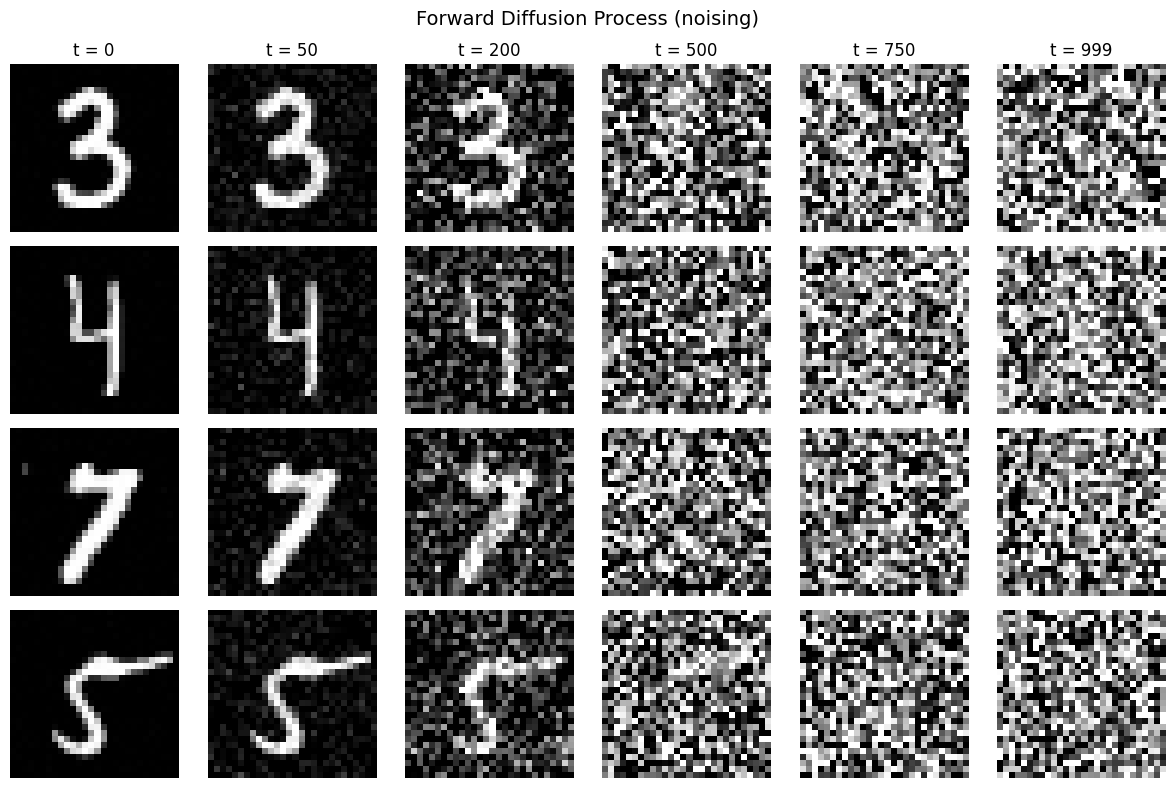

In [7]:
# sanity check: visualize the forward noising process
ns_vis = NoiseSchedule(T=1000, device="cpu")
x_sample, _ = next(iter(train_digits))
x0 = x_sample[:4]

fig, axes = plt.subplots(4, 6, figsize=(12, 8))
timesteps_to_show = [0, 50, 200, 500, 750, 999]

for row in range(4):
    for col, t_val in enumerate(timesteps_to_show):
        t = torch.tensor([t_val])
        xt, _ = ns_vis.q_sample(x0[row:row+1], t)
        img = denormalize(xt[0]).squeeze(0)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"t = {t_val}")

fig.suptitle("Forward Diffusion Process (noising)", fontsize=14)
plt.tight_layout()
plt.show()

## U-Net Architecture

U-Net noise predictor $\epsilon_\theta(x_t, t)$ uses:
- Sinusoidal time embeddings to condition on the timestep (same as in *Attention Is All You Need*)
- Residual blocks with GroupNorm and SiLU activations
- Self-attention at the 7×7 bottleneck resolution (same as in *Attention Is All You Need*)
- Skip connections between encoder and decoder

The architecture is sized for MNIST: 28×28 → 14×14 → 7×7 (attention) → 14×14 → 28×28.

Channel progression: 1 → 64 → 128 → 256 → 128 → 64 → 1.

**Important for DeepCache**

We split the forward pass into forward_encoder,
forward_bottleneck, and forward_decoder so that the encoder/bottleneck features
can be cached and the decoder rerun cheaply with stale features.

`forward_with_cache` method handles the caching logic: on full steps it runs everything and stores encoder+bottleneck outputs; on cached steps it skips them entirely and only re-runs the decoder with stale spatial features but the current time embedding.

In [10]:
class SinusoidalPosEmb(nn.Module):
    """Sinusoidal positional embedding for the diffusion timestep"""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device = t.device
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ResBlock(nn.Module):
    """Residual block with time conditioning via additive bias"""
    def __init__(self, in_ch: int, out_ch: int, time_dim: int, dropout: float = 0.1):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
        )
        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch),
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
        )
        self.skip_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.block1(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]  # broadcast (B, C) -> (B, C, 1, 1)
        h = self.block2(h)
        return h + self.skip_conv(x)


class SelfAttention(nn.Module):
    """
    Single-head self-attention over spatial dimensions

    Applied at the bottleneck (7×7) where the spatial size is small enough
    that the O(n^2) cost is manageable
    """
    def __init__(self, channels: int):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        self.scale = channels ** -0.5

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]

        attn = (q.transpose(-1, -2) @ k) * self.scale
        attn = attn.softmax(dim=-1)
        out = (v @ attn.transpose(-1, -2)).reshape(B, C, H, W)
        return x + self.proj(out)


class UNet(nn.Module):
    """U-Net noise prediction network for MNIST (28x28 grayscale)"""
    def __init__(self, in_ch: int = 1, base_ch: int = 64, time_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        ch1, ch2, ch3 = base_ch, base_ch * 2, base_ch * 4  # 64, 128, 256

        # time embedding MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # encoder
        self.conv_in = nn.Conv2d(in_ch, ch1, 3, padding=1)

        self.down1_res1 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_res2 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_pool = nn.Conv2d(ch1, ch1, 3, stride=2, padding=1)  # 28->14

        self.down2_res1 = ResBlock(ch1, ch2, time_dim, dropout)
        self.down2_res2 = ResBlock(ch2, ch2, time_dim, dropout)
        self.down2_pool = nn.Conv2d(ch2, ch2, 3, stride=2, padding=1)  # 14->7

        # bottleneck (7x7 with attention)
        self.mid_res1 = ResBlock(ch2, ch3, time_dim, dropout)
        self.mid_attn = SelfAttention(ch3)
        self.mid_res2 = ResBlock(ch3, ch3, time_dim, dropout)

        # decoder
        self.up2_upsample = nn.ConvTranspose2d(ch3, ch3, 4, stride=2, padding=1)  # 7->14
        self.up2_res1 = ResBlock(ch3 + ch2, ch2, time_dim, dropout)
        self.up2_res2 = ResBlock(ch2, ch2, time_dim, dropout)

        self.up1_upsample = nn.ConvTranspose2d(ch2, ch2, 4, stride=2, padding=1)  # 14->28
        self.up1_res1 = ResBlock(ch2 + ch1, ch1, time_dim, dropout)
        self.up1_res2 = ResBlock(ch1, ch1, time_dim, dropout)

        # output
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, ch1),
            nn.SiLU(),
            nn.Conv2d(ch1, in_ch, 3, padding=1),
        )

    def forward_encoder(self, x: torch.Tensor, t_emb: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Run encoder: returns (bottleneck_input, skip1, skip2)"""
        h = self.conv_in(x)                            # (B, 64, 28, 28)
        h1 = self.down1_res1(h, t_emb)
        h1 = self.down1_res2(h1, t_emb)                # skip-1
        h = self.down1_pool(h1)                         # (B, 64, 14, 14)

        h2 = self.down2_res1(h, t_emb)
        h2 = self.down2_res2(h2, t_emb)                # skip-2
        h = self.down2_pool(h2)                         # (B, 128, 7, 7)
        return h, h1, h2

    def forward_bottleneck(self, h: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        """Run bottleneck: attention at 7x7"""
        h = self.mid_res1(h, t_emb)                    # (B, 256, 7, 7)
        h = self.mid_attn(h)
        h = self.mid_res2(h, t_emb)
        return h

    def forward_decoder(self, h: torch.Tensor, h1: torch.Tensor, h2: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        """Run decoder with skip connections -> output"""
        h = self.up2_upsample(h)                       # (B, 256, 14, 14)
        h = torch.cat([h, h2], dim=1)                  # (B, 384, 14, 14)
        h = self.up2_res1(h, t_emb)
        h = self.up2_res2(h, t_emb)                    # (B, 128, 14, 14)

        h = self.up1_upsample(h)                       # (B, 128, 28, 28)
        h = torch.cat([h, h1], dim=1)                  # (B, 192, 28, 28)
        h = self.up1_res1(h, t_emb)
        h = self.up1_res2(h, t_emb)                    # (B, 64, 28, 28)

        return self.conv_out(h)                        # (B, 1, 28, 28)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """Full forward pass (used during training)"""
        t_emb = self.time_mlp(t)
        h, h1, h2 = self.forward_encoder(x, t_emb)
        h = self.forward_bottleneck(h, t_emb)
        return self.forward_decoder(h, h1, h2, t_emb)

    def forward_with_cache(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
        use_cache: bool = False,
        cache: Optional[Dict[str, torch.Tensor]] = None,
    ) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        """Forward pass with DeepCache support"""
        t_emb = self.time_mlp(t)

        if use_cache and cache is not None:
            # cached step: skip encoder + bottleneck, reuse features
            output = self.forward_decoder(cache["h_bottleneck"], cache["h1"], cache["h2"], t_emb)
            new_cache = cache  # keep the same cache
        else:
            # full step: run everything, store features in cache
            h, h1, h2 = self.forward_encoder(x, t_emb)
            h_bottleneck = self.forward_bottleneck(h, t_emb)
            output = self.forward_decoder(h_bottleneck, h1, h2, t_emb)
            new_cache = {"h_bottleneck": h_bottleneck, "h1": h1, "h2": h2}

        return output, new_cache

In [11]:
# sanity check: verify model
model_test = UNet().to(device)
n_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"U-Net parameters: {n_params:,}")

with torch.no_grad():
    dummy_x = torch.randn(2, 1, 28, 28, device=device)
    dummy_t = torch.randint(0, 1000, (2,), device=device)
    out = model_test(dummy_x, dummy_t)
    print(f"Input:  {dummy_x.shape}")
    print(f"Output: {out.shape}")
    assert out.shape == dummy_x.shape
    print("Standard forward OK")

with torch.no_grad():
    out_full, cache = model_test.forward_with_cache(dummy_x, dummy_t, use_cache=False)
    out_cached, _ = model_test.forward_with_cache(dummy_x, dummy_t, use_cache=True, cache=cache)
    print(f"Full output:   {out_full.shape}")
    print(f"Cached output: {out_cached.shape}")
    print("Cached forward OK")

del model_test

U-Net parameters: 6,166,081
Input:  torch.Size([2, 1, 28, 28])
Output: torch.Size([2, 1, 28, 28])
Standard forward OK
Full output:   torch.Size([2, 1, 28, 28])
Cached output: torch.Size([2, 1, 28, 28])
Cached forward OK


## DDPM Training

1. Sample a batch of clean images $x_0$
2. Sample random timesteps $t \sim \text{Uniform}(0, T{-}1)$
3. Sample noise $\varepsilon \sim N(0, I)$
4. Compute noisy images $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1{-}\bar\alpha_t}\, \varepsilon$
5. Predict noise $\hat\varepsilon = \epsilon_\theta(x_t, t)$
6. Minimize MSE: $\| \varepsilon - \hat\varepsilon \|^2$

> We use EMA (Exponential Moving Average) of weights for better sample quality at inference.

In [12]:
def train_diffusion(
    model: nn.Module,
    noise_schedule: NoiseSchedule,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config: TrainConfig = TrainConfig(),
    device: str = "cuda",
) -> Tuple[nn.Module, dict]:
    """
    Returns:
        model
        history dict with train_loss, val_loss lists
    """
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    ema = EMA(model, decay=config.ema_decay)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(config.epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.epochs}")
        for x0, _ in pbar:
            x0 = x0.to(device)
            B = x0.shape[0]

            # sample random timesteps and noise
            t = torch.randint(0, noise_schedule.T, (B,), device=device)
            noise = torch.randn_like(x0)

            # forward diffusion get noisy x_t
            xt, _ = noise_schedule.q_sample(x0, t, noise)

            # predict noise
            noise_pred = model(xt, t)
            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()
            ema.update(model)

            epoch_loss += loss.item()
            n_batches += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train = epoch_loss / n_batches

        # validation
        model.eval()
        val_loss = 0.0
        val_batches = 0
        with torch.no_grad():
            for x0, _ in val_loader:
                x0 = x0.to(device)
                B = x0.shape[0]
                t = torch.randint(0, noise_schedule.T, (B,), device=device)
                noise = torch.randn_like(x0)
                xt, _ = noise_schedule.q_sample(x0, t, noise)
                noise_pred = model(xt, t)
                val_loss += F.mse_loss(noise_pred, noise).item()
                val_batches += 1

        avg_val = val_loss / val_batches
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)

        print(f"  => train_loss: {avg_train:.4f}  val_loss: {avg_val:.4f}")

    # EMA weights for inference
    ema.apply(model)
    return model, history

## DDPM Sampling

Starting from pure noise $x_T \sim N(0, I)$, we iteratively denoise for all T steps:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Bigl(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}} \epsilon_\theta(x_t,t)\Bigr) + \sigma_t z$$

where $z \sim N(0, I)$ for $t > 1$ and $z = 0$ for $t = 1$.

This requires all T=1000 model evaluations, which is slow. DDIM (next section) will fix this.

In [13]:
@torch.no_grad()
def ddpm_sample(
    model: nn.Module,
    noise_schedule: NoiseSchedule,
    n_samples: int = 64,
    img_shape: tuple = (1, 28, 28),
    device: str = "cuda",
    return_intermediates: bool = False, # if True, also returns snapshots at specified timesteps
    intermediate_steps: Optional[List[int]] = None, # timesteps to save
) -> torch.Tensor:
    """Generate samples using DDPM reverse process (full T steps)"""
    model.eval()
    ns = noise_schedule

    # Gaussian noise
    x = torch.randn(n_samples, *img_shape, device=device)

    intermediates = []
    if intermediate_steps is None:
        intermediate_steps = [ns.T - 1, ns.T * 3 // 4, ns.T // 2, ns.T // 4, 0]

    for t_val in tqdm(reversed(range(ns.T)), total=ns.T, desc="DDPM Sampling"):
        t = torch.full((n_samples,), t_val, device=device, dtype=torch.long)

        # predict noise
        eps_pred = model(x, t)

        # compute predicted mean
        sqrt_recip_alpha = ns._extract(ns.sqrt_recip_alpha, t, x.shape)
        beta = ns._extract(ns.betas, t, x.shape)
        sqrt_1_ab = ns._extract(ns.sqrt_one_minus_alpha_bar, t, x.shape)

        mean = sqrt_recip_alpha * (x - beta / sqrt_1_ab * eps_pred)

        if t_val > 0:
            # add noise for t > 0 (variance from posterior)
            posterior_var = ns._extract(ns.posterior_variance, t, x.shape)
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(posterior_var) * noise
        else:
            x = mean

        if return_intermediates and t_val in intermediate_steps:
            intermediates.append(x.clone().cpu())

    if return_intermediates:
        return x, intermediates
    return x

# DDIM (Denoising Diffusion Implicit Models)

[DDIM](https://arxiv.org/pdf/2010.02502) uses the **same trained model** as DDPM but defines a [*non-Markovian* reverse process](https://arxiv.org/pdf/2010.02502.pdf#page=3).

First, estimate the clean image $x_0$ from the noisy $x_t$,
then move to the previous noise level.

Noise prediction $\epsilon_\theta(x_t, t)$ is the same network output as in DDPM. Then, from the forward process $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon$ can be rearranged to estimate $\hat{x}_0=\frac{x_t - \sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t, t)}{\sqrt{\bar\alpha_t}}$.

To update $x_{t-1}$ DDIM step combines:
- a signal term aligned with $\hat{x}_0$
- a direction term aligned with $\epsilon_\theta$
- an optional random noise term $\varepsilon_t \sim N(0,I)$

$$
x_{t-1}
=
\sqrt{\bar\alpha_{t-1}}\,\hat{x}_0
\;+\;
\sqrt{1-\bar\alpha_{t-1}-\sigma_t^2}\,\epsilon_\theta(x_t, t)
\;+\;
\sigma_t\,\varepsilon_t
$$

where $\sigma_t = \eta \sqrt{\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}} \sqrt{1 - \frac{\bar\alpha_t}{\bar\alpha_{t-1}}}$ controls how stochastic the step is (when $\eta = 0$: fully deterministic; when $\eta = 1$: equivalent to DDPM).


## DDIM Sampling

In [14]:
@torch.no_grad()
def ddim_sample(
    model: nn.Module,
    noise_schedule: NoiseSchedule,
    n_samples: int = 64,
    img_shape: tuple = (1, 28, 28),
    device: str = "cuda",
    ddim_steps: int = 50, # number of denoising steps (< T for speedup)
    eta: float = 0.0, # stochasticity (0 = deterministic, 1 ≈ DDPM)
    return_intermediates: bool = False,
) -> torch.Tensor:
    """Generate samples using DDIM accelerated sampling"""
    model.eval()
    ns = noise_schedule

    # evenly-spaced subsequence of timesteps (T=1000, ddim_steps=50 -> step_size=20 -> [980, 960, ..., 20, 0])
    step_size = ns.T // ddim_steps
    timesteps = list(range(0, ns.T, step_size)) # ascending from low to high noise
    timesteps = list(reversed(timesteps)) # descending

    x = torch.randn(n_samples, *img_shape, device=device)
    intermediates = []

    for i in tqdm(range(len(timesteps)), desc=f"DDIM Sampling ({ddim_steps} steps)"):
        t_cur = timesteps[i]
        t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else 0

        t_batch = torch.full((n_samples,), t_cur, device=device, dtype=torch.long)

        # schedule values at current and previous timestep
        alpha_bar_t = ns.alpha_bar[t_cur]
        alpha_bar_prev = ns.alpha_bar[t_prev] if t_prev > 0 else torch.tensor(1.0, device=device)

        # predict noise
        eps_pred = model(x, t_batch)

        # [redict x_0 from x_t and predicted noise
        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)
        x0_pred = x0_pred.clamp(-1, 1)

        # compute variance (stochasticity)
        if eta > 0 and t_cur > 0:
            sigma = eta * torch.sqrt(
                (1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_prev)
            )
        else:
            sigma = torch.tensor(0.0, device=device)

        # direction pointing to x_t
        dir_xt = torch.sqrt(1 - alpha_bar_prev - sigma**2) * eps_pred

        # DDIM update
        x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt

        if sigma > 0:
            x = x + sigma * torch.randn_like(x)

        if return_intermediates and (i % max(1, len(timesteps) // 6) == 0 or i == len(timesteps) - 1):
            intermediates.append(x.clone().cpu())

    if return_intermediates:
        return x, intermediates
    return x

# DeepCache (Accelerated Sampling via Feature Caching)

[DeepCache](https://arxiv.org/pdf/2312.00858) observes that during the iterative denoising process, high-level U-Net features change slowly between adjacent timesteps. The encoder and bottleneck produce deep features that are largely redundant step-to-step, while the decoder (which applies these features to the evolving $x_t$) is what needs to respond to each new input.

The idea:
1. On every $N$-th step ("full step"), run the entire U-Net and **cache** the encoder + bottleneck outputs (including skip connection features).
2. On the intermediate steps ("cached steps"), **skip** the encoder and bottleneck entirely. Only re-run the decoder using the cached features + current time embedding.

This reduces compute by roughly $(N-1)/N$ of the encoder+bottleneck cost.
For the 3-level U-Net in this notebook the encoder+bottleneck is ~60% of the total FLOPs, so with cache_interval=2 we expect ~30% speedup, and with cache_interval=5 about ~50% (at the cost of some quality degradation from stale features).

**Note:** We still pass the *current* time embedding $t_{emb}$ into the decoder even on cached steps. This lets the decoder adapt its behavior to the current noise level. That seems critical since the decoder ResBlocks are time-conditioned. Only the spatial features (skip connections, bottleneck activations) are frozen between cache refreshes.

## DeepCache DDPM Sampling

In [15]:
@torch.no_grad()
def ddpm_sample_deepcache(
    model: nn.Module,
    noise_schedule: NoiseSchedule,
    n_samples: int = 64,
    img_shape: tuple = (1, 28, 28),
    device: str = "cuda",
    cache_interval: int = 2,
    return_intermediates: bool = False,
    intermediate_steps: Optional[List[int]] = None,
) -> torch.Tensor:
    """DDPM sampling with DeepCache"""
    model.eval()
    ns = noise_schedule

    x = torch.randn(n_samples, *img_shape, device=device)
    cache = None

    intermediates = []
    if intermediate_steps is None:
        intermediate_steps = [ns.T - 1, ns.T * 3 // 4, ns.T // 2, ns.T // 4, 0]

    for step_idx, t_val in enumerate(tqdm(reversed(range(ns.T)), total=ns.T,
                                          desc=f"DDPM+DeepCache(N={cache_interval})")):
        t = torch.full((n_samples,), t_val, device=device, dtype=torch.long)

        # full step or cached step
        use_cache = (cache is not None) and (step_idx % cache_interval != 0)
        eps_pred, cache = model.forward_with_cache(x, t, use_cache=use_cache, cache=cache)

        # standard DDPM update
        sqrt_recip_alpha = ns._extract(ns.sqrt_recip_alpha, t, x.shape)
        beta = ns._extract(ns.betas, t, x.shape)
        sqrt_1_ab = ns._extract(ns.sqrt_one_minus_alpha_bar, t, x.shape)

        mean = sqrt_recip_alpha * (x - beta / sqrt_1_ab * eps_pred)

        if t_val > 0:
            posterior_var = ns._extract(ns.posterior_variance, t, x.shape)
            x = mean + torch.sqrt(posterior_var) * torch.randn_like(x)
        else:
            x = mean

        if return_intermediates and t_val in intermediate_steps:
            intermediates.append(x.clone().cpu())

    if return_intermediates:
        return x, intermediates
    return x

## DeepCache DDIM Sampling

In [16]:
@torch.no_grad()
def ddim_sample_deepcache(
    model: nn.Module,
    noise_schedule: NoiseSchedule,
    n_samples: int = 64,
    img_shape: tuple = (1, 28, 28),
    device: str = "cuda",
    ddim_steps: int = 50,
    eta: float = 0.0,
    cache_interval: int = 2,
    return_intermediates: bool = False,
) -> torch.Tensor:
    """DDIM sampling with DeepCache"""
    model.eval()
    ns = noise_schedule

    step_size = ns.T // ddim_steps
    timesteps = list(reversed(range(0, ns.T, step_size)))

    x = torch.randn(n_samples, *img_shape, device=device)
    cache = None
    intermediates = []

    for i in tqdm(range(len(timesteps)), desc=f"DDIM({ddim_steps})+DC(N={cache_interval})"):
        t_cur = timesteps[i]
        t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else 0

        t_batch = torch.full((n_samples,), t_cur, device=device, dtype=torch.long)

        alpha_bar_t = ns.alpha_bar[t_cur]
        alpha_bar_prev = ns.alpha_bar[t_prev] if t_prev > 0 else torch.tensor(1.0, device=device)

        # full step or cached step
        use_cache = (cache is not None) and (i % cache_interval != 0)
        eps_pred, cache = model.forward_with_cache(x, t_batch, use_cache=use_cache, cache=cache)

        # standart DDIM update
        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)
        x0_pred = x0_pred.clamp(-1, 1)

        if eta > 0 and t_cur > 0:
            sigma = eta * torch.sqrt(
                (1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_prev)
            )
        else:
            sigma = torch.tensor(0.0, device=device)

        dir_xt = torch.sqrt(1 - alpha_bar_prev - sigma**2) * eps_pred
        x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt

        if sigma > 0:
            x = x + sigma * torch.randn_like(x)

        if return_intermediates and (i % max(1, len(timesteps) // 6) == 0 or i == len(timesteps) - 1):
            intermediates.append(x.clone().cpu())

    if return_intermediates:
        return x, intermediates
    return x

# Experiments

## Train on MNIST

In [17]:
T = 1000
EPOCHS = 50
BATCH_SIZE = 128
LR = 2e-4

noise_schedule = NoiseSchedule(T=T, device=device)
model = UNet(in_ch=1, base_ch=64, time_dim=256, dropout=0.1).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Training DDPM on MNIST | T={T} | {EPOCHS} epochs | {n_params:,} params")

Training DDPM on MNIST | T=1000 | 50 epochs | 6,166,081 params


Epoch 1/50:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.0659  val_loss: 0.0320


Epoch 2/50:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.0338  val_loss: 0.0281


Epoch 3/50:   0%|          | 0/422 [00:00<?, ?it/s]

...

  => train_loss: 0.0215  val_loss: 0.0209


Epoch 49/50:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.0216  val_loss: 0.0212


Epoch 50/50:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.0214  val_loss: 0.0219


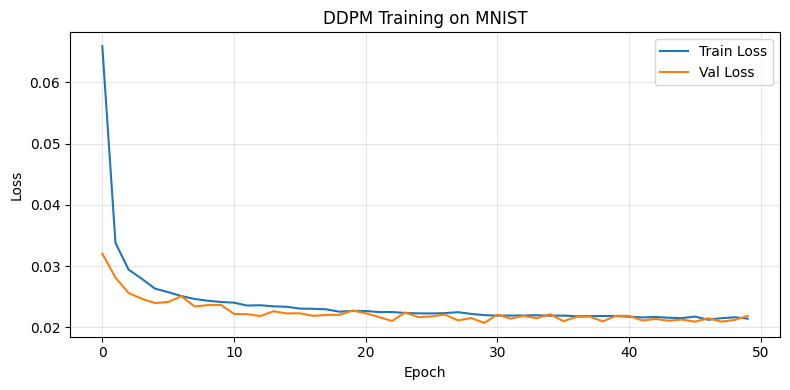

In [18]:
model, history = train_diffusion(
    model=model,
    noise_schedule=noise_schedule,
    train_loader=train_digits,
    val_loader=val_digits,
    config=TrainConfig(epochs=EPOCHS, lr=LR),
    device=device,
)

plot_losses(history["train_loss"], history["val_loss"], "DDPM Training on MNIST")

### DDPM Sampling Results

DDPM Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM sampling (1000 steps, 64 images): 6.7s


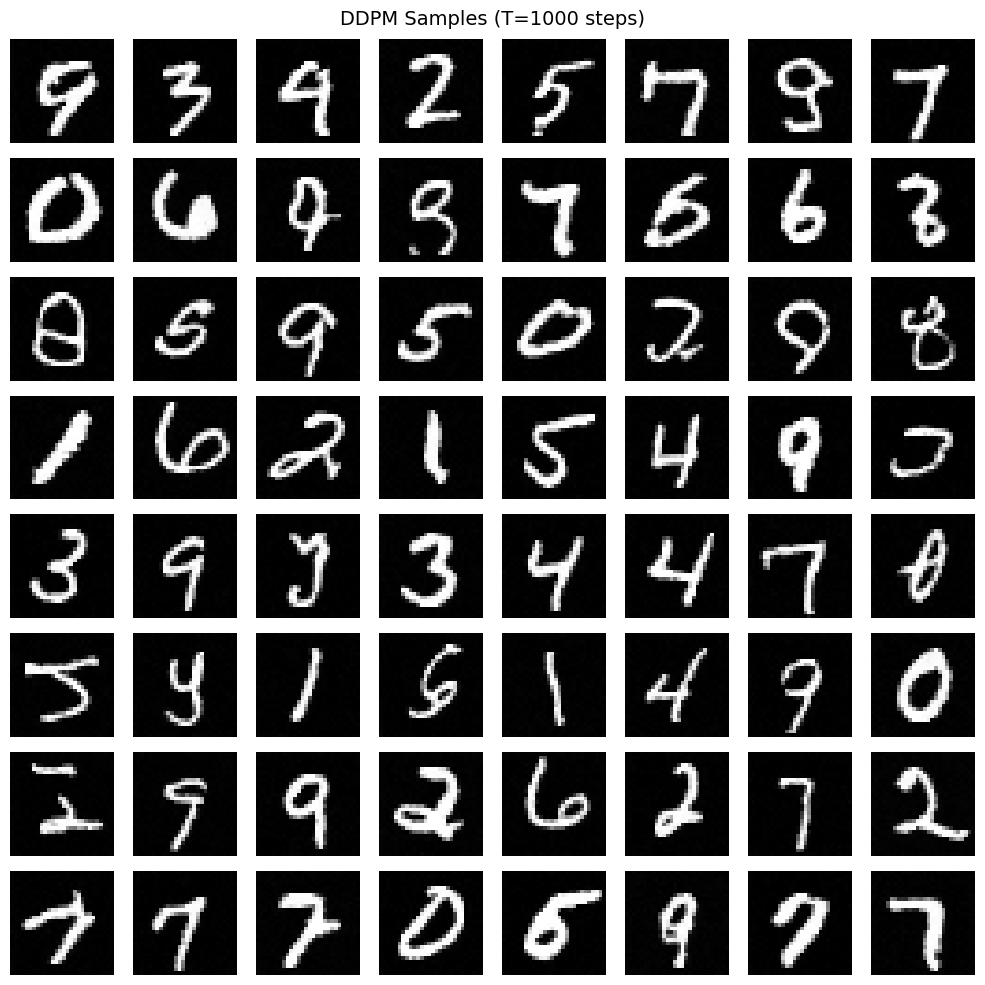

In [20]:
start = time.time()
ddpm_samples, ddpm_intermediates = ddpm_sample(
    model, noise_schedule,
    n_samples=64,
    device=device,
    return_intermediates=True,
    intermediate_steps=[999, 750, 500, 250, 100, 0],
)
ddpm_time = time.time() - start
print(f"DDPM sampling (1000 steps, 64 images): {ddpm_time:.1f}s")

show_generated_grid(ddpm_samples, nrow=8, title="DDPM Samples (T=1000 steps)", figsize=(10, 10))

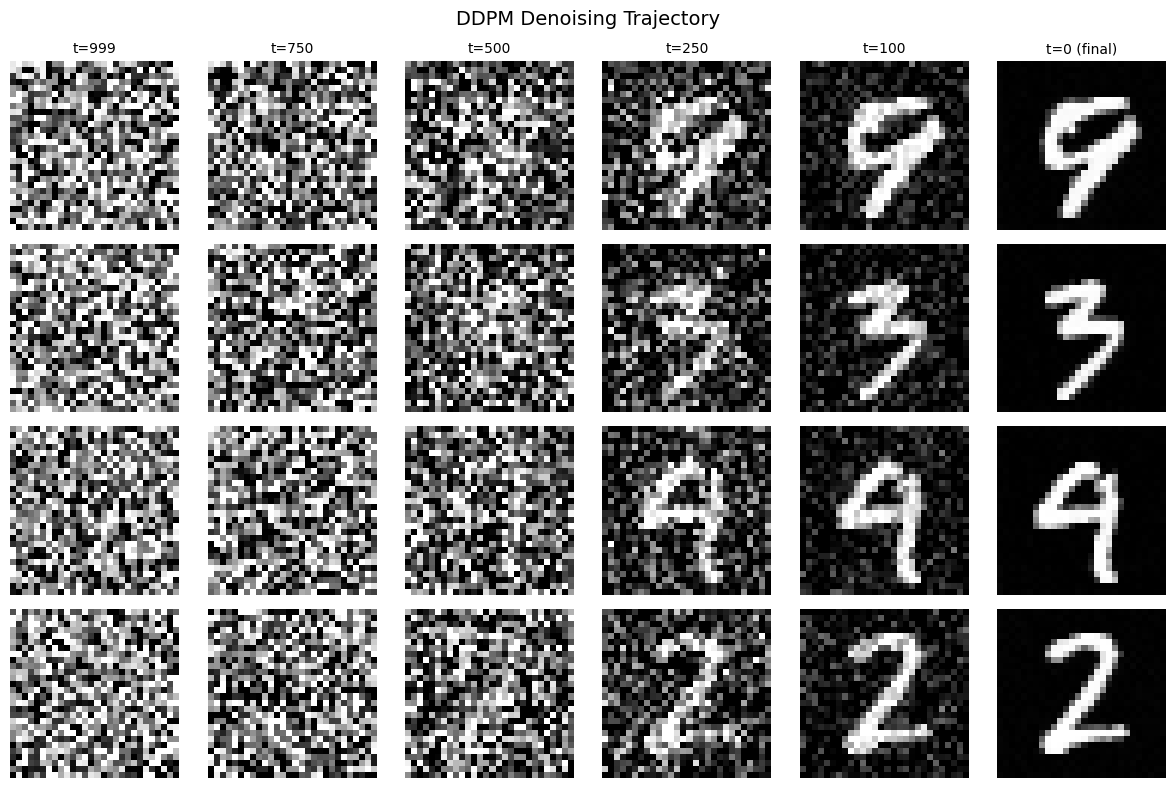

In [21]:
step_labels = ["t=999", "t=750", "t=500", "t=250", "t=100", "t=0 (final)"]
show_denoising_process(
    ddpm_intermediates, step_labels,
    n_samples=4,
    title="DDPM Denoising Trajectory",
)

### DDIM Sampling Results

In [22]:
ddim_step_counts = [10, 25, 50, 100, 200]
ddim_results = {}

for steps in ddim_step_counts:
    start = time.time()
    samples = ddim_sample(
        model, noise_schedule,
        n_samples=64,
        device=device,
        ddim_steps=steps,
        eta=0.0,
    )
    elapsed = time.time() - start
    ddim_results[steps] = {"samples": samples, "time": elapsed}
    print(f"DDIM {steps:>4d} steps: {elapsed:.2f}s")

DDIM Sampling (10 steps):   0%|          | 0/10 [00:00<?, ?it/s]

DDIM   10 steps: 0.16s


DDIM Sampling (25 steps):   0%|          | 0/25 [00:00<?, ?it/s]

DDIM   25 steps: 0.18s


DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM   50 steps: 0.35s


DDIM Sampling (100 steps):   0%|          | 0/100 [00:00<?, ?it/s]

DDIM  100 steps: 0.68s


DDIM Sampling (200 steps):   0%|          | 0/200 [00:00<?, ?it/s]

DDIM  200 steps: 1.37s


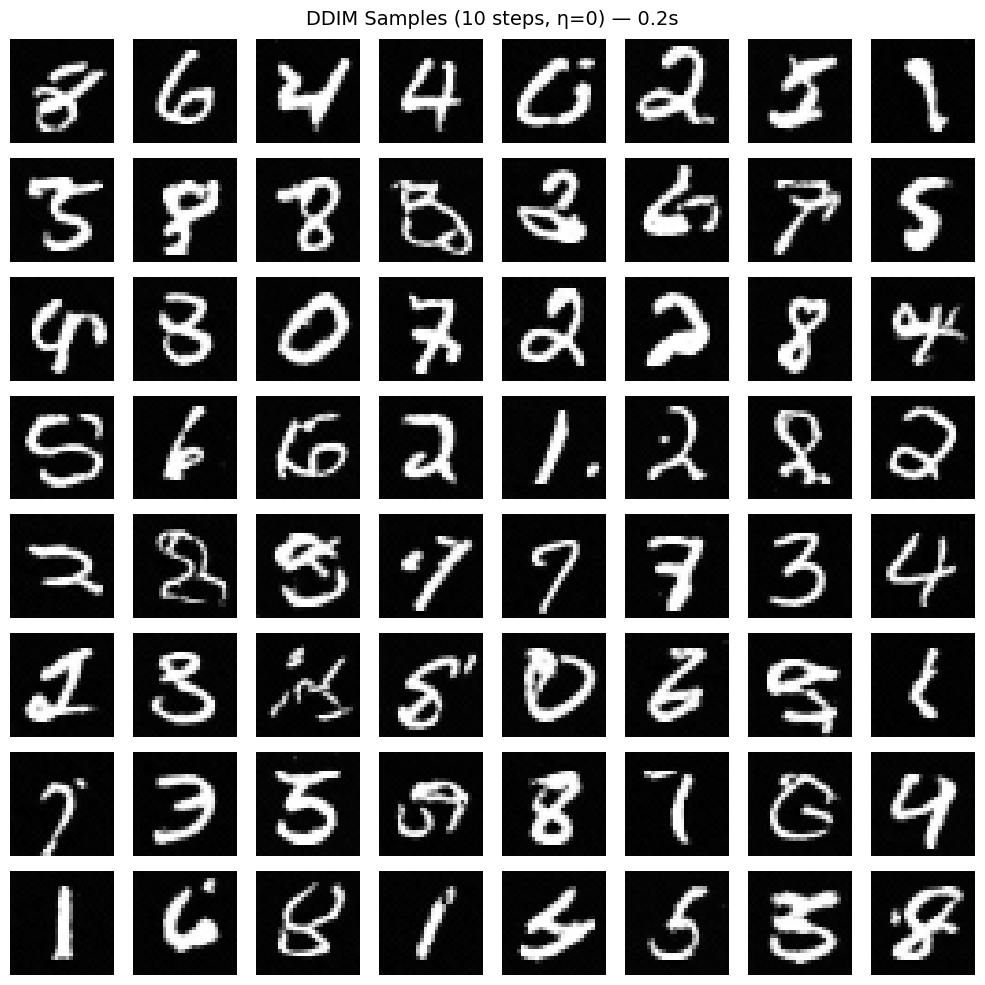

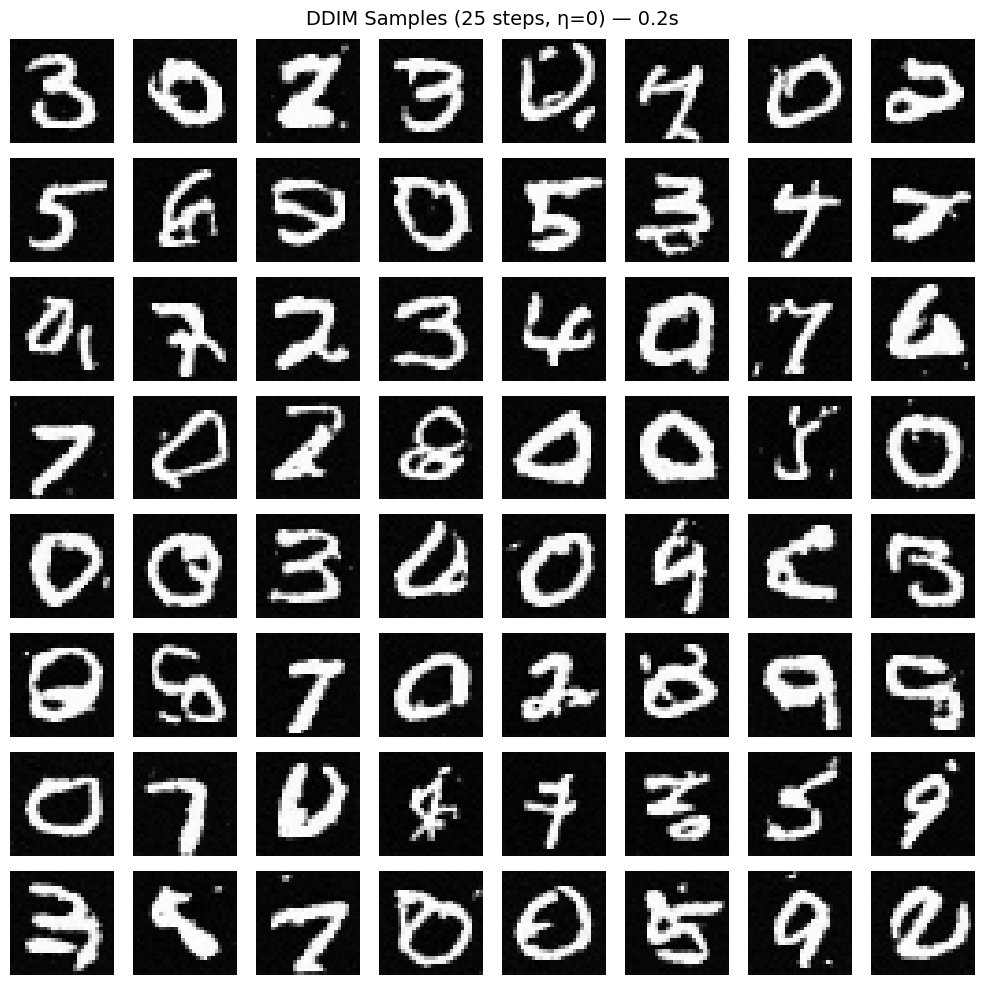

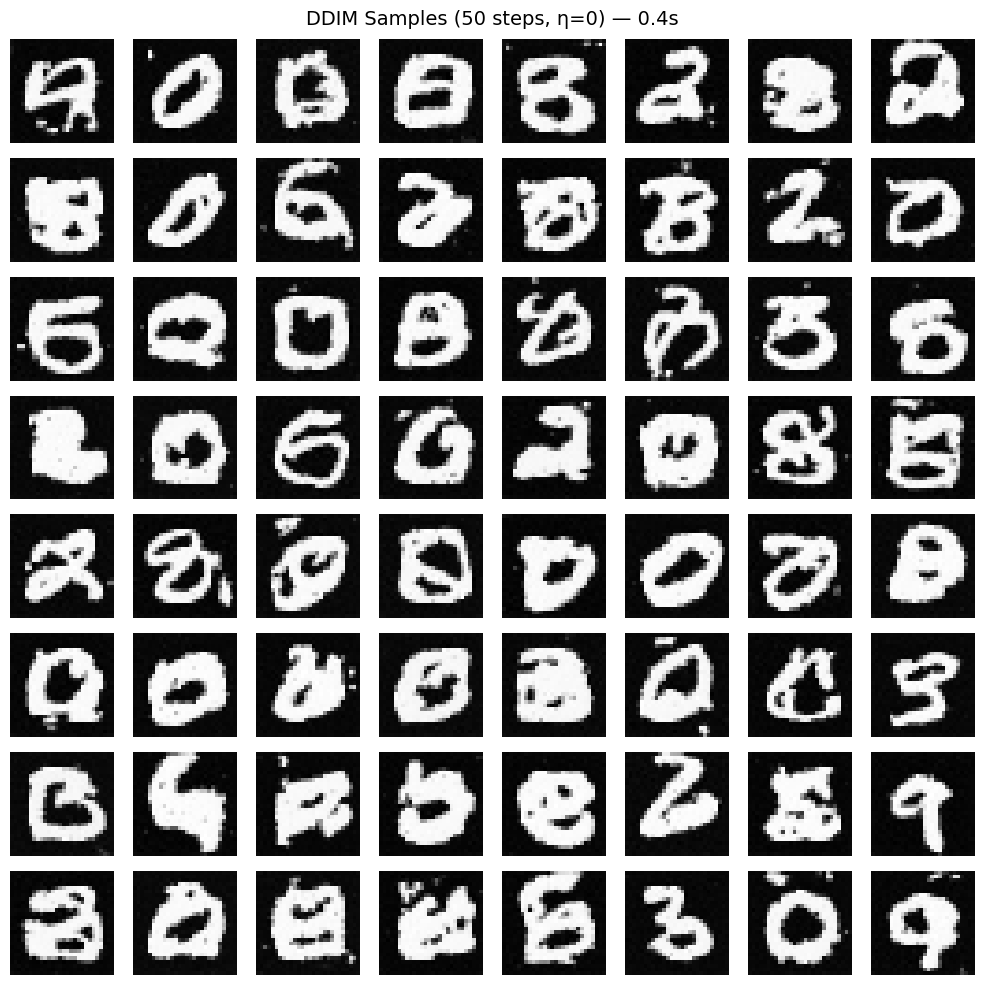

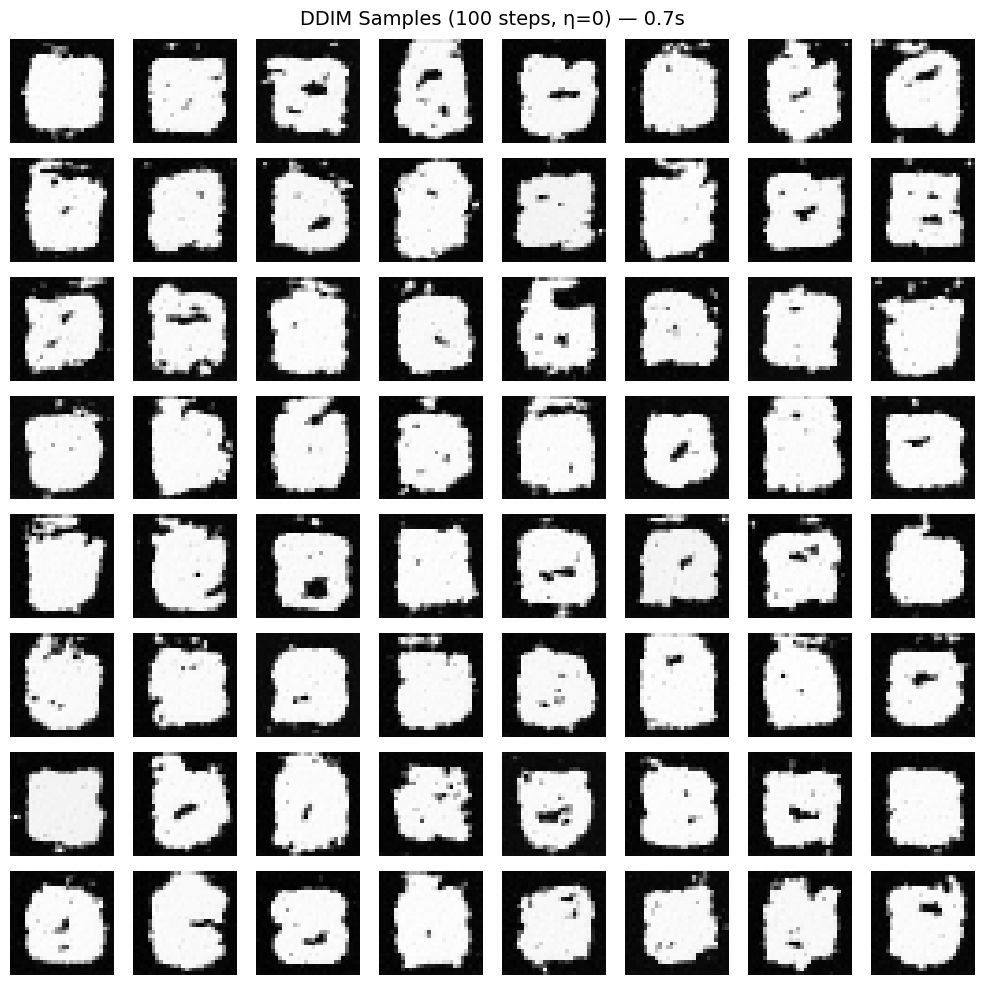

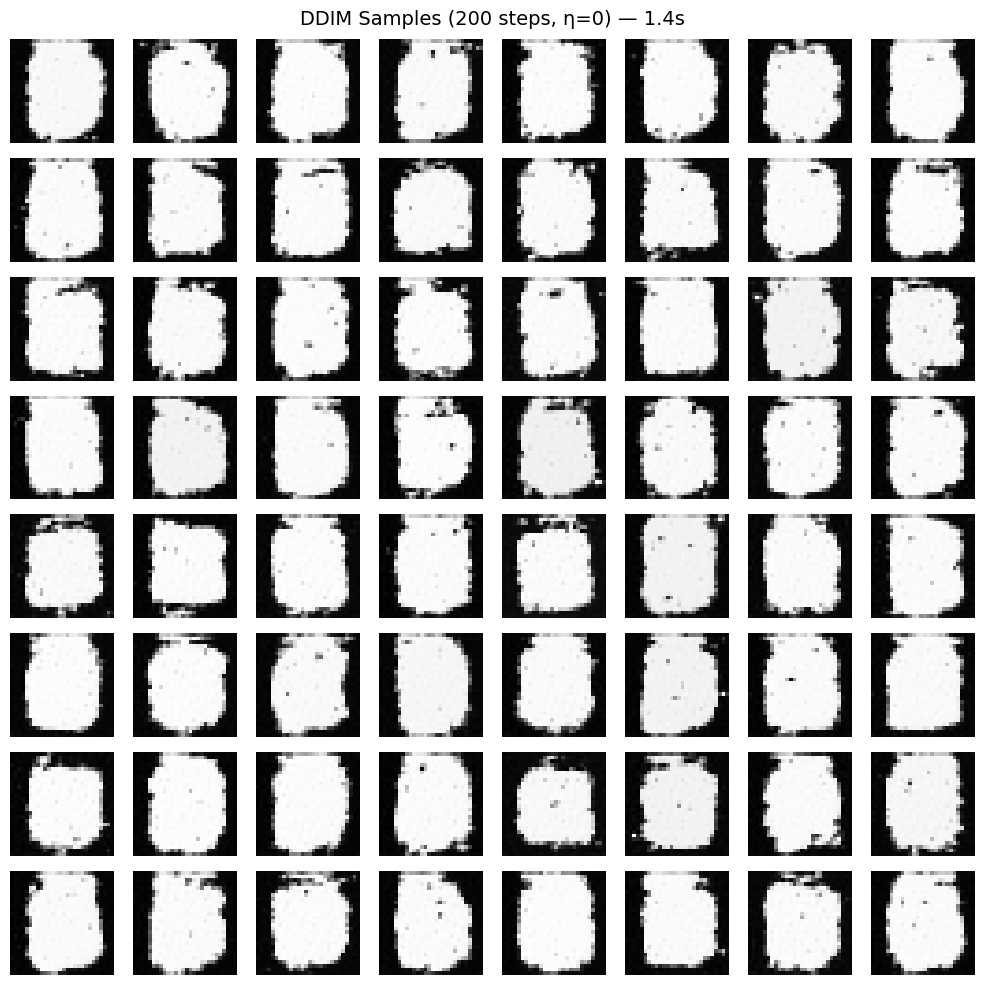

In [23]:
for steps, result in ddim_results.items():
    show_generated_grid(
        result["samples"], nrow=8,
        title=f"DDIM Samples ({steps} steps, η=0) — {result['time']:.1f}s",
        figsize=(10, 10),
    )

### DDIM effect of η

When η=0, DDIM is fully deterministic: the same starting noise always produces the same output. η=1equivalent to DDPM-level stochasticity, maximal sample diversity. We can verify this by running DDIM twice from the same seed.

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

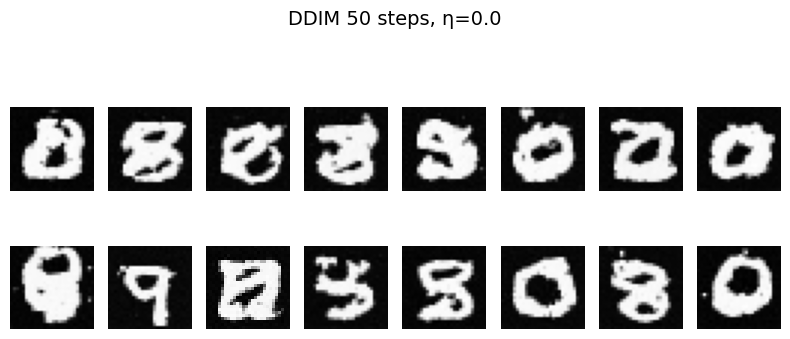

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

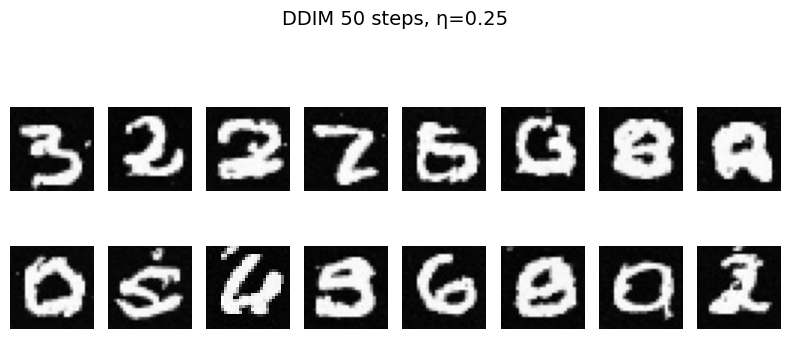

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

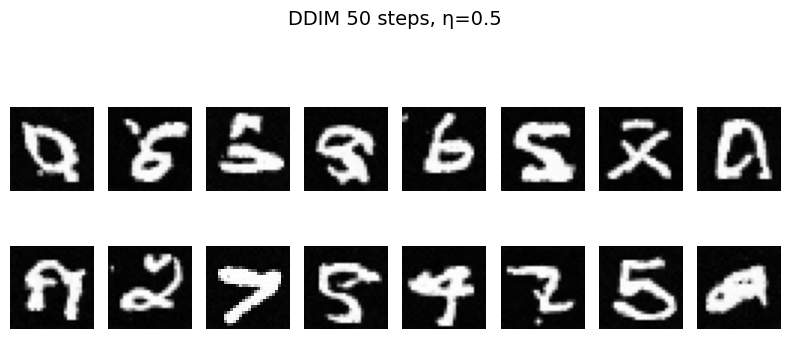

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

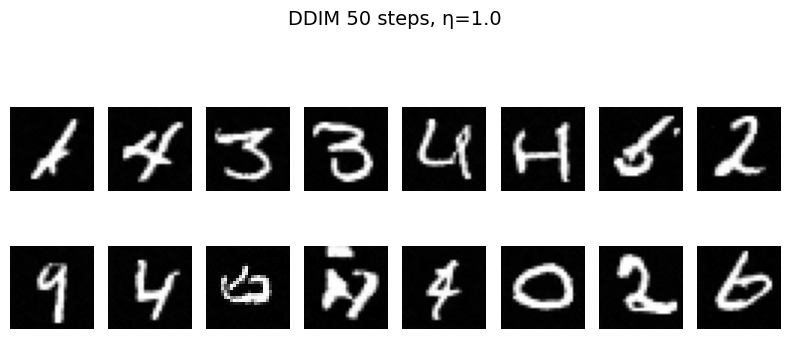

In [24]:
eta_values = [0.0, 0.25, 0.5, 1.0]
DDIM_STEPS_ETA = 50

for eta in eta_values:
    samples = ddim_sample(
        model, noise_schedule,
        n_samples=16,
        device=device,
        ddim_steps=DDIM_STEPS_ETA,
        eta=eta,
    )
    show_generated_grid(
        samples, nrow=8,
        title=f"DDIM {DDIM_STEPS_ETA} steps, η={eta}",
        figsize=(8, 4),
    )

### DeepCache

####  DDPM with Feature Caching

We test DDPM sampling with DeepCache at various cache intervals N (N=1 is the baseline (no caching), larger N = more speedup, more quality risk)

In [25]:
cache_intervals = [1, 2, 3, 5, 10]
ddpm_dc_results = {}

for N in cache_intervals:
    if N == 1:
        start = time.time()
        samples = ddpm_sample(model, noise_schedule, n_samples=64, device=device)
        elapsed = time.time() - start
    else:
        start = time.time()
        samples = ddpm_sample_deepcache(
            model, noise_schedule, n_samples=64, device=device,
            cache_interval=N,
        )
        elapsed = time.time() - start

    ddpm_dc_results[N] = {"samples": samples, "time": elapsed}
    full_steps = 1000 // N if N > 1 else 1000
    cached_steps = 1000 - full_steps if N > 1 else 0
    print(f"DDPM DeepCache N={N:>2d}: {elapsed:.2f}s  "
          f"(full={full_steps}, cached={cached_steps})")

DDPM Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM DeepCache N= 1: 6.68s  (full=1000, cached=0)


DDPM+DeepCache(N=2):   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM DeepCache N= 2: 4.83s  (full=500, cached=500)


DDPM+DeepCache(N=3):   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM DeepCache N= 3: 4.38s  (full=333, cached=667)


DDPM+DeepCache(N=5):   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM DeepCache N= 5: 3.74s  (full=200, cached=800)


DDPM+DeepCache(N=10):   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM DeepCache N=10: 3.35s  (full=100, cached=900)


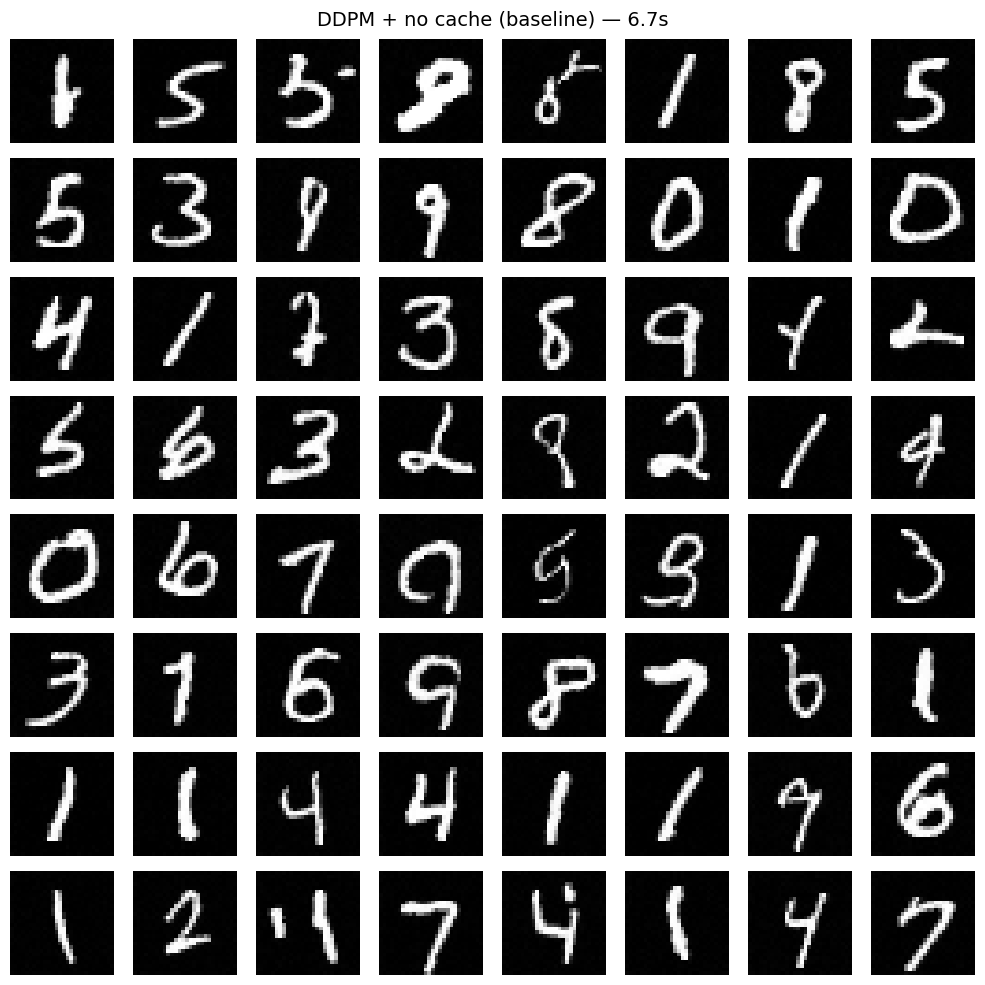

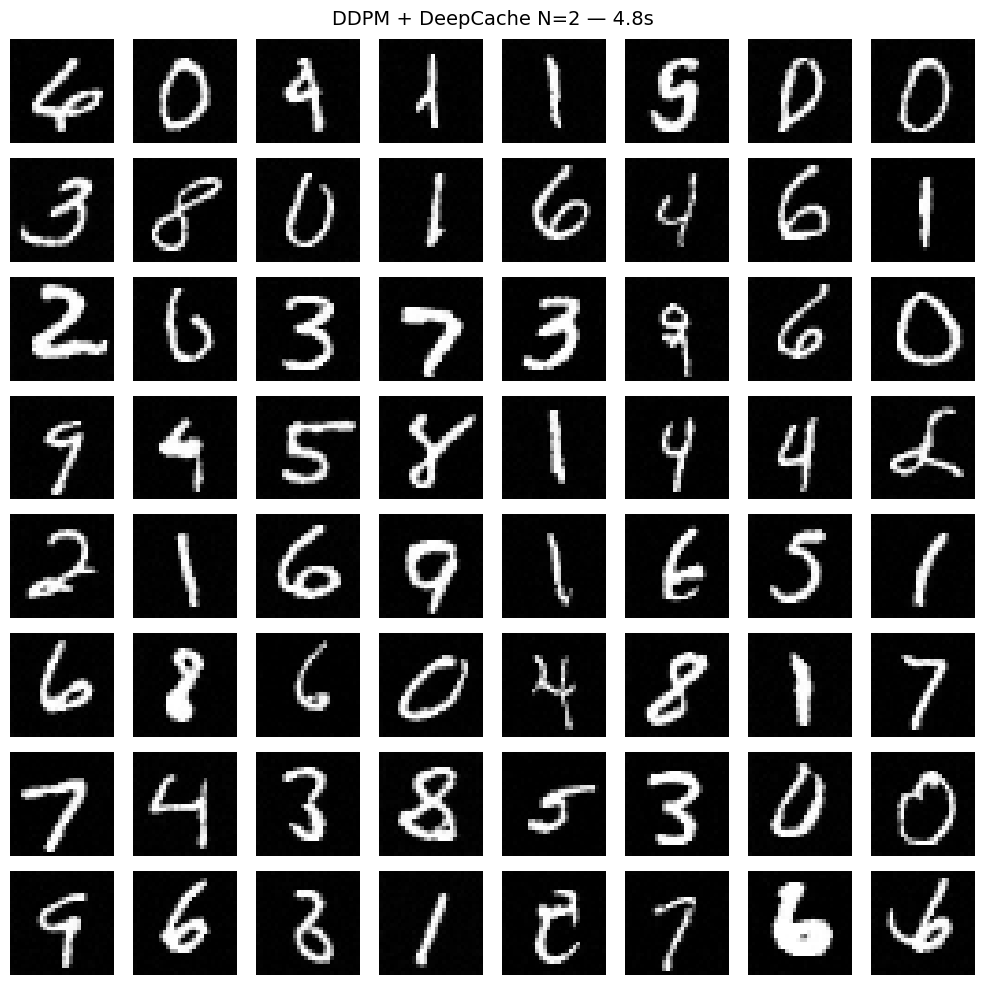

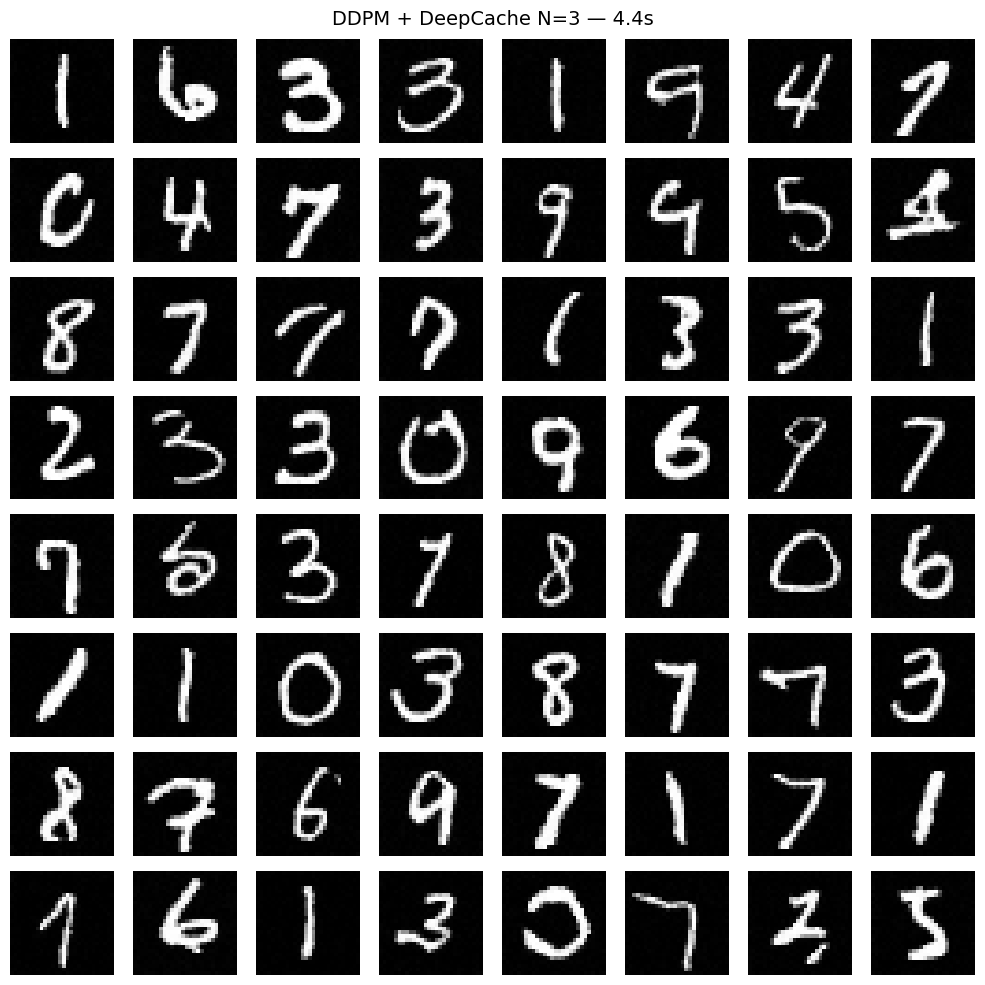

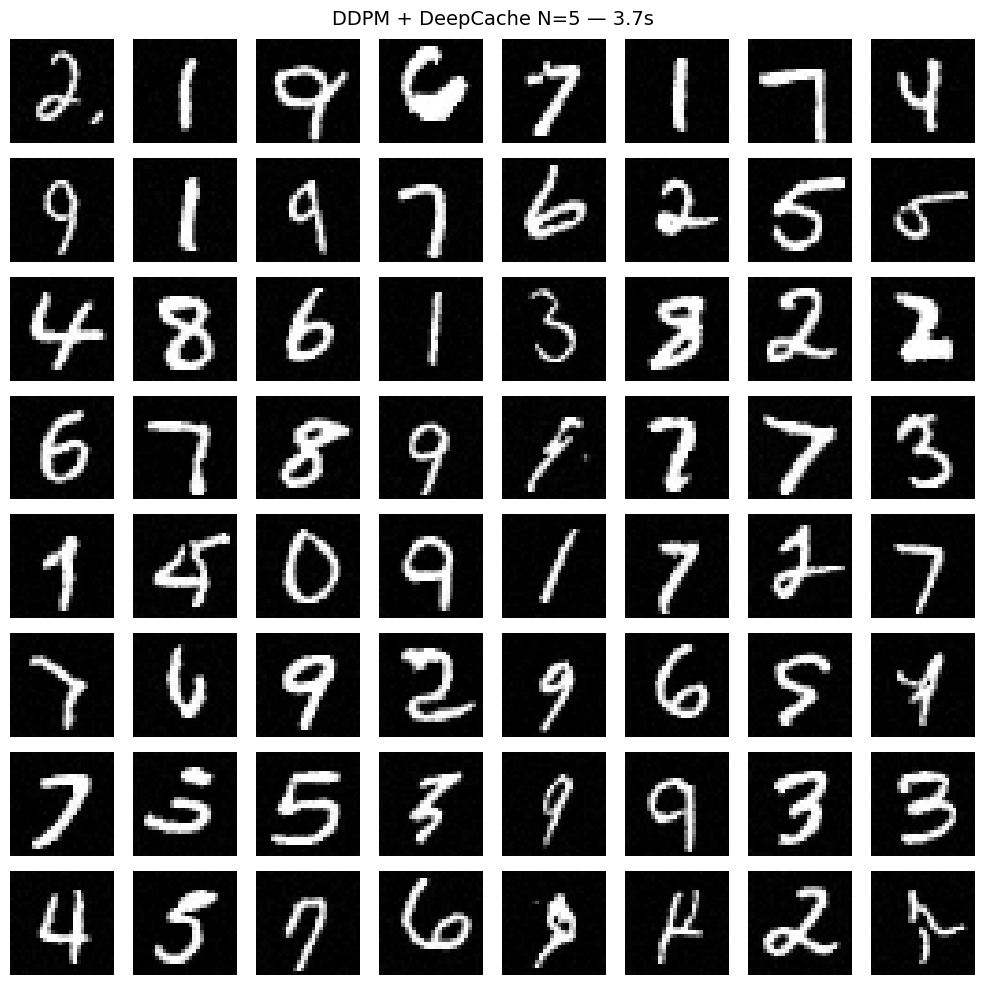

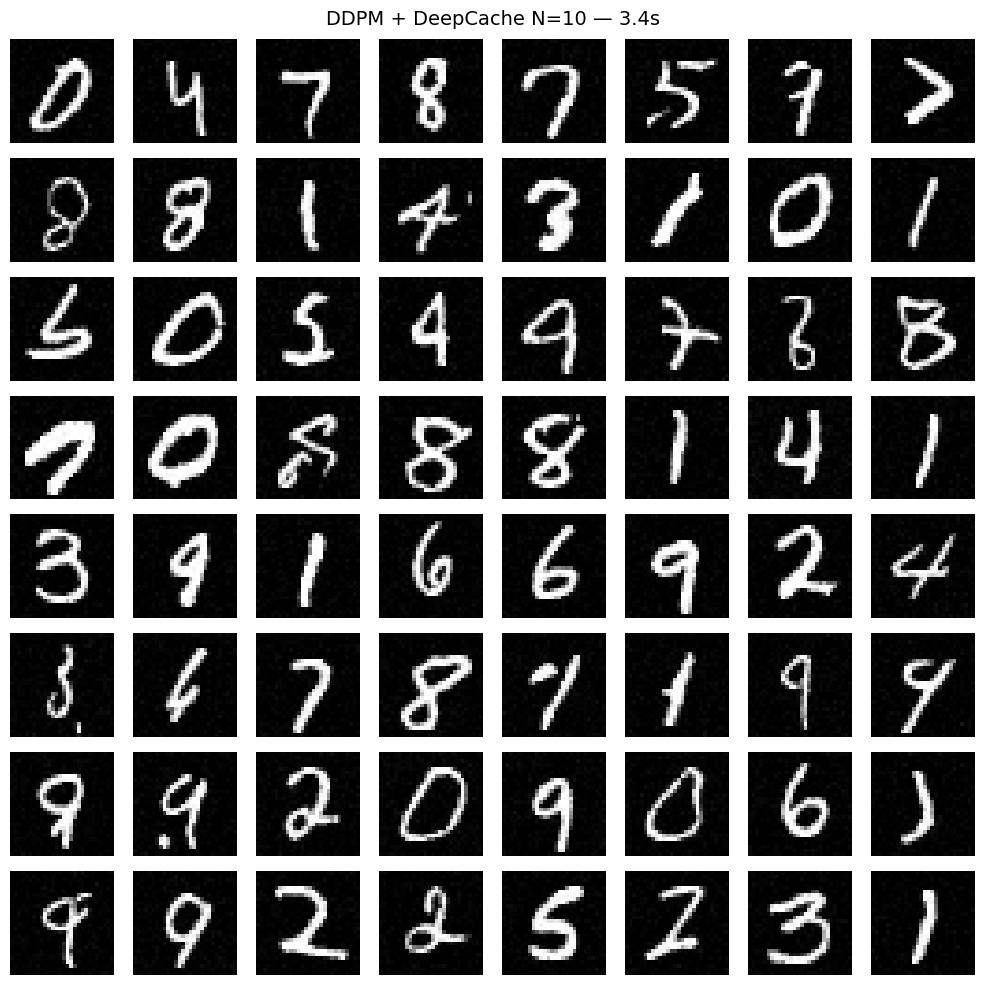

In [26]:
for N, res in ddpm_dc_results.items():
    label = "no cache (baseline)" if N == 1 else f"DeepCache N={N}"
    show_generated_grid(
        res["samples"], nrow=8,
        title=f"DDPM + {label} — {res['time']:.1f}s",
        figsize=(10, 10),
    )

#### DDIM with Feature Caching

DDIM already reduces steps (for example 50), and DeepCache reduces the
cost per step. For DDIM-50 with N=5, we get only 10 full U-Net passes + 40 decoder-only

In [27]:
ddim_dc_results = {}

ddim_steps_to_test = [50, 100]
cache_intervals_ddim = [1, 2, 3, 5]

for steps in ddim_steps_to_test:
    for N in cache_intervals_ddim:
        key = (steps, N)
        if N == 1:
            start = time.time()
            samples = ddim_sample(model, noise_schedule, n_samples=64, device=device,
                                  ddim_steps=steps, eta=0.0)
            elapsed = time.time() - start
        else:
            start = time.time()
            samples = ddim_sample_deepcache(
                model, noise_schedule, n_samples=64, device=device,
                ddim_steps=steps, eta=0.0, cache_interval=N,
            )
            elapsed = time.time() - start

        ddim_dc_results[key] = {"samples": samples, "time": elapsed}
        full = math.ceil(steps / N)
        cached = steps - full
        print(f"DDIM-{steps} DeepCache N={N}: {elapsed:.2f}s  "
              f"(full={full}, cached={cached})")

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM-50 DeepCache N=1: 0.36s  (full=50, cached=0)


DDIM(50)+DC(N=2):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM-50 DeepCache N=2: 0.27s  (full=25, cached=25)


DDIM(50)+DC(N=3):   0%|          | 0/50 [00:00<?, ?it/s]

...

DDIM-100 DeepCache N=2: 0.50s  (full=50, cached=50)


DDIM(100)+DC(N=3):   0%|          | 0/100 [00:00<?, ?it/s]

DDIM-100 DeepCache N=3: 0.45s  (full=34, cached=66)


DDIM(100)+DC(N=5):   0%|          | 0/100 [00:00<?, ?it/s]

DDIM-100 DeepCache N=5: 0.39s  (full=20, cached=80)


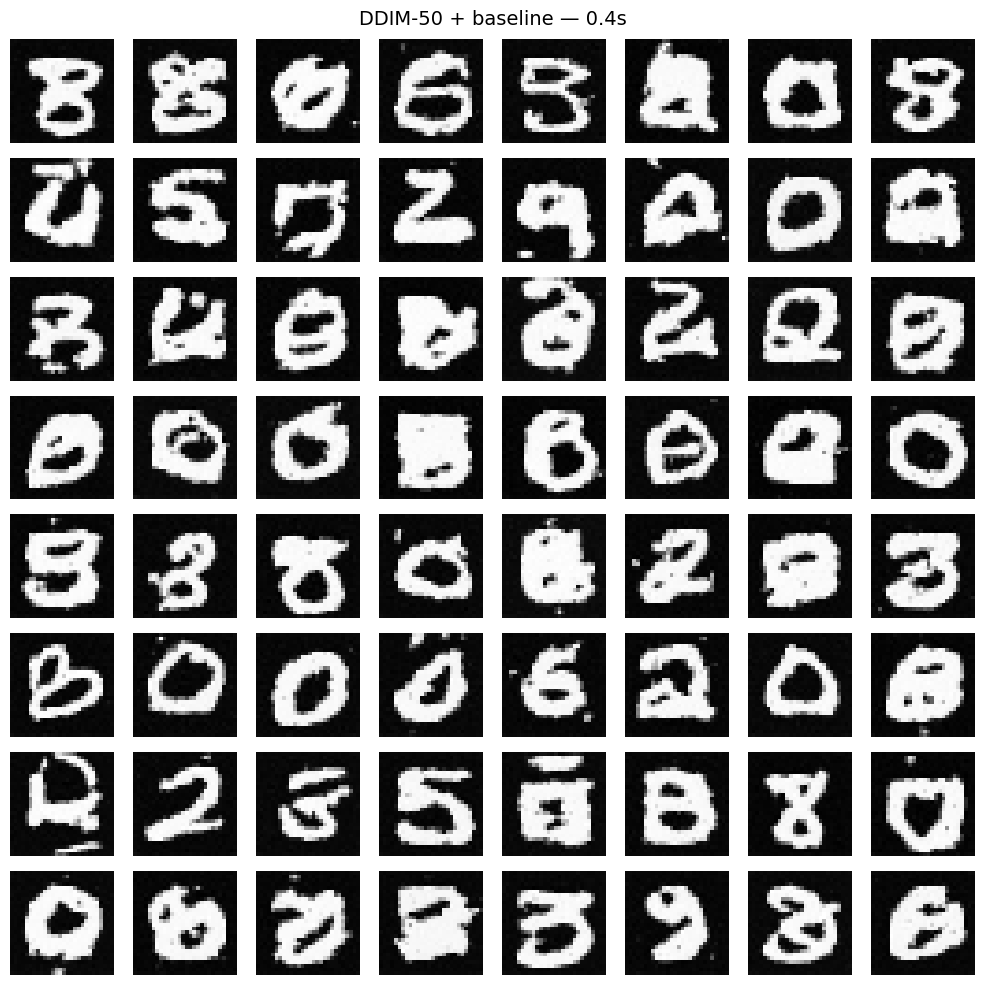

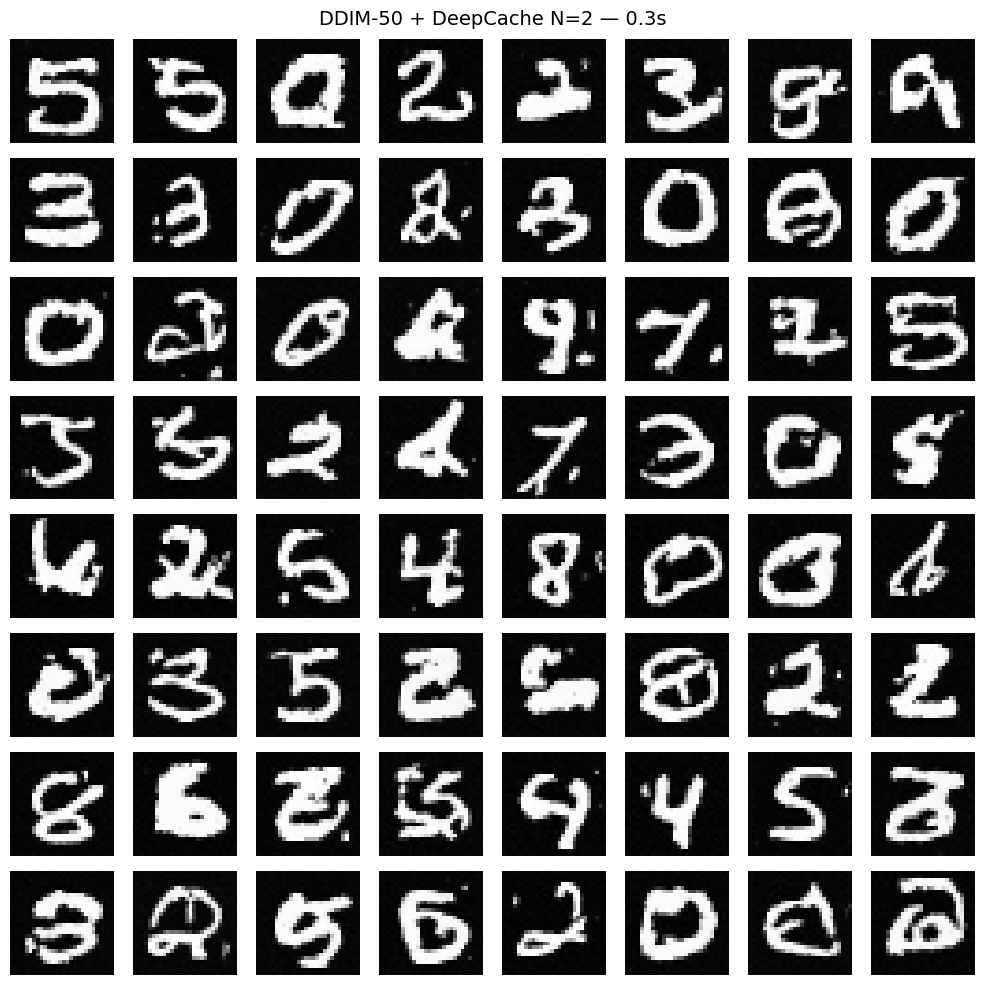

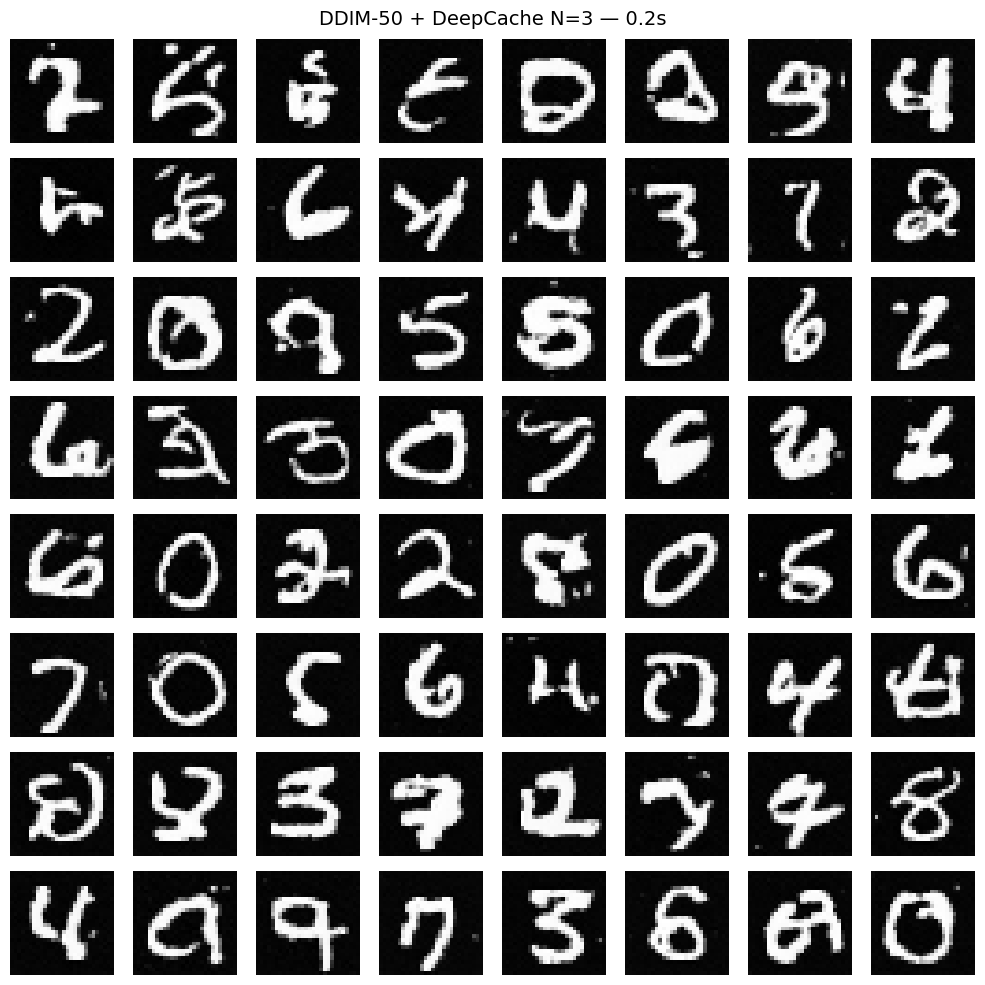

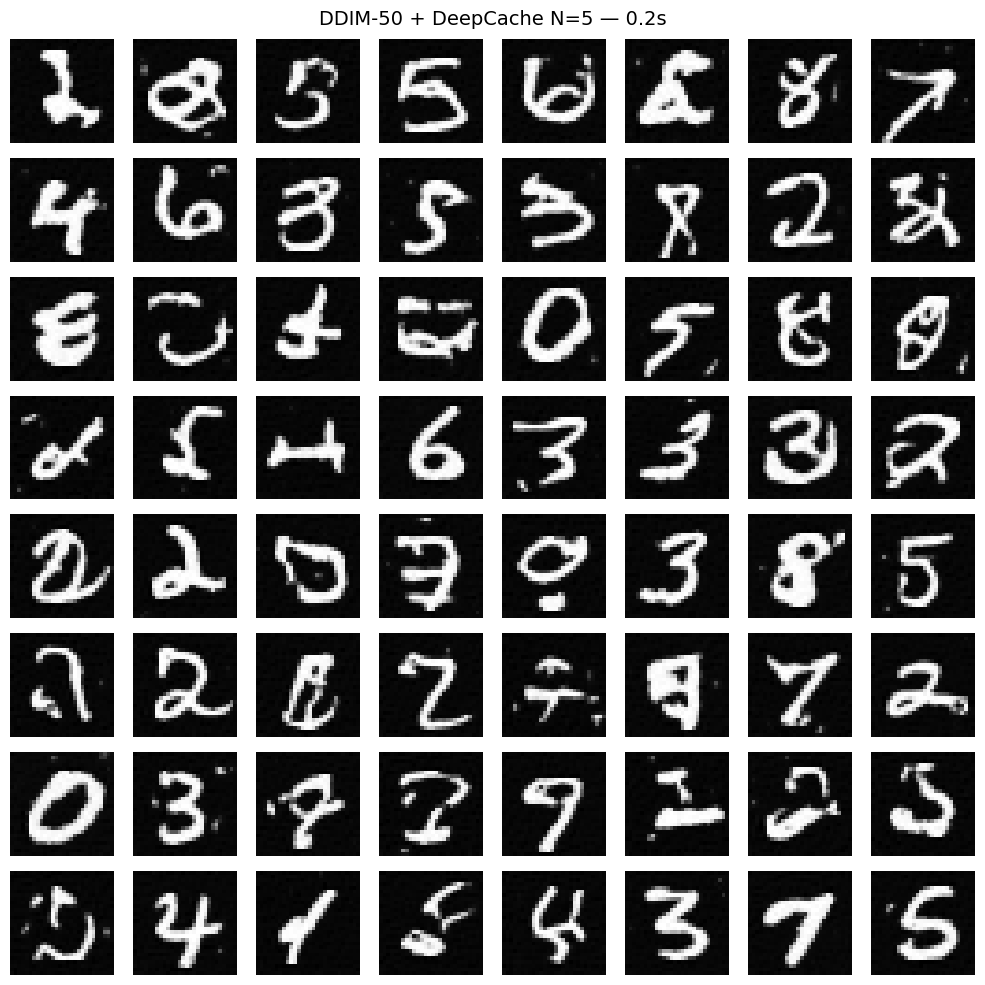

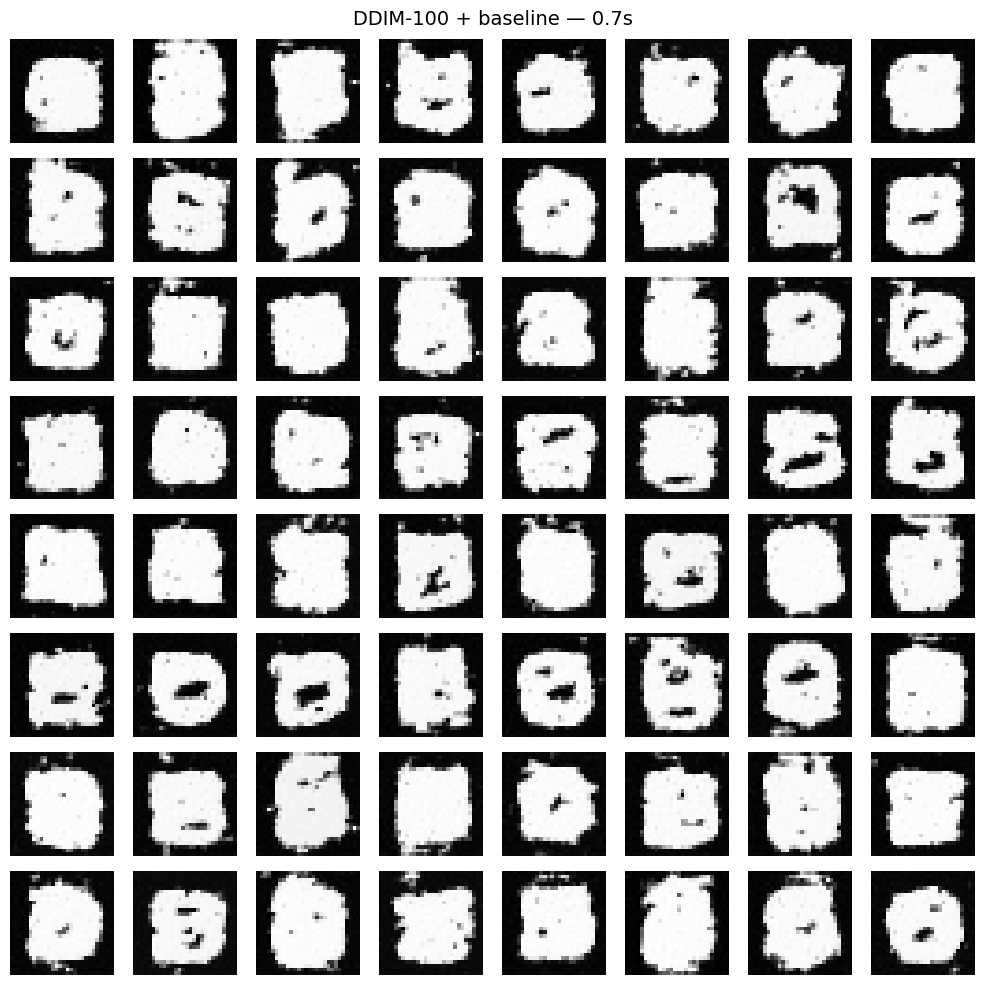

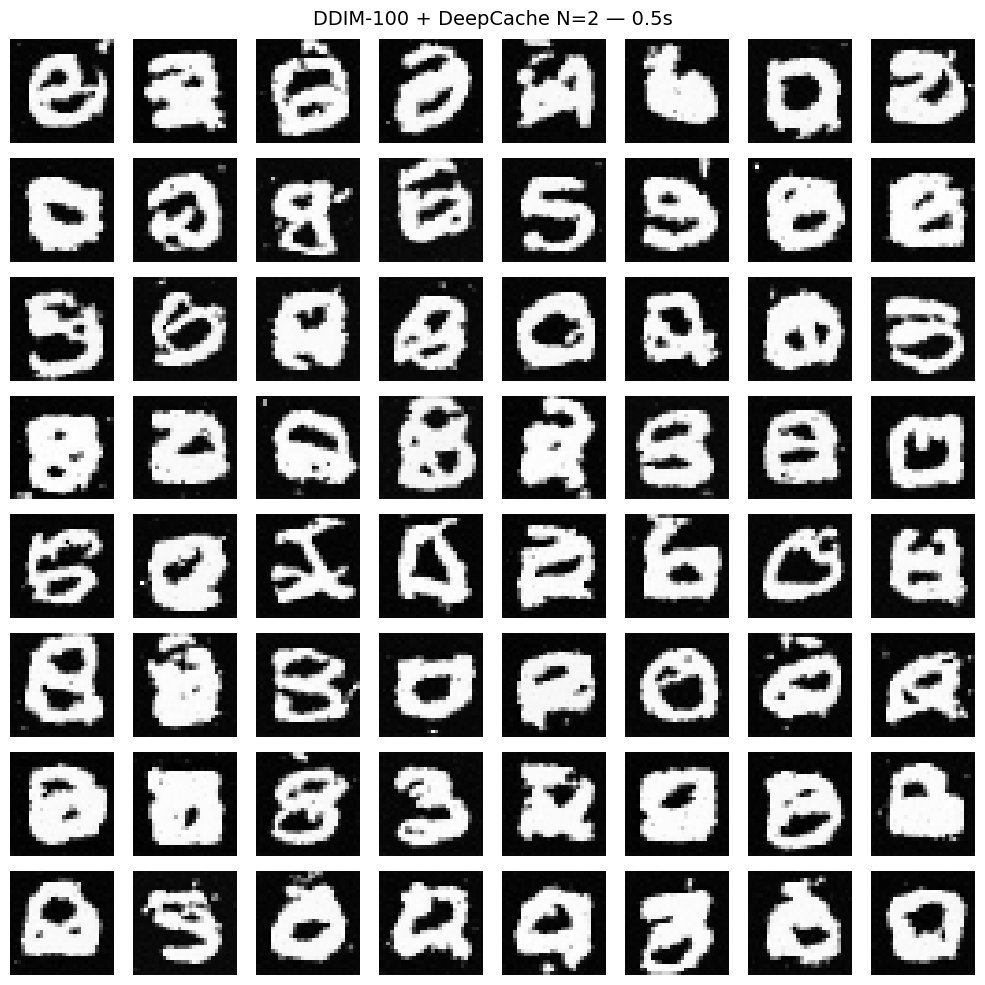

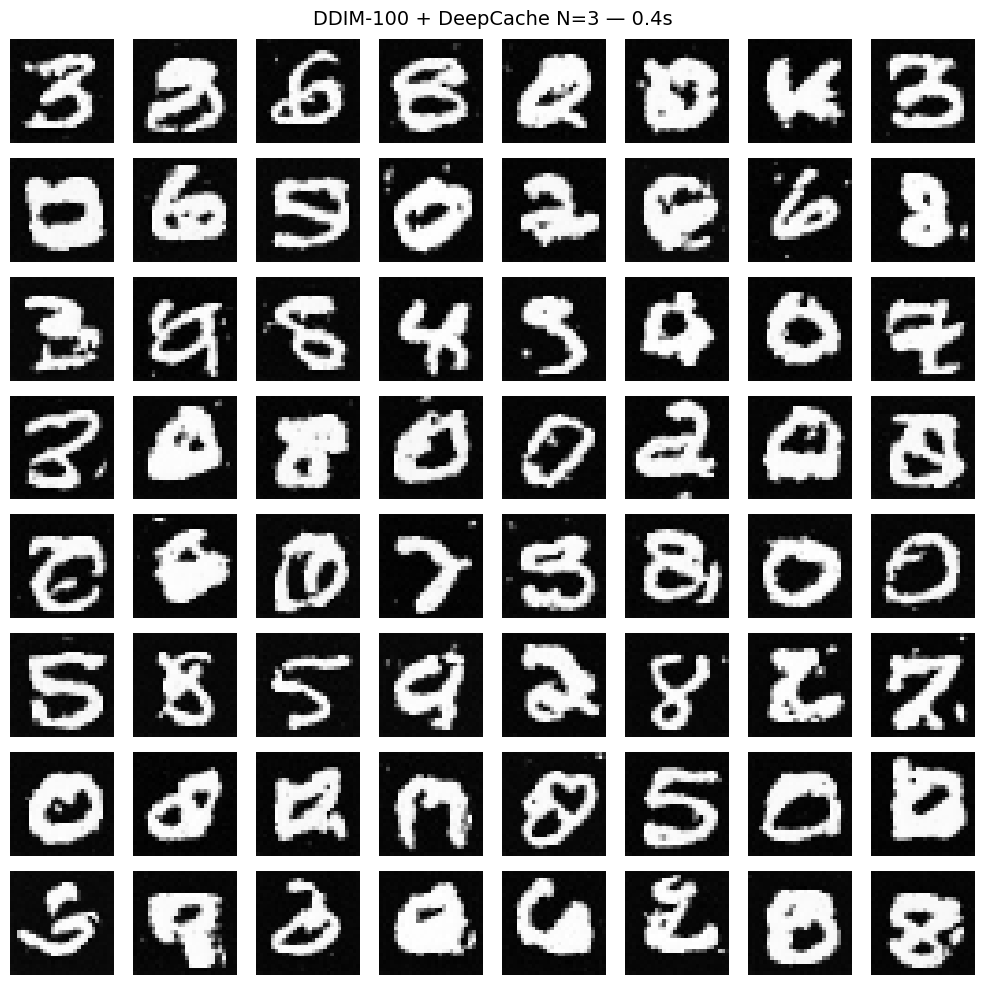

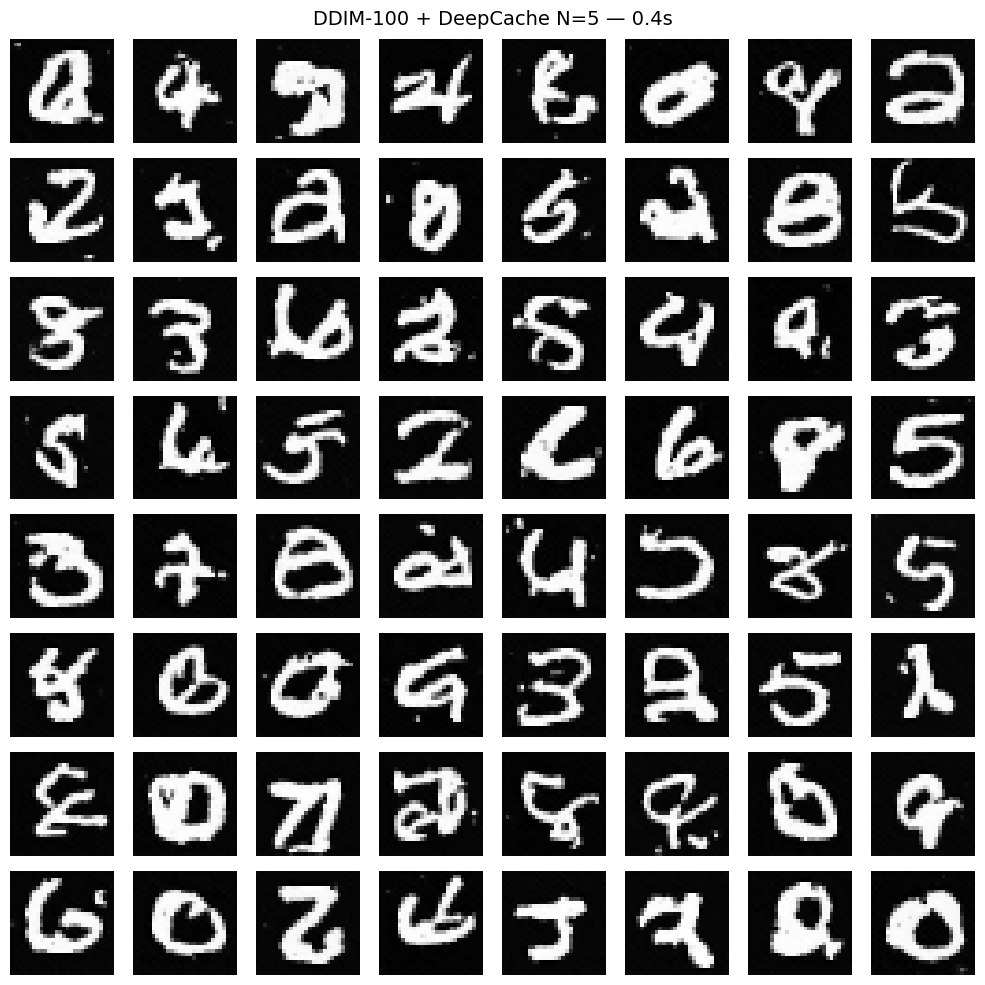

In [28]:
for (steps, N), res in ddim_dc_results.items():
    label = "baseline" if N == 1 else f"DeepCache N={N}"
    show_generated_grid(
        res["samples"], nrow=8,
        title=f"DDIM-{steps} + {label} — {res['time']:.1f}s",
        figsize=(10, 10),
    )

## Train on Fashion

In [36]:
T = 1000
EPOCHS = 50
BATCH_SIZE = 128
LR = 2e-4

noise_schedule = NoiseSchedule(T=T, device=device)
model = UNet(in_ch=1, base_ch=64, time_dim=256, dropout=0.1).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Training DDPM on Fashion | T={T} | {EPOCHS} epochs | {n_params:,} params")

Training DDPM on Fashion | T=1000 | 50 epochs | 6,166,081 params


Epoch 1/50:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.0880  val_loss: 0.0522


Epoch 2/50:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.0514  val_loss: 0.0475


Epoch 3/50:   0%|          | 0/422 [00:00<?, ?it/s]

...

  => train_loss: 0.0348  val_loss: 0.0354


Epoch 49/50:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.0350  val_loss: 0.0329


Epoch 50/50:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.0355  val_loss: 0.0352


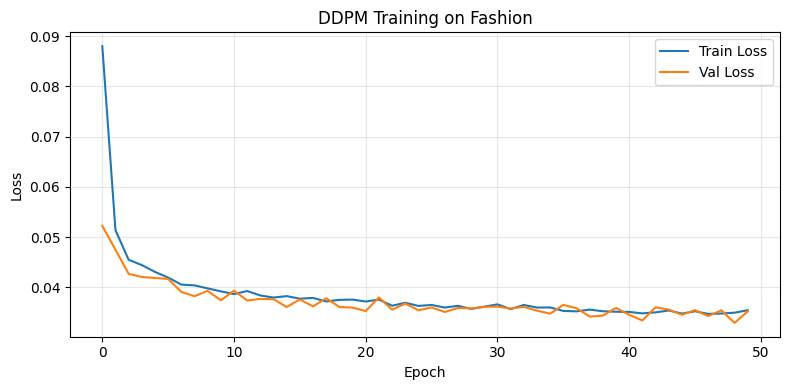

In [37]:
model, history = train_diffusion(
    model=model,
    noise_schedule=noise_schedule,
    train_loader=train_fashion,
    val_loader=val_fashion,
    config=TrainConfig(epochs=EPOCHS, lr=LR),
    device=device,
)

plot_losses(history["train_loss"], history["val_loss"], "DDPM Training on Fashion")

### DDPM Sampling Results

DDPM Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM sampling (1000 steps, 64 images): 6.8s


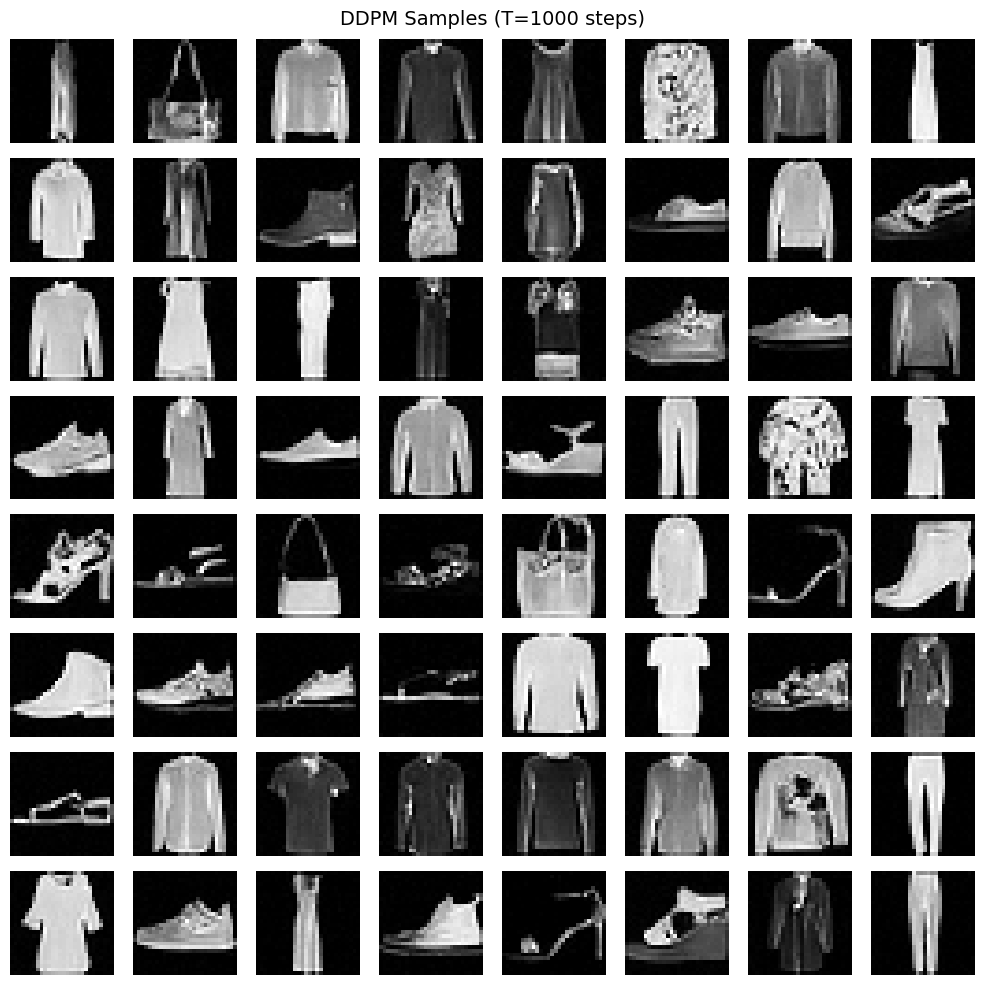

In [38]:
start = time.time()
ddpm_samples, ddpm_intermediates = ddpm_sample(
    model, noise_schedule,
    n_samples=64,
    device=device,
    return_intermediates=True,
    intermediate_steps=[999, 750, 500, 250, 100, 0],
)
ddpm_time = time.time() - start
print(f"DDPM sampling (1000 steps, 64 images): {ddpm_time:.1f}s")

show_generated_grid(ddpm_samples, nrow=8, title="DDPM Samples (T=1000 steps)", figsize=(10, 10))

### DDIM Sampling Results

In [39]:
ddim_step_counts = [10, 25, 50, 100, 200]
ddim_results = {}

for steps in ddim_step_counts:
    start = time.time()
    samples = ddim_sample(
        model, noise_schedule,
        n_samples=64,
        device=device,
        ddim_steps=steps,
        eta=0.0,
    )
    elapsed = time.time() - start
    ddim_results[steps] = {"samples": samples, "time": elapsed}
    print(f"DDIM {steps:>4d} steps: {elapsed:.2f}s")

DDIM Sampling (10 steps):   0%|          | 0/10 [00:00<?, ?it/s]

DDIM   10 steps: 0.08s


DDIM Sampling (25 steps):   0%|          | 0/25 [00:00<?, ?it/s]

DDIM   25 steps: 0.18s


DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM   50 steps: 0.35s


DDIM Sampling (100 steps):   0%|          | 0/100 [00:00<?, ?it/s]

DDIM  100 steps: 0.70s


DDIM Sampling (200 steps):   0%|          | 0/200 [00:00<?, ?it/s]

DDIM  200 steps: 1.38s


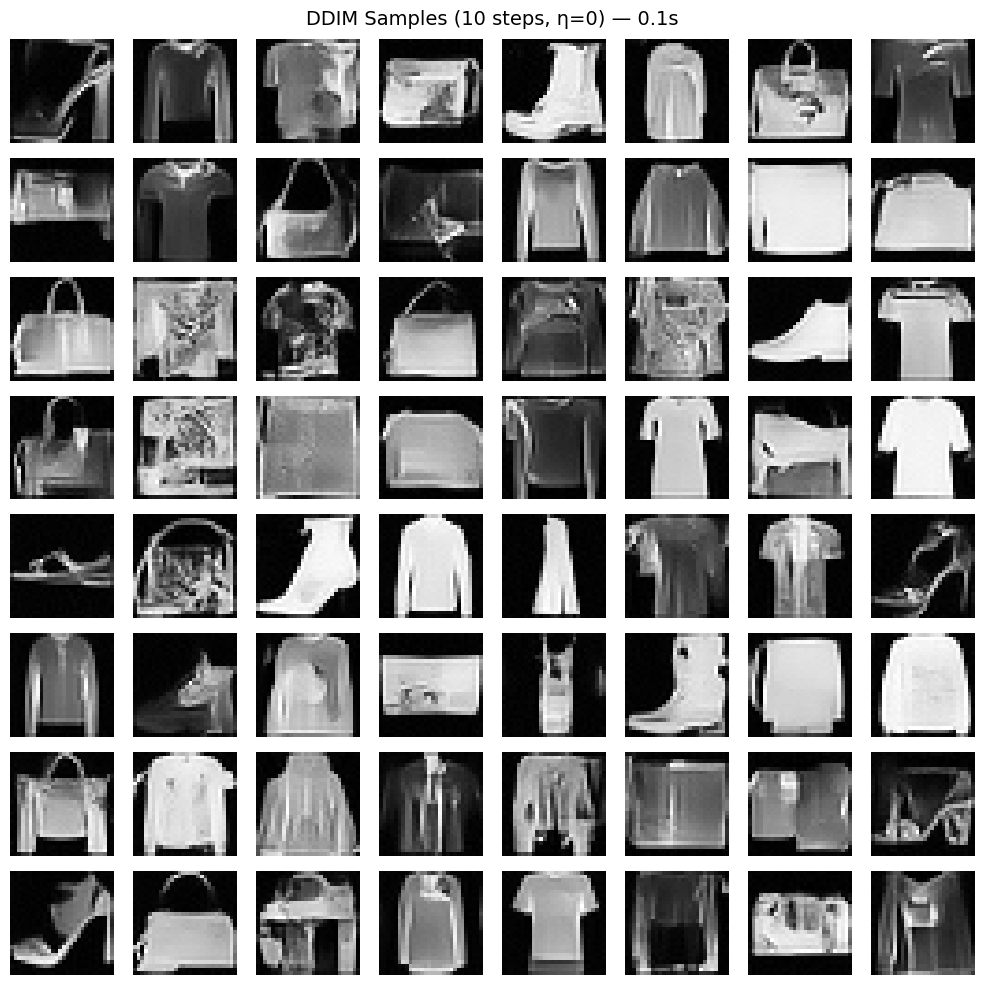

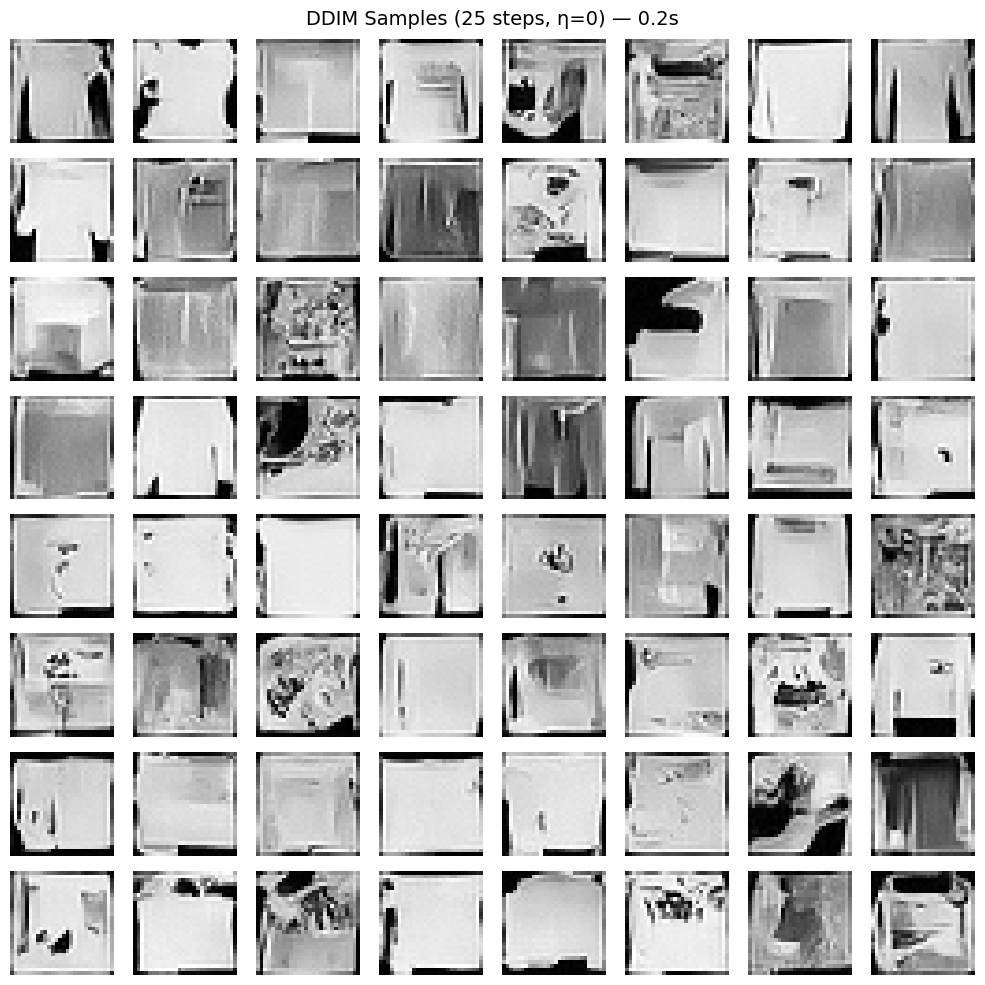

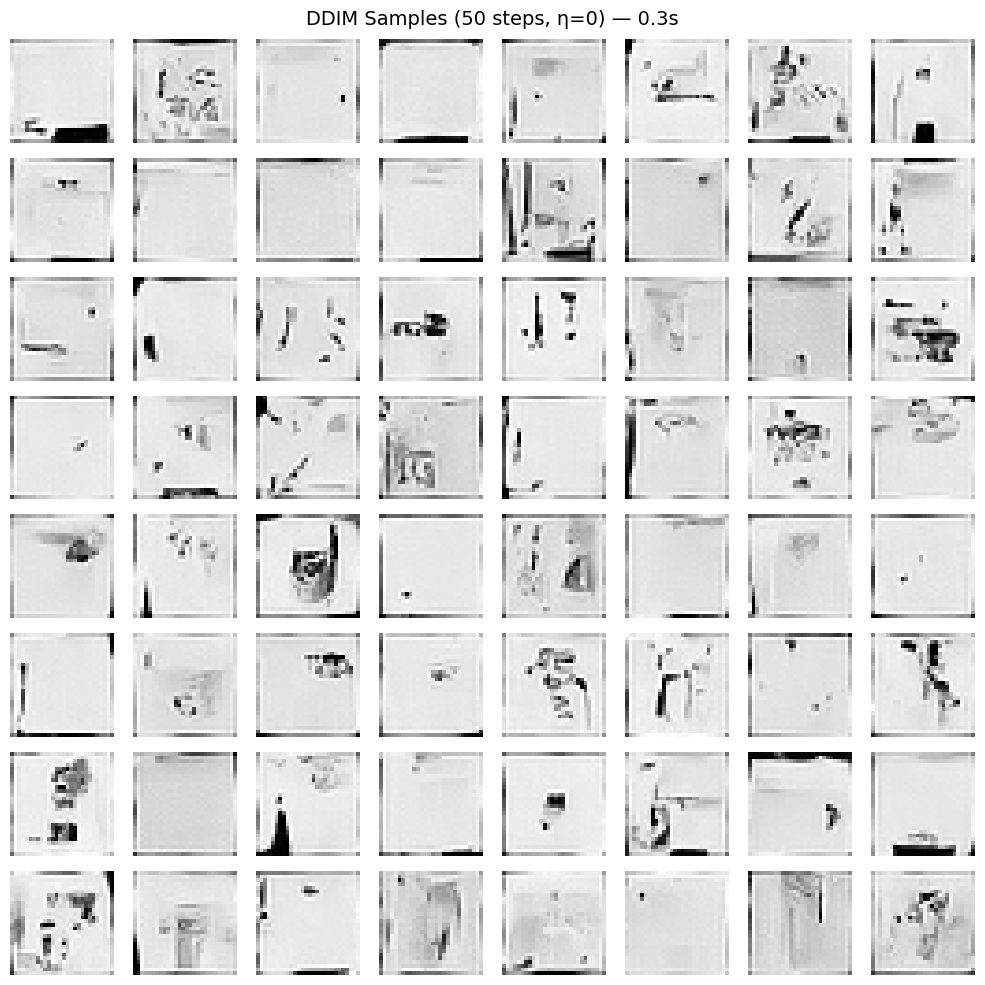

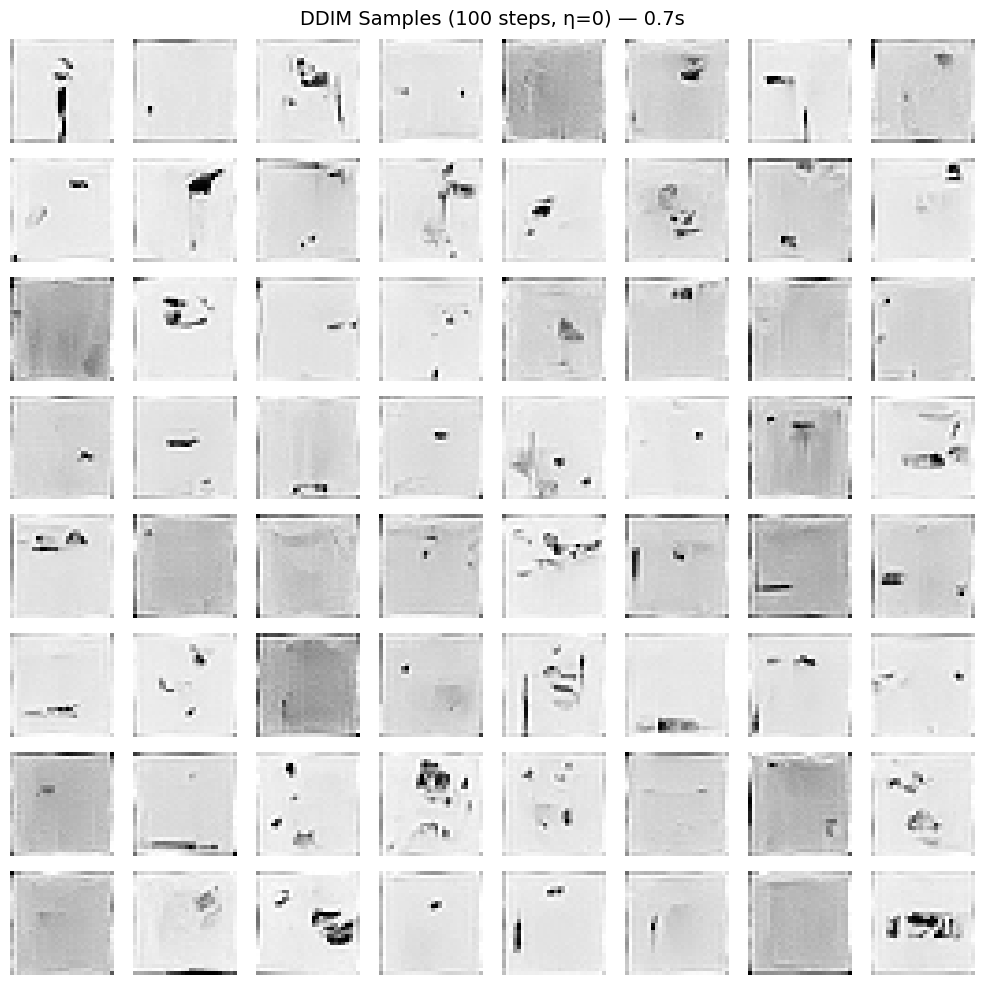

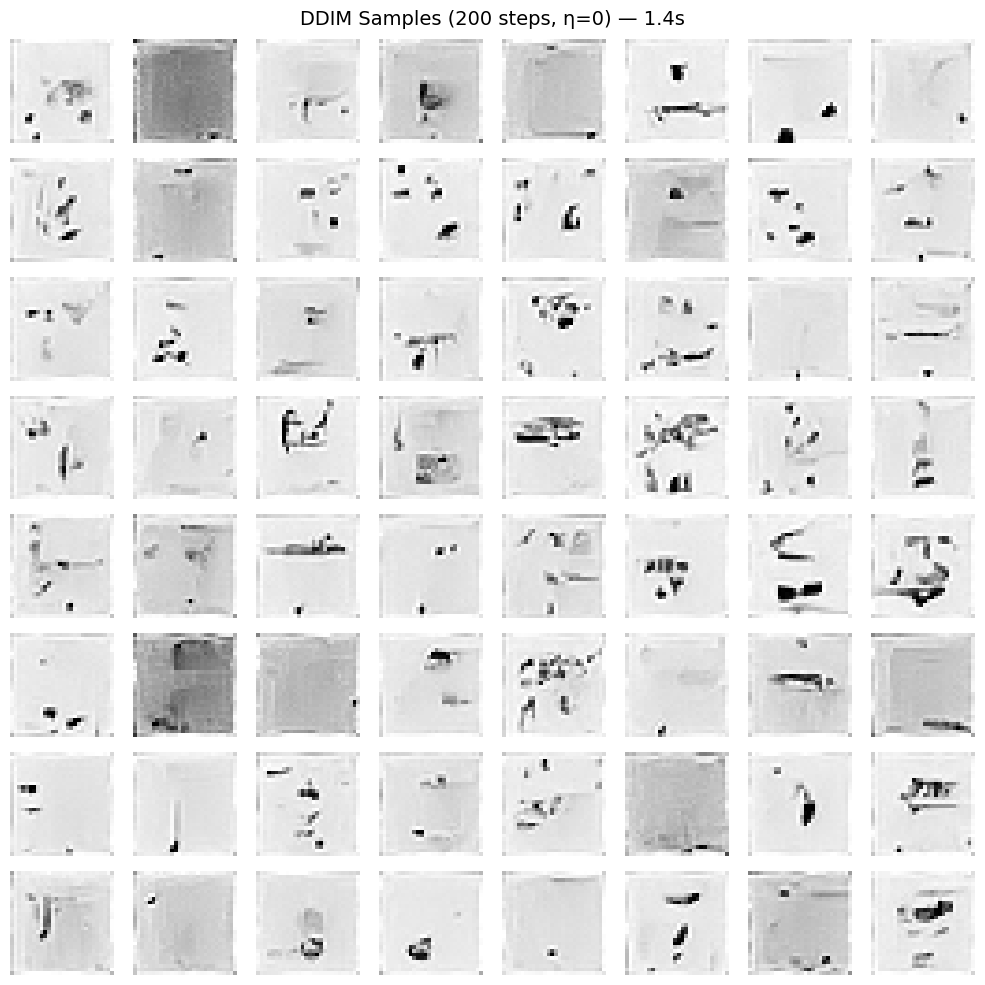

In [40]:
for steps, result in ddim_results.items():
    show_generated_grid(
        result["samples"], nrow=8,
        title=f"DDIM Samples ({steps} steps, η=0) — {result['time']:.1f}s",
        figsize=(10, 10),
    )

### DDIM effect of η

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

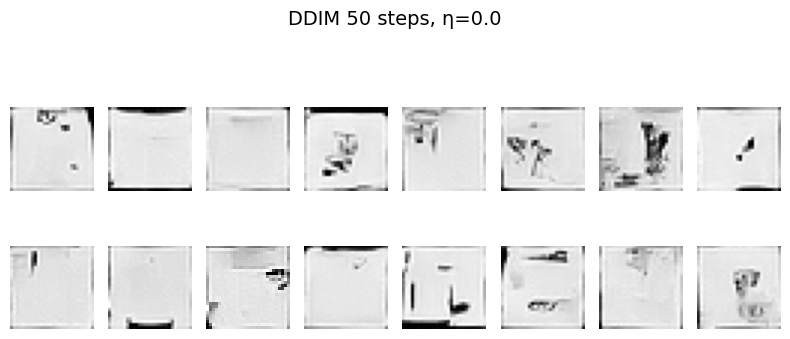

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

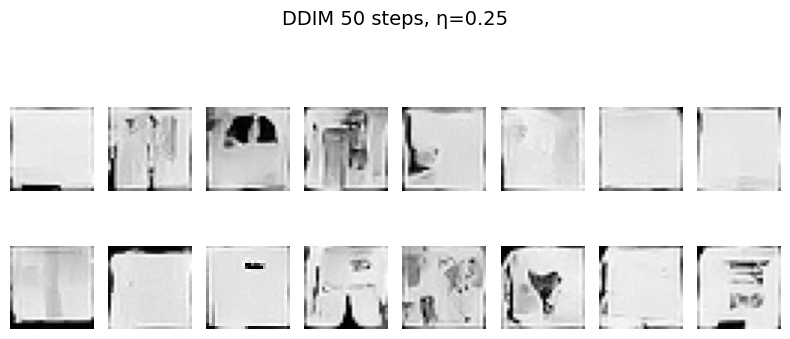

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

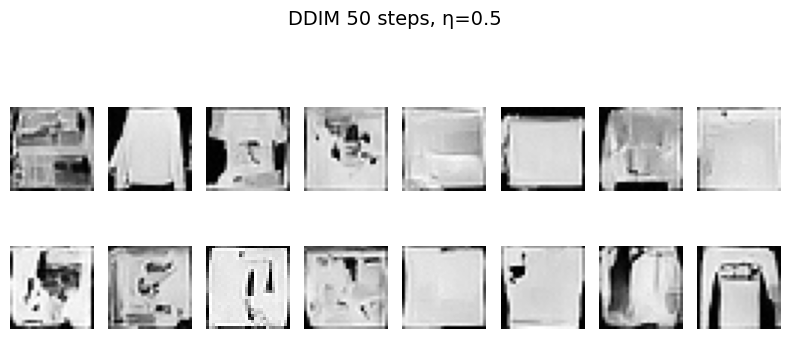

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

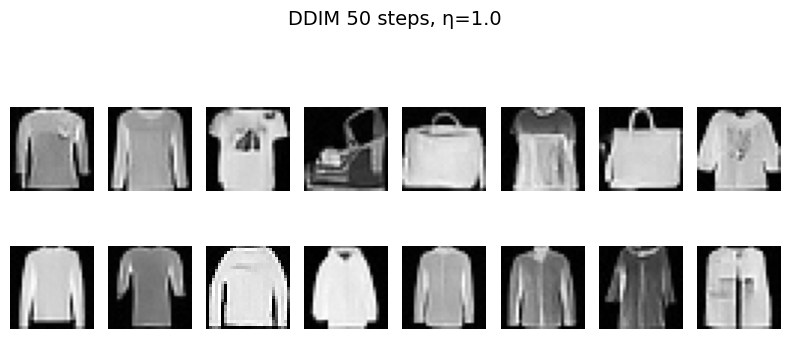

In [41]:
eta_values = [0.0, 0.25, 0.5, 1.0]
DDIM_STEPS_ETA = 50

for eta in eta_values:
    samples = ddim_sample(
        model, noise_schedule,
        n_samples=16,
        device=device,
        ddim_steps=DDIM_STEPS_ETA,
        eta=eta,
    )
    show_generated_grid(
        samples, nrow=8,
        title=f"DDIM {DDIM_STEPS_ETA} steps, η={eta}",
        figsize=(8, 4),
    )

### DeepCache

#### DDPM with Feature Caching

In [42]:
cache_intervals = [1, 2, 3, 5, 10]
ddpm_dc_results = {}

for N in cache_intervals:
    if N == 1:
        start = time.time()
        samples = ddpm_sample(model, noise_schedule, n_samples=64, device=device)
        elapsed = time.time() - start
    else:
        start = time.time()
        samples = ddpm_sample_deepcache(
            model, noise_schedule, n_samples=64, device=device,
            cache_interval=N,
        )
        elapsed = time.time() - start

    ddpm_dc_results[N] = {"samples": samples, "time": elapsed}
    full_steps = 1000 // N if N > 1 else 1000
    cached_steps = 1000 - full_steps if N > 1 else 0
    print(f"DDPM DeepCache N={N:>2d}: {elapsed:.2f}s  "
          f"(full={full_steps}, cached={cached_steps})")

DDPM Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM DeepCache N= 1: 6.75s  (full=1000, cached=0)


DDPM+DeepCache(N=2):   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM DeepCache N= 2: 4.91s  (full=500, cached=500)


DDPM+DeepCache(N=3):   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM DeepCache N= 3: 4.27s  (full=333, cached=667)


DDPM+DeepCache(N=5):   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM DeepCache N= 5: 3.79s  (full=200, cached=800)


DDPM+DeepCache(N=10):   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM DeepCache N=10: 3.43s  (full=100, cached=900)


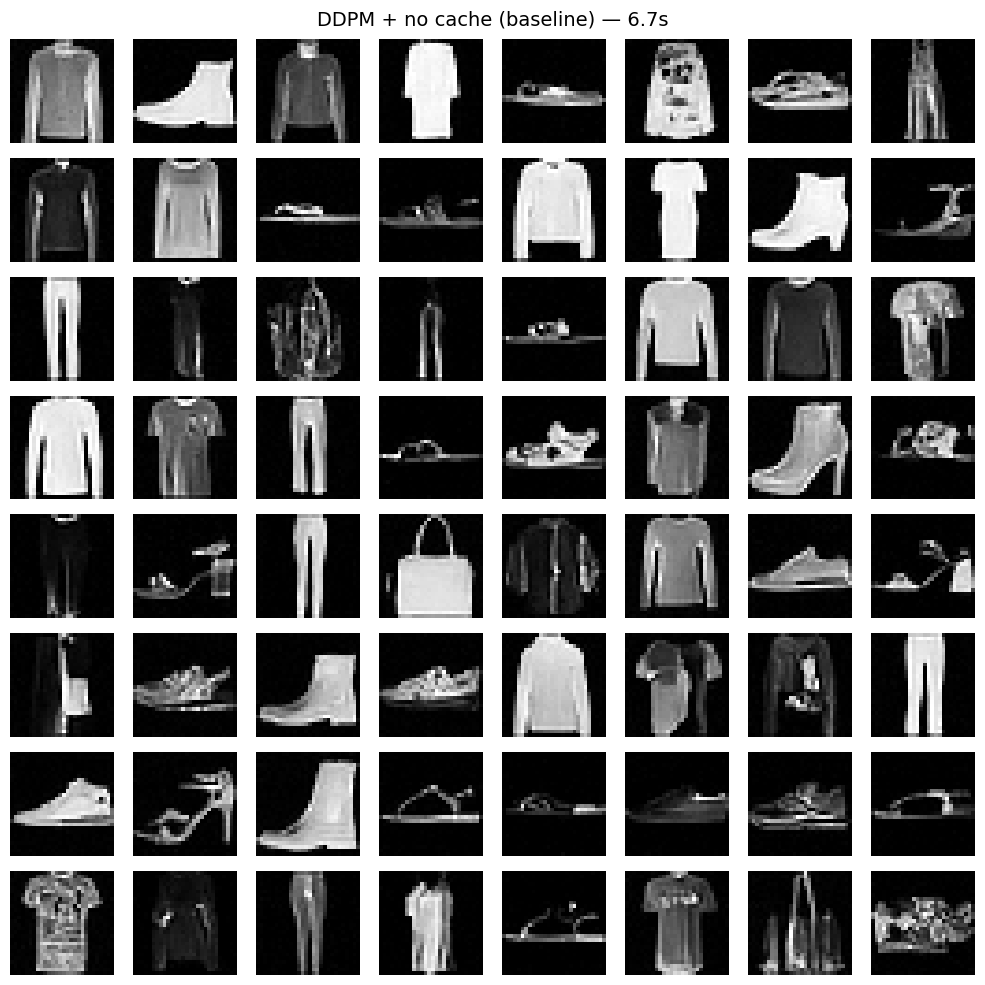

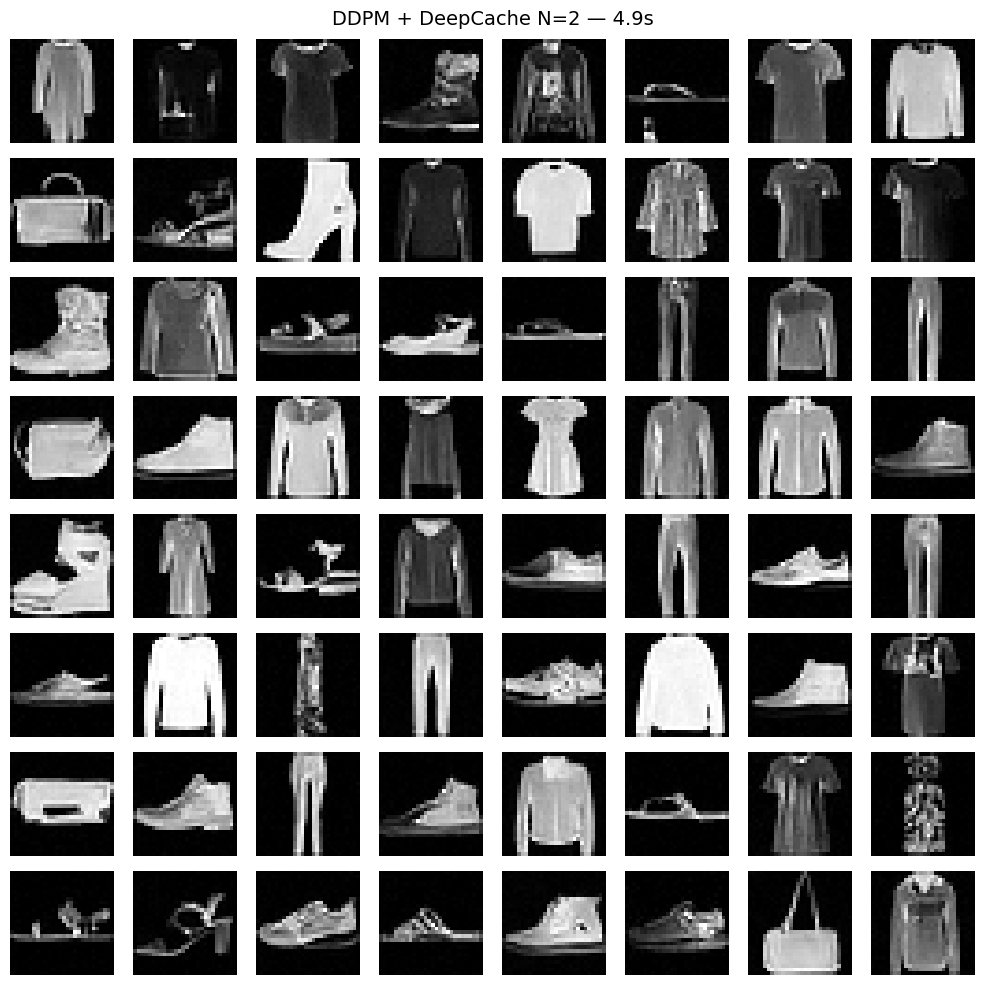

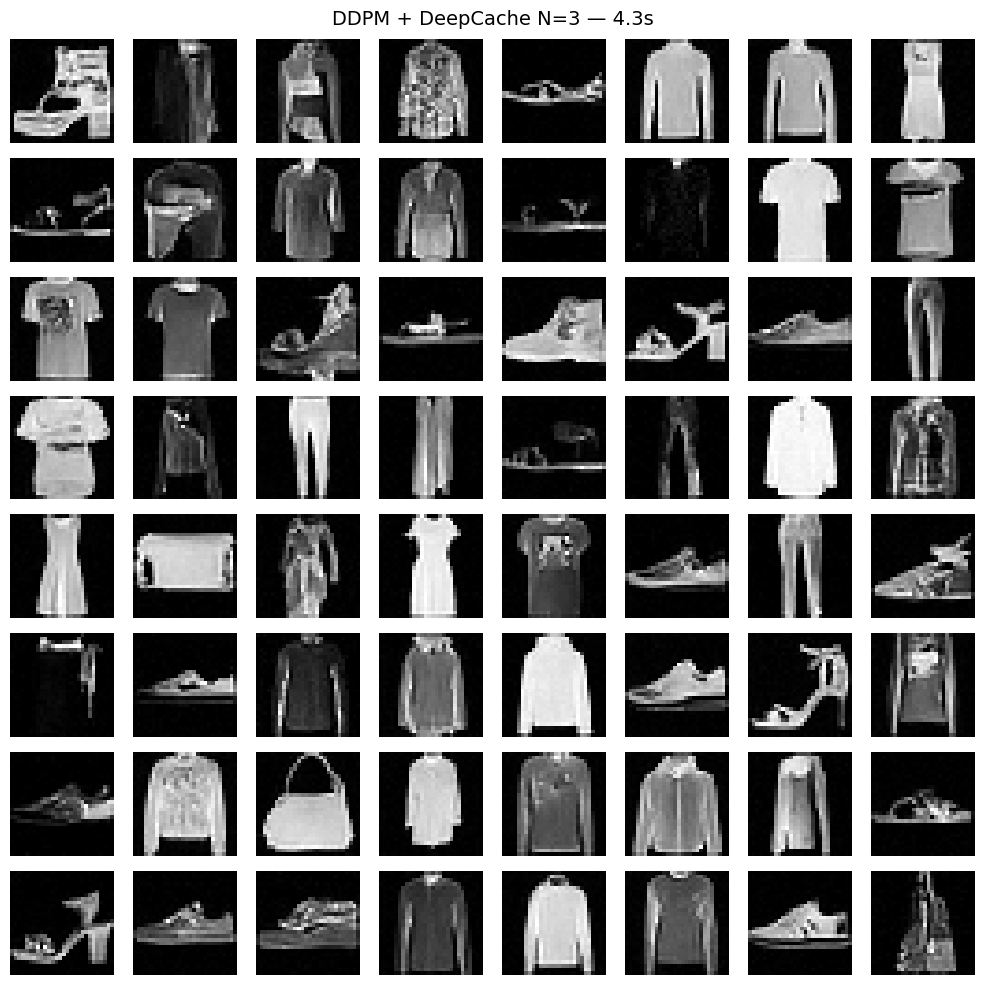

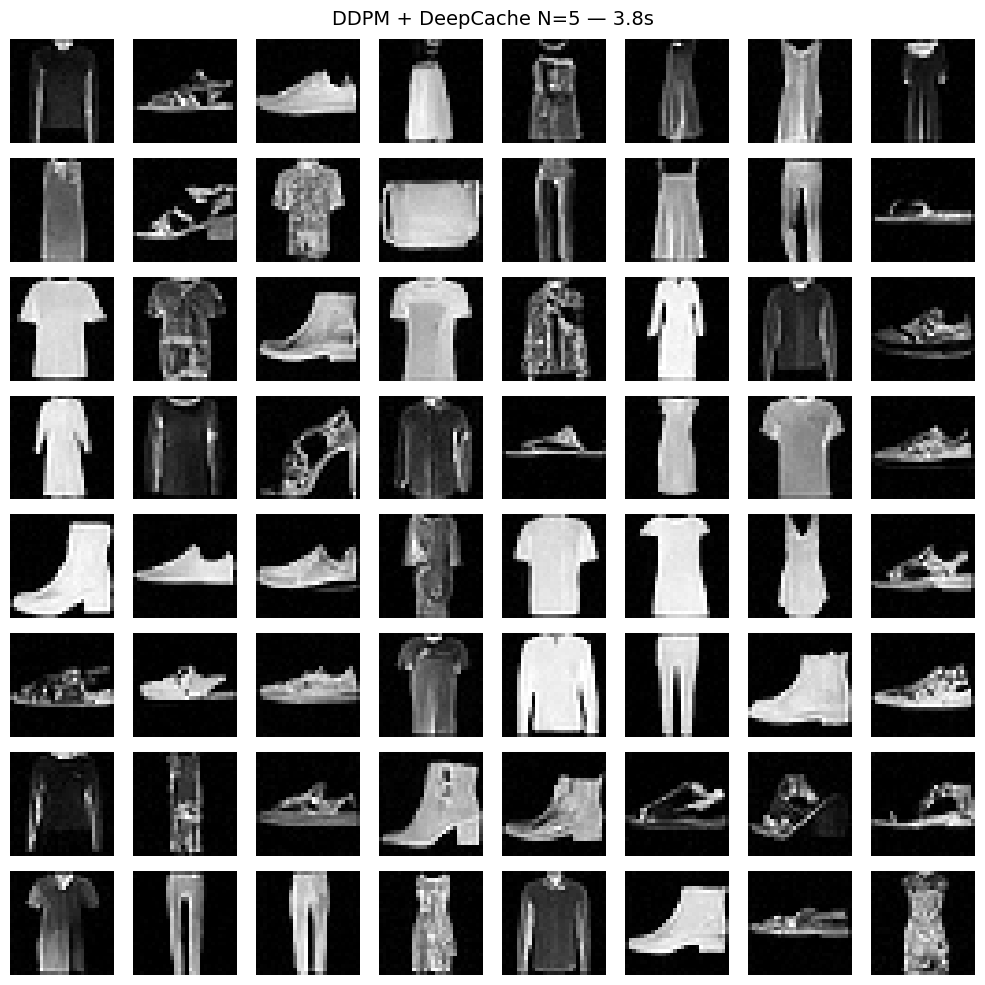

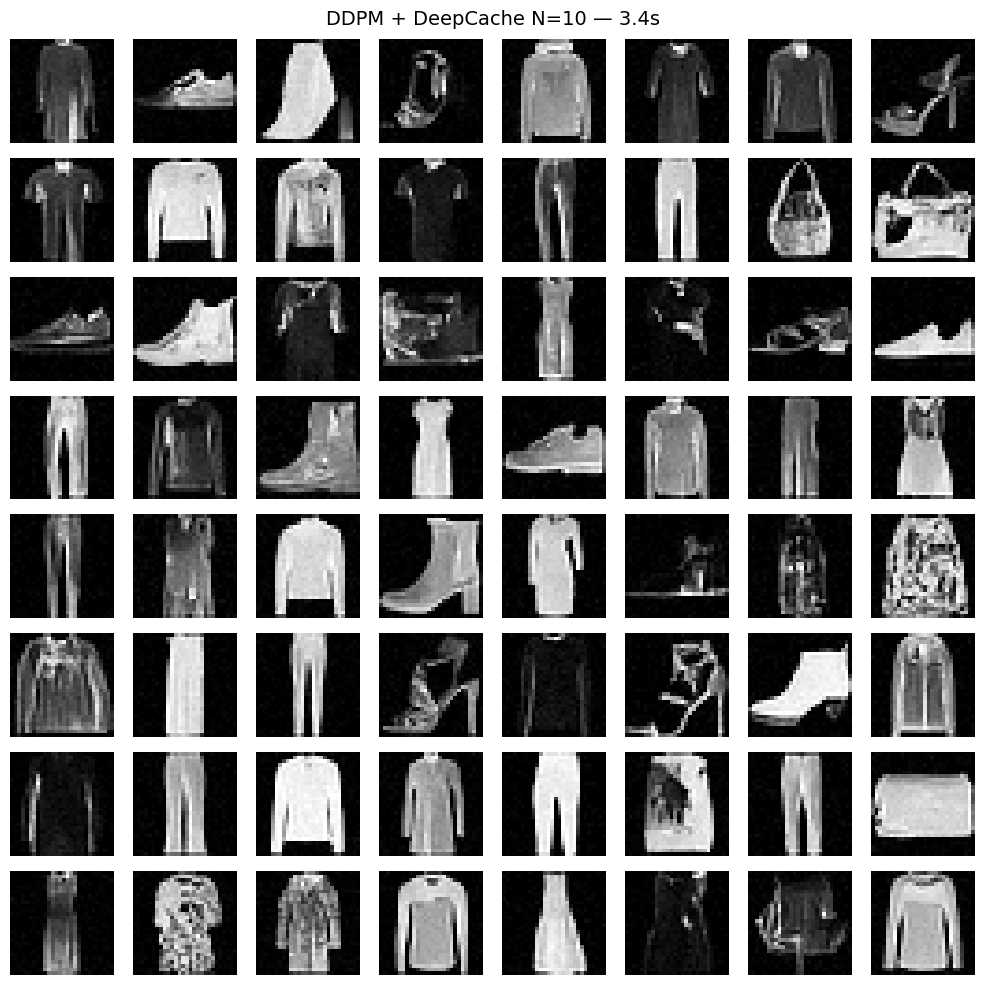

In [43]:
for N, res in ddpm_dc_results.items():
    label = "no cache (baseline)" if N == 1 else f"DeepCache N={N}"
    show_generated_grid(
        res["samples"], nrow=8,
        title=f"DDPM + {label} — {res['time']:.1f}s",
        figsize=(10, 10),
    )

#### DDIM with Feature Caching

In [44]:
ddim_dc_results = {}

ddim_steps_to_test = [50, 100]
cache_intervals_ddim = [1, 2, 3, 5]

for steps in ddim_steps_to_test:
    for N in cache_intervals_ddim:
        key = (steps, N)
        if N == 1:
            start = time.time()
            samples = ddim_sample(model, noise_schedule, n_samples=64, device=device,
                                  ddim_steps=steps, eta=0.0)
            elapsed = time.time() - start
        else:
            start = time.time()
            samples = ddim_sample_deepcache(
                model, noise_schedule, n_samples=64, device=device,
                ddim_steps=steps, eta=0.0, cache_interval=N,
            )
            elapsed = time.time() - start

        ddim_dc_results[key] = {"samples": samples, "time": elapsed}
        full = math.ceil(steps / N)
        cached = steps - full
        print(f"DDIM-{steps} DeepCache N={N}: {elapsed:.2f}s  "
              f"(full={full}, cached={cached})")

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM-50 DeepCache N=1: 0.36s  (full=50, cached=0)


DDIM(50)+DC(N=2):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM-50 DeepCache N=2: 0.26s  (full=25, cached=25)


DDIM(50)+DC(N=3):   0%|          | 0/50 [00:00<?, ?it/s]

...

DDIM-100 DeepCache N=2: 0.50s  (full=50, cached=50)


DDIM(100)+DC(N=3):   0%|          | 0/100 [00:00<?, ?it/s]

DDIM-100 DeepCache N=3: 0.45s  (full=34, cached=66)


DDIM(100)+DC(N=5):   0%|          | 0/100 [00:00<?, ?it/s]

DDIM-100 DeepCache N=5: 0.39s  (full=20, cached=80)


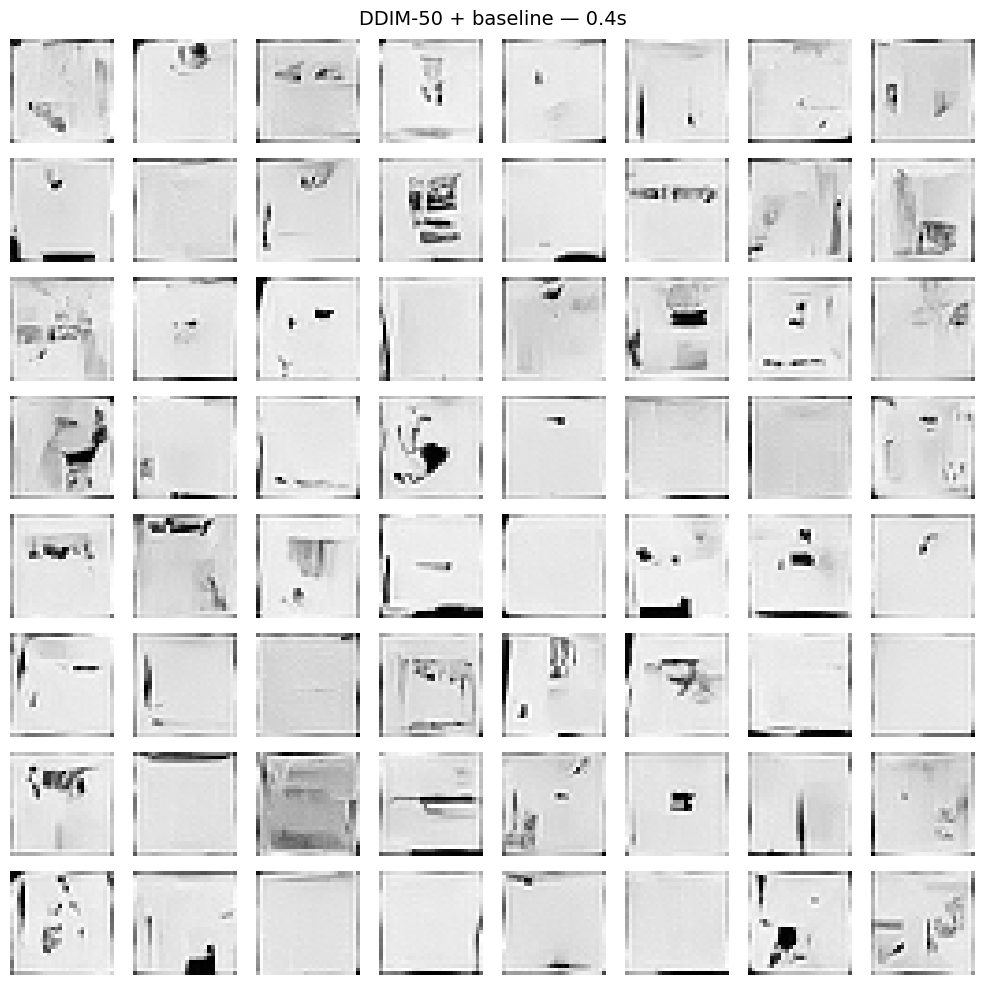

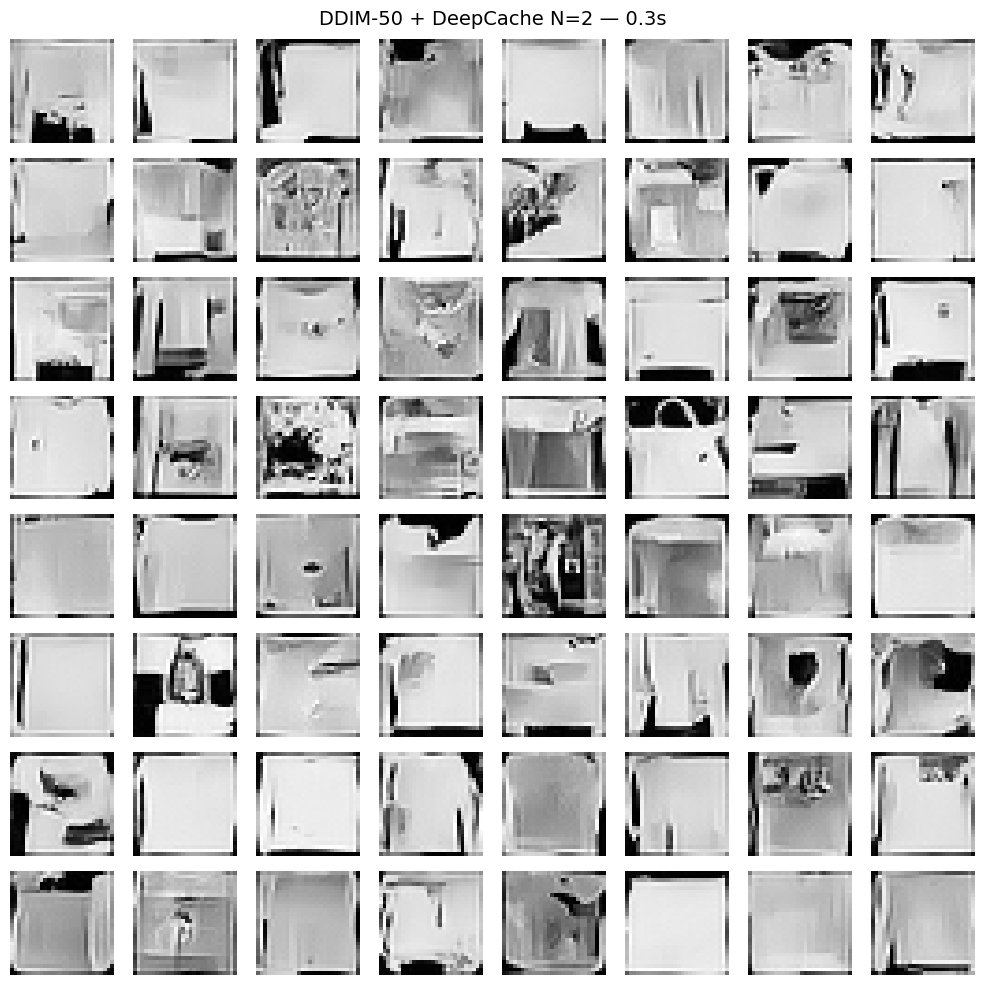

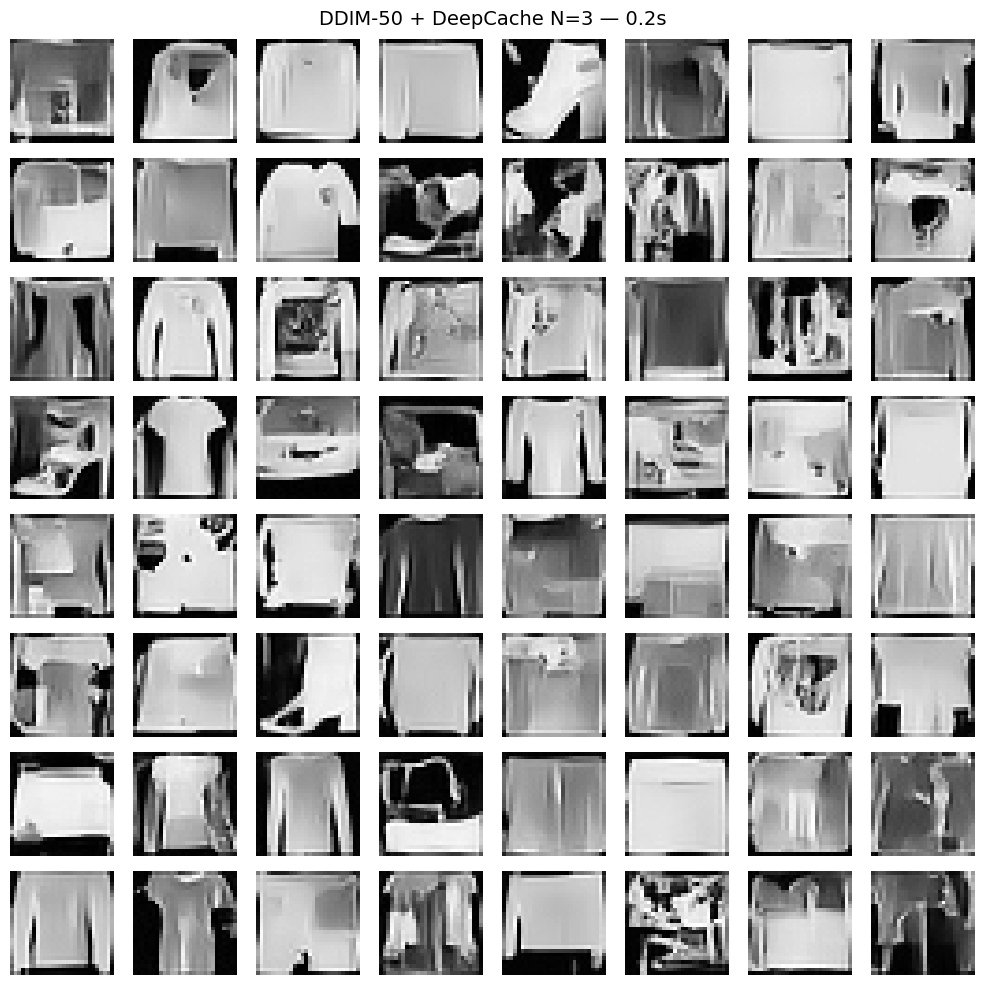

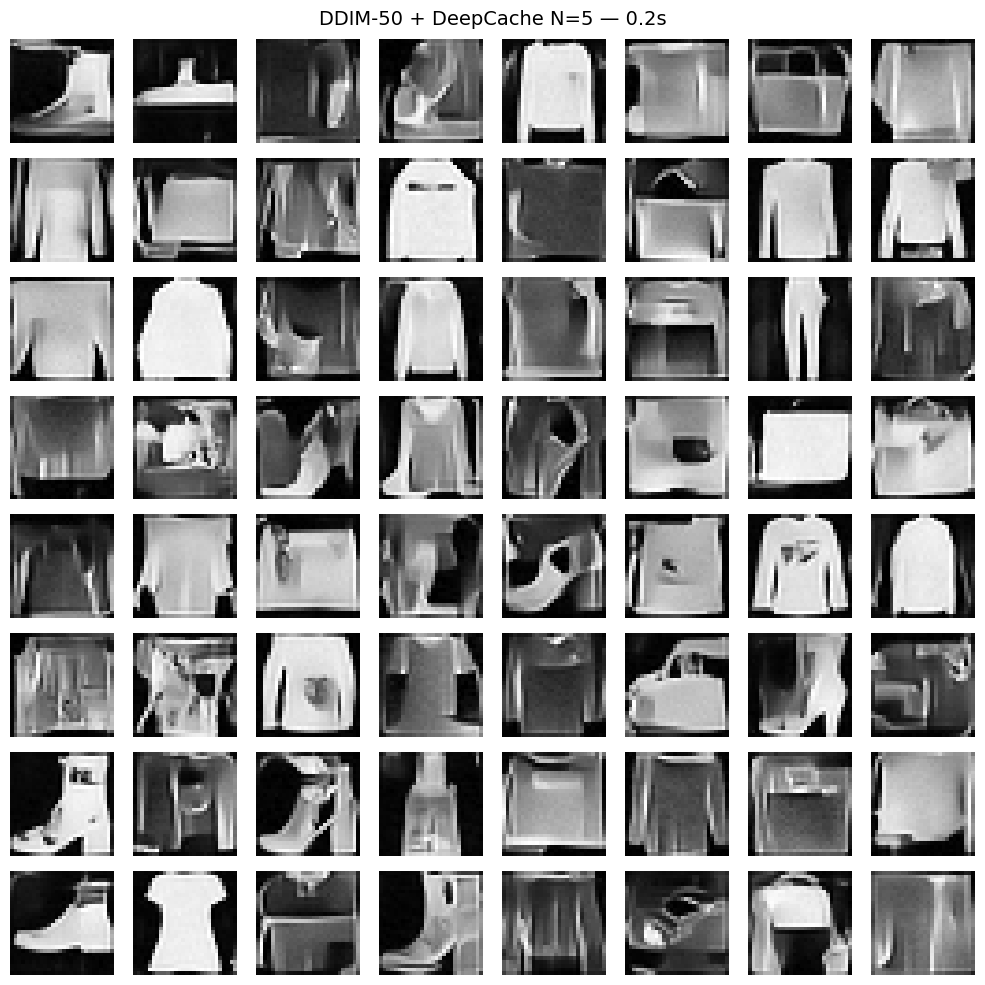

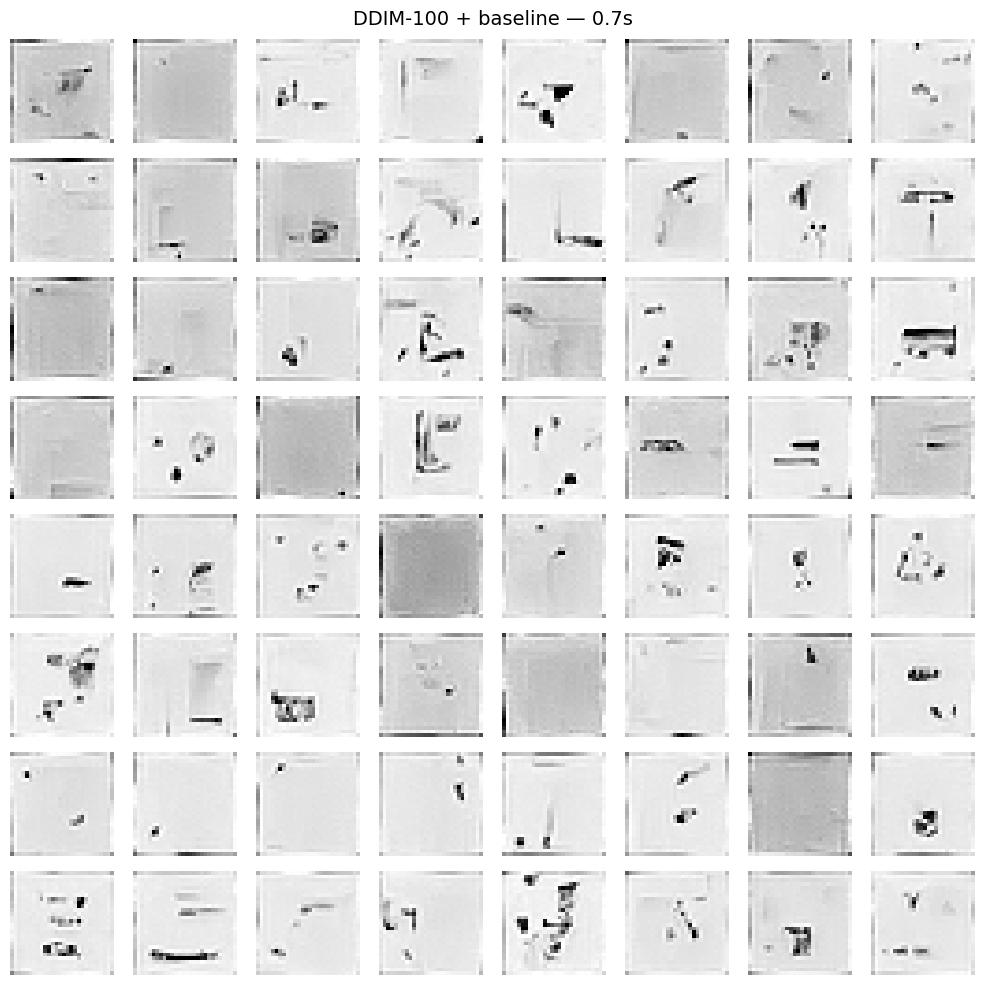

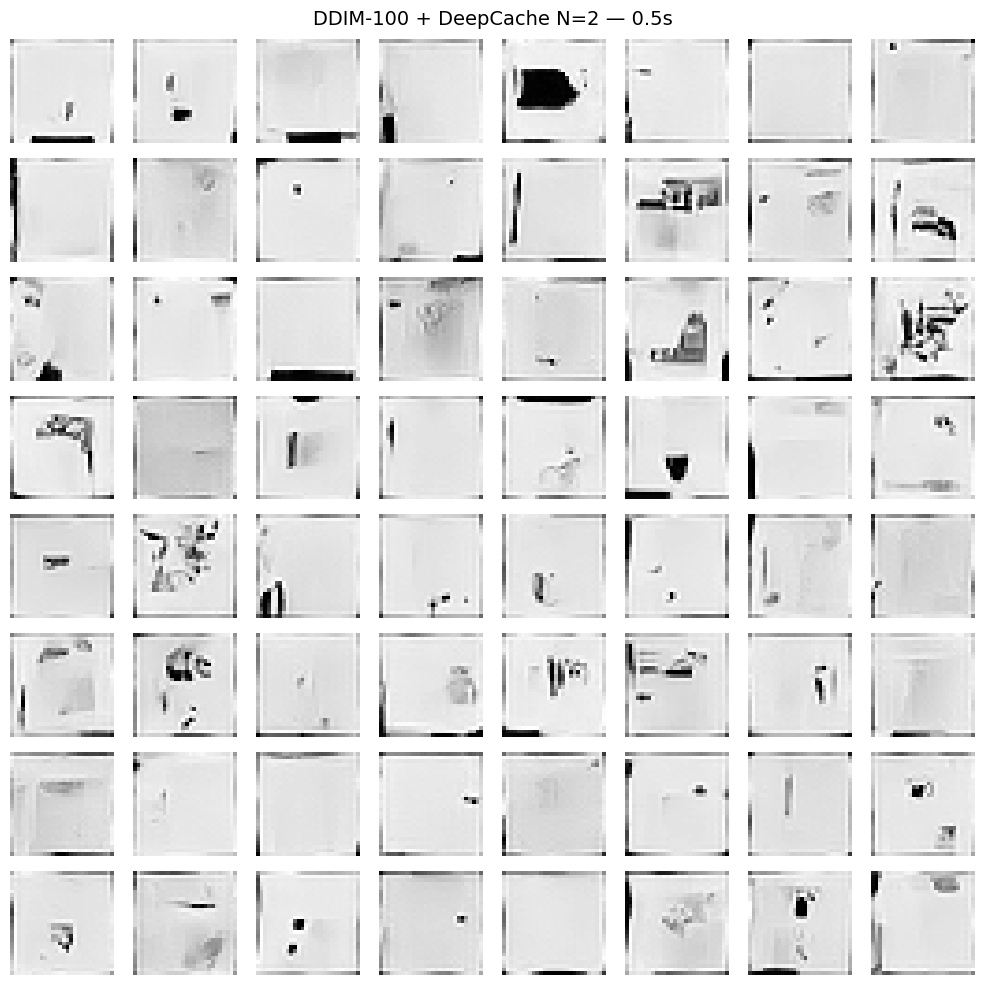

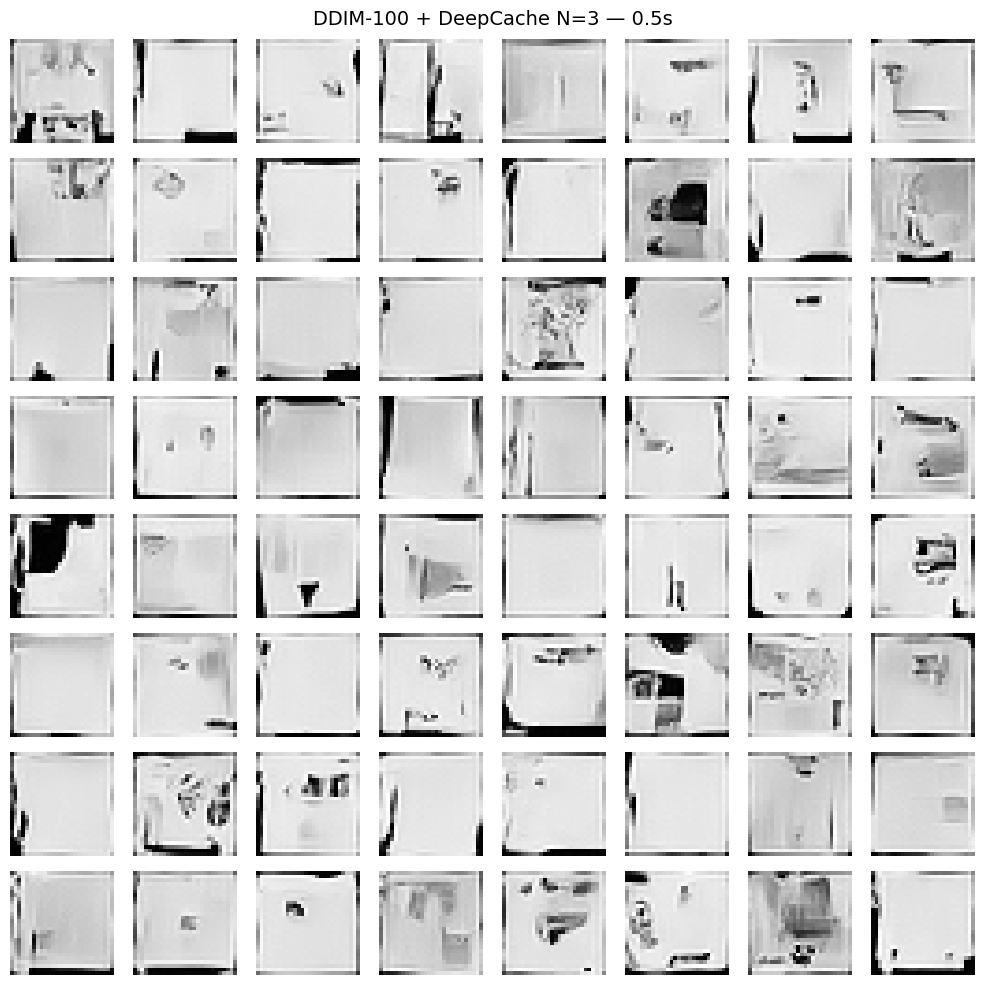

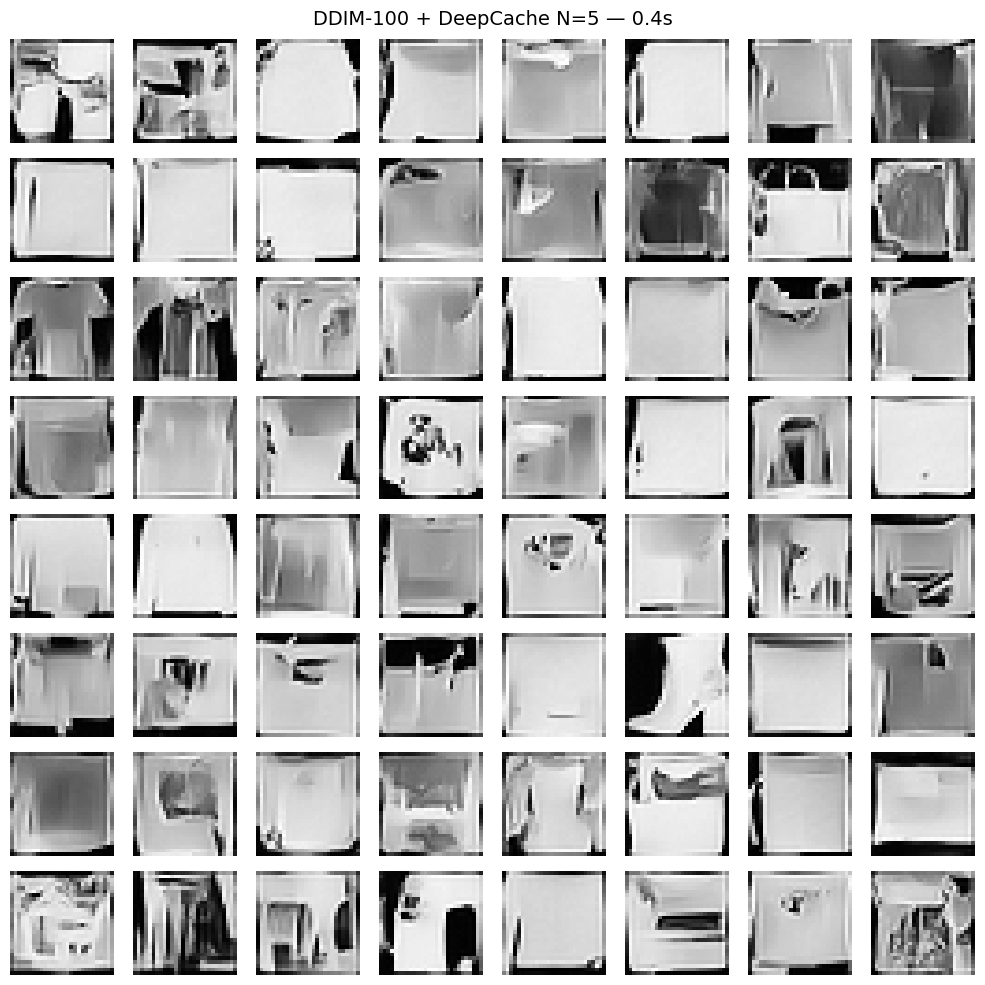

In [45]:
for (steps, N), res in ddim_dc_results.items():
    label = "baseline" if N == 1 else f"DeepCache N={N}"
    show_generated_grid(
        res["samples"], nrow=8,
        title=f"DDIM-{steps} + {label} — {res['time']:.1f}s",
        figsize=(10, 10),
    )

# Comparison & Results (on MNIST)

## Timing Comparison

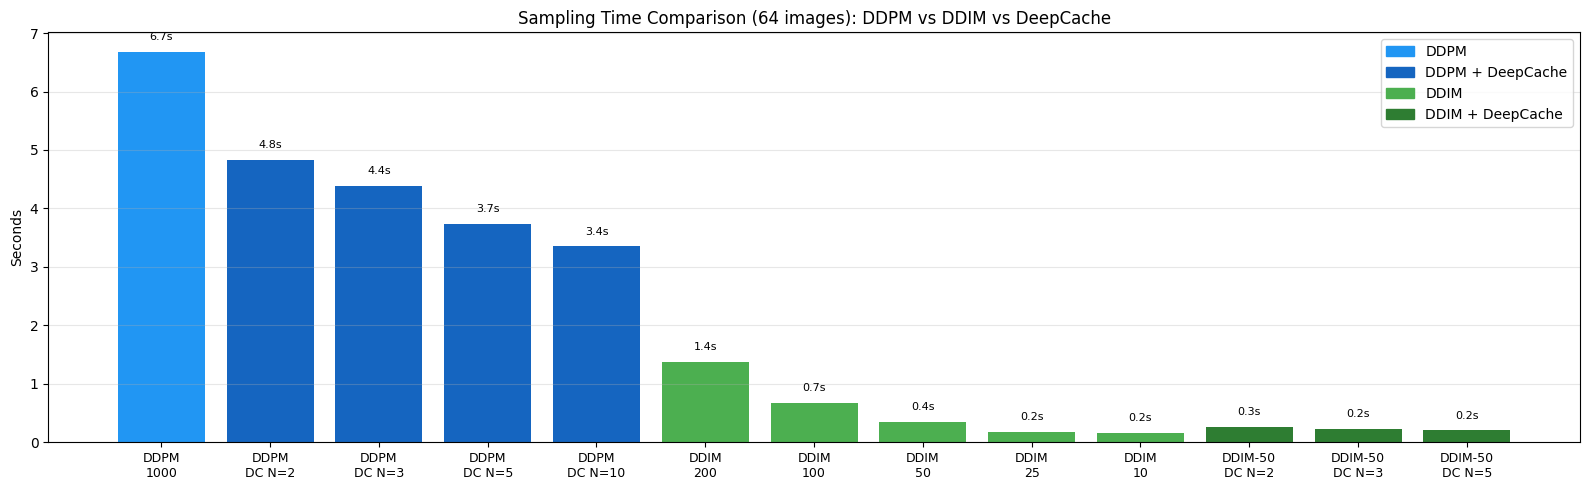

In [29]:
all_methods = []
all_times = []
all_colors = []

# DDPM baselines
all_methods.append("DDPM\n1000")
all_times.append(ddpm_dc_results[1]["time"])
all_colors.append("#2196F3")

# DDPM + DeepCache
for N in [2, 3, 5, 10]:
    if N in ddpm_dc_results:
        all_methods.append(f"DDPM\nDC N={N}")
        all_times.append(ddpm_dc_results[N]["time"])
        all_colors.append("#1565C0")

# DDIM baselines
for steps in [200, 100, 50, 25, 10]:
    if steps in ddim_results:
        all_methods.append(f"DDIM\n{steps}")
        all_times.append(ddim_results[steps]["time"])
        all_colors.append("#4CAF50")

# DDIM + DeepCache (50 steps)
for N in [2, 3, 5]:
    key = (50, N)
    if key in ddim_dc_results:
        all_methods.append(f"DDIM-50\nDC N={N}")
        all_times.append(ddim_dc_results[key]["time"])
        all_colors.append("#2E7D32")

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(range(len(all_methods)), all_times, color=all_colors)
ax.set_xticks(range(len(all_methods)))
ax.set_xticklabels(all_methods, fontsize=9)
ax.set_ylabel("Seconds")
ax.set_title("Sampling Time Comparison (64 images): DDPM vs DDIM vs DeepCache")

for bar, t in zip(bars, all_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{t:.1f}s", ha="center", fontsize=8)

ax.legend(handles=[
    Patch(color="#2196F3", label="DDPM"),
    Patch(color="#1565C0", label="DDPM + DeepCache"),
    Patch(color="#4CAF50", label="DDIM"),
    Patch(color="#2E7D32", label="DDIM + DeepCache"),
], loc="upper right")

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Speed Comparison

In [30]:
# DDPM-1000 baseline
baseline_time = ddpm_dc_results[1]["time"]

print("=" * 65)
print(f"{'Method':<25} {'Time (s)':<12} {'Speedup':<10} {'Notes'}")
print("=" * 65)

# DDPM variants
print(f"{'DDPM-1000':<25} {baseline_time:<12.2f} {'1.0x':<10} {'baseline'}")
for N in [2, 3, 5, 10]:
    if N in ddpm_dc_results:
        t = ddpm_dc_results[N]["time"]
        print(f"{'DDPM + DC N=' + str(N):<25} {t:<12.2f} {baseline_time/t:.1f}x{'':>8}")
print("-" * 65)

# DDIM variants
for steps in ddim_step_counts:
    t = ddim_results[steps]["time"]
    print(f"{'DDIM-' + str(steps):<25} {t:<12.2f} {baseline_time/t:.1f}x{'':>8}")
print("-" * 65)

# DDIM + DeepCache
for (steps, N), res in ddim_dc_results.items():
    if N > 1:
        t = res["time"]
        full = math.ceil(steps / N)
        print(f"{'DDIM-' + str(steps) + ' + DC N=' + str(N):<25} {t:<12.2f} "
              f"{baseline_time/t:.1f}x{'':>6} {full} full fwd")
print("=" * 65)

Method                    Time (s)     Speedup    Notes
DDPM-1000                 6.68         1.0x       baseline
DDPM + DC N=2             4.83         1.4x        
DDPM + DC N=3             4.38         1.5x        
DDPM + DC N=5             3.74         1.8x        
DDPM + DC N=10            3.35         2.0x        
-----------------------------------------------------------------
DDIM-10                   0.16         42.9x        
DDIM-25                   0.18         36.4x        
DDIM-50                   0.35         18.8x        
DDIM-100                  0.68         9.8x        
DDIM-200                  1.37         4.9x        
-----------------------------------------------------------------
DDIM-50 + DC N=2          0.27         25.2x       25 full fwd
DDIM-50 + DC N=3          0.23         28.9x       17 full fwd
DDIM-50 + DC N=5          0.20         33.0x       10 full fwd
DDIM-100 + DC N=2         0.50         13.3x       50 full fwd
DDIM-100 + DC N=3         0.45

## Quality Comparison

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM Sampling (10 steps):   0%|          | 0/10 [00:00<?, ?it/s]

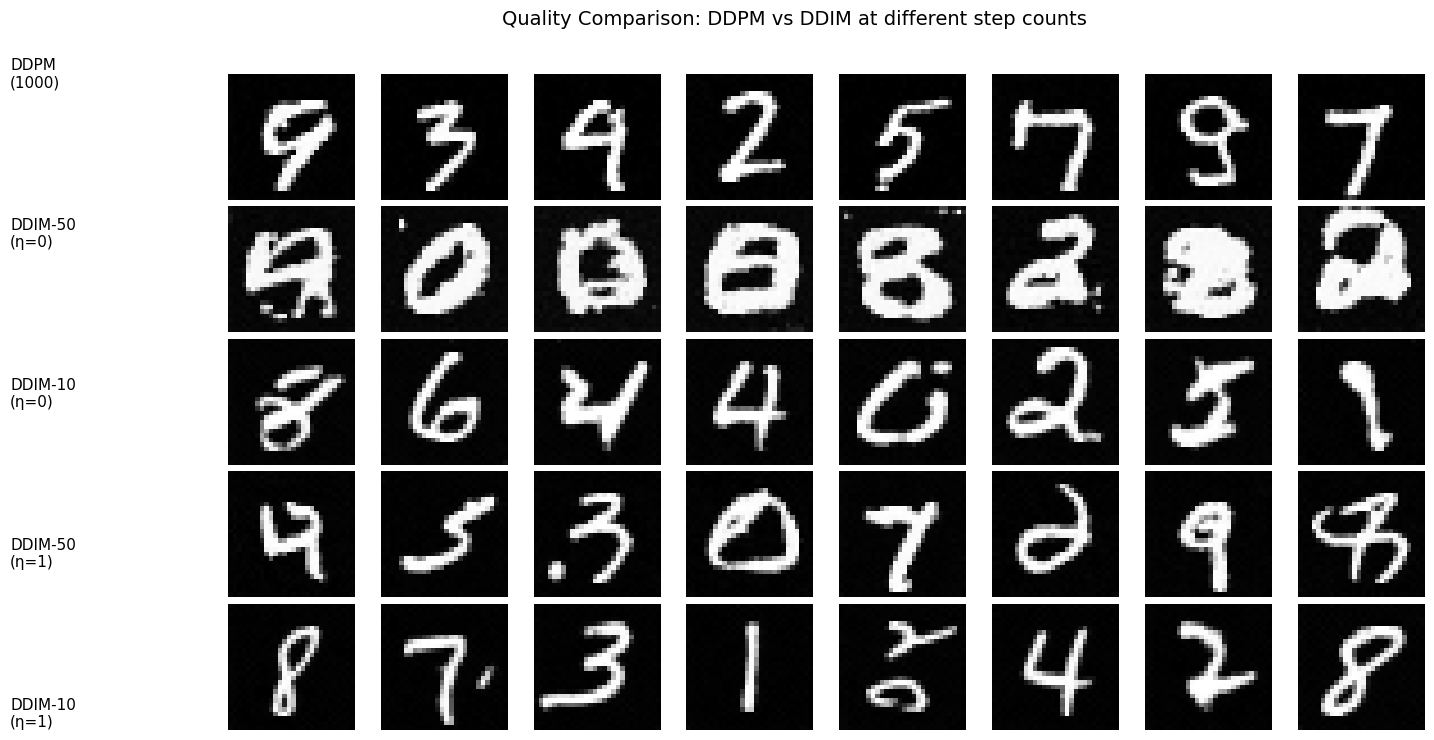

DDIM(50)+DC(N=3):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM(50)+DC(N=5):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM(50)+DC(N=3):   0%|          | 0/50 [00:00<?, ?it/s]

DDIM(50)+DC(N=5):   0%|          | 0/50 [00:00<?, ?it/s]

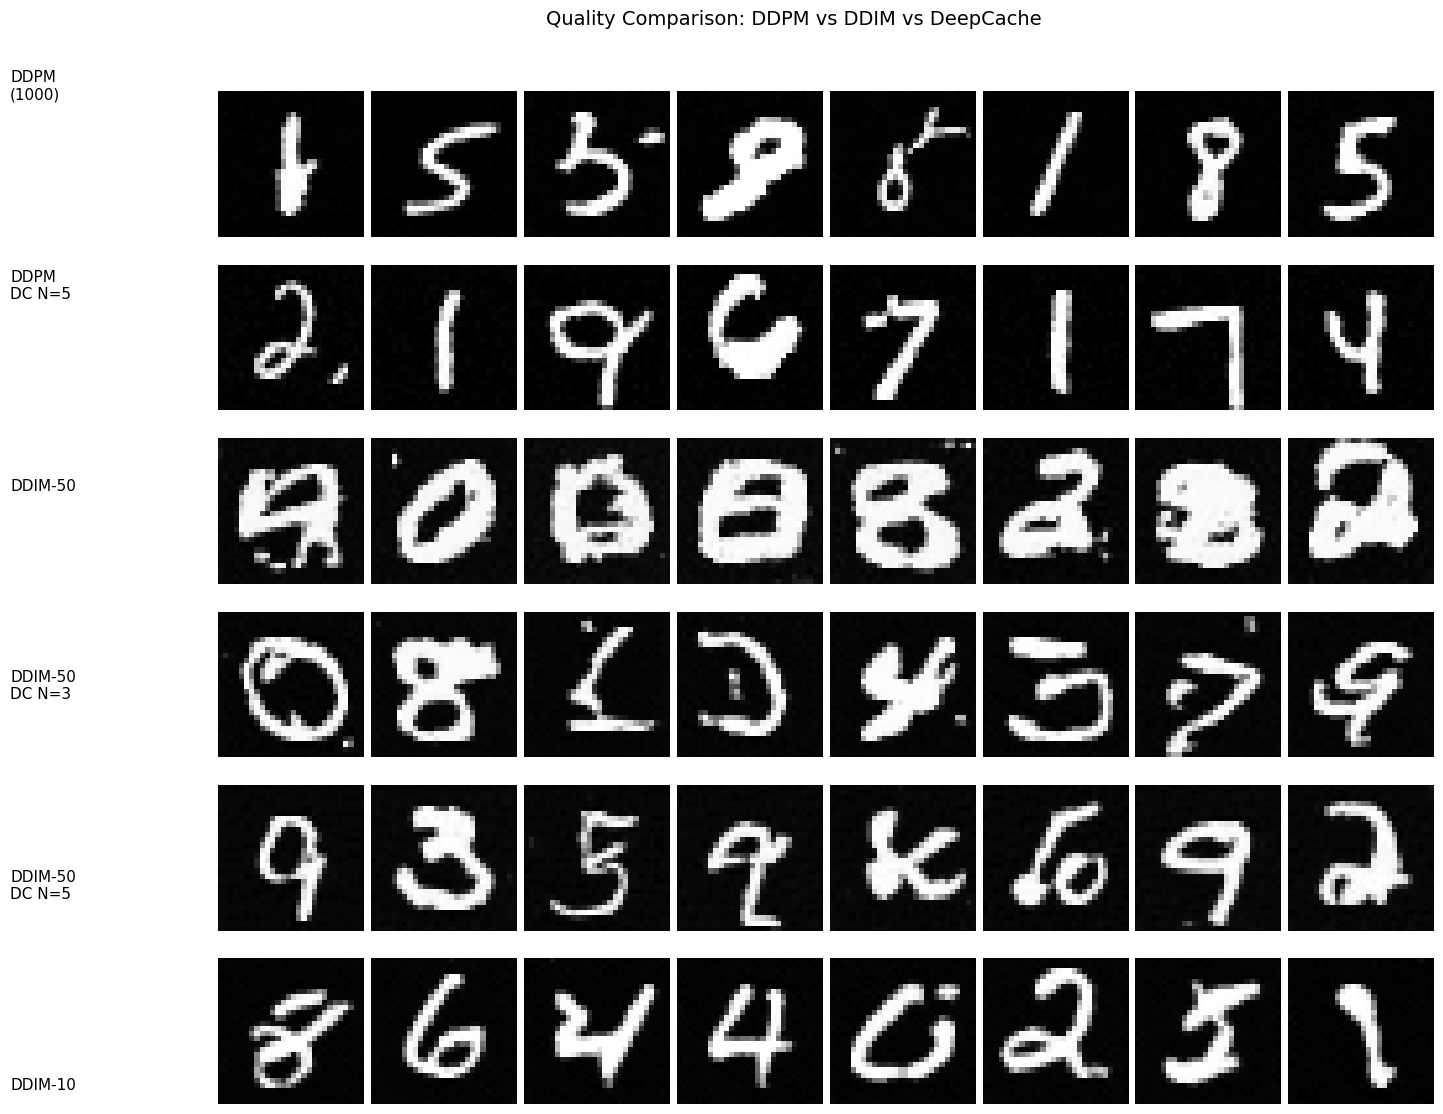

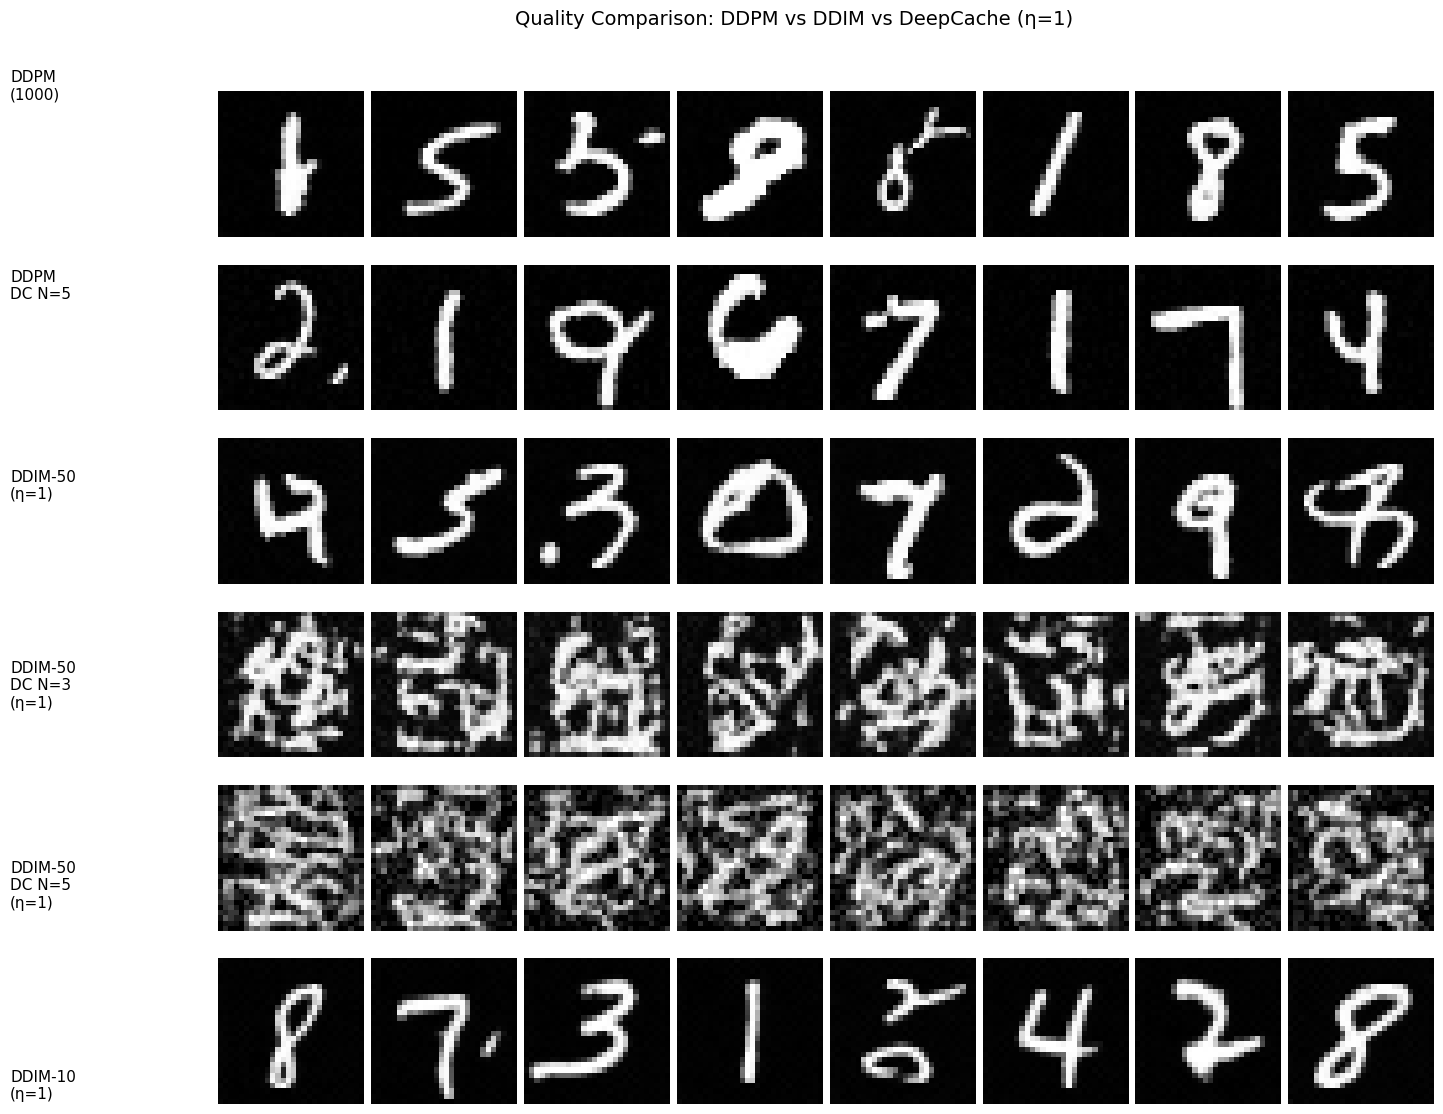

In [31]:
ddim50_eta1 = ddim_sample(
    model=model,
    noise_schedule=noise_schedule,
    n_samples=64,
    img_shape=(1, 28, 28),
    device=device,
    ddim_steps=50,
    eta=1.0,
)

ddim10_eta1 = ddim_sample(
    model=model,
    noise_schedule=noise_schedule,
    n_samples=64,
    img_shape=(1, 28, 28),
    device=device,
    ddim_steps=10,
    eta=1.0,
)

fig, axes = plt.subplots(5, 8, figsize=(16, 8))

ddpm_vis = denormalize(ddpm_samples[:8]).cpu()
for j in range(8):
    axes[0, j].imshow(ddpm_vis[j].squeeze(0), cmap="gray")
    axes[0, j].axis("off")

ddim50_vis = denormalize(ddim_results[50]["samples"][:8]).cpu()
for j in range(8):
    axes[1, j].imshow(ddim50_vis[j].squeeze(0), cmap="gray")
    axes[1, j].axis("off")

ddim10_vis = denormalize(ddim_results[10]["samples"][:8]).cpu()
for j in range(8):
    axes[2, j].imshow(ddim10_vis[j].squeeze(0), cmap="gray")
    axes[2, j].axis("off")

ddim50_eta1_vis = denormalize(ddim50_eta1[:8]).cpu()
for j in range(8):
    axes[3, j].imshow(ddim50_eta1_vis[j].squeeze(0), cmap="gray")
    axes[3, j].axis("off")

ddim10_eta1_vis = denormalize(ddim10_eta1[:8]).cpu()
for j in range(8):
    axes[4, j].imshow(ddim10_eta1_vis[j].squeeze(0), cmap="gray")
    axes[4, j].axis("off")

row_labels = [
    "DDPM\n(1000)",
    "DDIM-50\n(η=0)",
    "DDIM-10\n(η=0)",
    "DDIM-50\n(η=1)",
    "DDIM-10\n(η=1)",
]
ys = [1 - (i + 0.5) / len(row_labels) for i in range(len(row_labels))]
for y, label in zip(ys, row_labels):
    fig.text(0.01, y, label, ha="left", va="center", fontsize=11)

fig.suptitle("Quality Comparison: DDPM vs DDIM at different step counts", fontsize=14)
plt.subplots_adjust(left=0.14, top=0.90, bottom=0.08, wspace=0.05, hspace=0.05)
plt.show()


ddim_dc_results = {}

start = time.time()
samples = ddim_sample_deepcache(
    model, noise_schedule,
    n_samples=64, img_shape=(1, 28, 28), device=device,
    ddim_steps=50, eta=0.0, cache_interval=3
)
elapsed = time.time() - start
ddim_dc_results[(50, 3)] = {"samples": samples, "time": elapsed}

start = time.time()
samples = ddim_sample_deepcache(
    model, noise_schedule,
    n_samples=64, img_shape=(1, 28, 28), device=device,
    ddim_steps=50, eta=0.0, cache_interval=5
)
elapsed = time.time() - start
ddim_dc_results[(50, 5)] = {"samples": samples, "time": elapsed}

start = time.time()
samples = ddim_sample_deepcache(
    model, noise_schedule,
    n_samples=64, img_shape=(1, 28, 28), device=device,
    ddim_steps=50, eta=1.0, cache_interval=3
)
elapsed = time.time() - start
ddim_dc_results[(50, 3, 1.0)] = {"samples": samples, "time": elapsed}

start = time.time()
samples = ddim_sample_deepcache(
    model, noise_schedule,
    n_samples=64, img_shape=(1, 28, 28), device=device,
    ddim_steps=50, eta=1.0, cache_interval=5
)
elapsed = time.time() - start
ddim_dc_results[(50, 5, 1.0)] = {"samples": samples, "time": elapsed}


fig, axes = plt.subplots(6, 8, figsize=(16, 12))
row_labels = [
    "DDPM\n(1000)",
    "DDPM\nDC N=5",
    "DDIM-50",
    "DDIM-50\nDC N=3",
    "DDIM-50\nDC N=5",
    "DDIM-10",
]
row_data = [
    ddpm_dc_results[1]["samples"],
    ddpm_dc_results.get(5, ddpm_dc_results[1])["samples"],
    ddim_results[50]["samples"],
    ddim_dc_results.get((50, 3), {}).get("samples", ddim_results[50]["samples"]),
    ddim_dc_results.get((50, 5), {}).get("samples", ddim_results[50]["samples"]),
    ddim_results[10]["samples"],
]

for row_idx, samples in enumerate(row_data):
    vis = denormalize(samples[:8]).cpu()
    for j in range(8):
        axes[row_idx, j].imshow(vis[j].squeeze(0), cmap="gray")
        axes[row_idx, j].axis("off")

ys = [1 - (i + 0.5) / len(row_labels) for i in range(len(row_labels))]
for y, label in zip(ys, row_labels):
    fig.text(0.01, y, label, ha="left", va="center", fontsize=11)

fig.suptitle("Quality Comparison: DDPM vs DDIM vs DeepCache", fontsize=14)
plt.subplots_adjust(left=0.14, top=0.92, bottom=0.06, wspace=0.05, hspace=0.05)
plt.show()


fig, axes = plt.subplots(6, 8, figsize=(16, 12))
row_labels = [
    "DDPM\n(1000)",
    "DDPM\nDC N=5",
    "DDIM-50\n(η=1)",
    "DDIM-50\nDC N=3\n(η=1)",
    "DDIM-50\nDC N=5\n(η=1)",
    "DDIM-10\n(η=1)",
]
row_data = [
    ddpm_dc_results[1]["samples"],
    ddpm_dc_results.get(5, ddpm_dc_results[1])["samples"],
    ddim50_eta1,
    ddim_dc_results.get((50, 3, 1.0), {}).get("samples", ddim50_eta1),
    ddim_dc_results.get((50, 5, 1.0), {}).get("samples", ddim50_eta1),
    ddim10_eta1,
]

for row_idx, samples in enumerate(row_data):
    vis = denormalize(samples[:8]).cpu()
    for j in range(8):
        axes[row_idx, j].imshow(vis[j].squeeze(0), cmap="gray")
        axes[row_idx, j].axis("off")

ys = [1 - (i + 0.5) / len(row_labels) for i in range(len(row_labels))]
for y, label in zip(ys, row_labels):
    fig.text(0.01, y, label, ha="left", va="center", fontsize=11)

fig.suptitle("Quality Comparison: DDPM vs DDIM vs DeepCache (η=1)", fontsize=14)
plt.subplots_adjust(left=0.14, top=0.92, bottom=0.06, wspace=0.05, hspace=0.05)
plt.show()

## DeepCache Quality Degradation Analysis

Measures how much the generated samples diverge from the non-cached baseline by computing the per-pixel MSE between cached and non-cached outputs

DeepCache N=2: MSE vs baseline = 0.256480
DeepCache N=3: MSE vs baseline = 0.384401
DeepCache N=5: MSE vs baseline = 0.460266
DeepCache N=10: MSE vs baseline = 0.569515


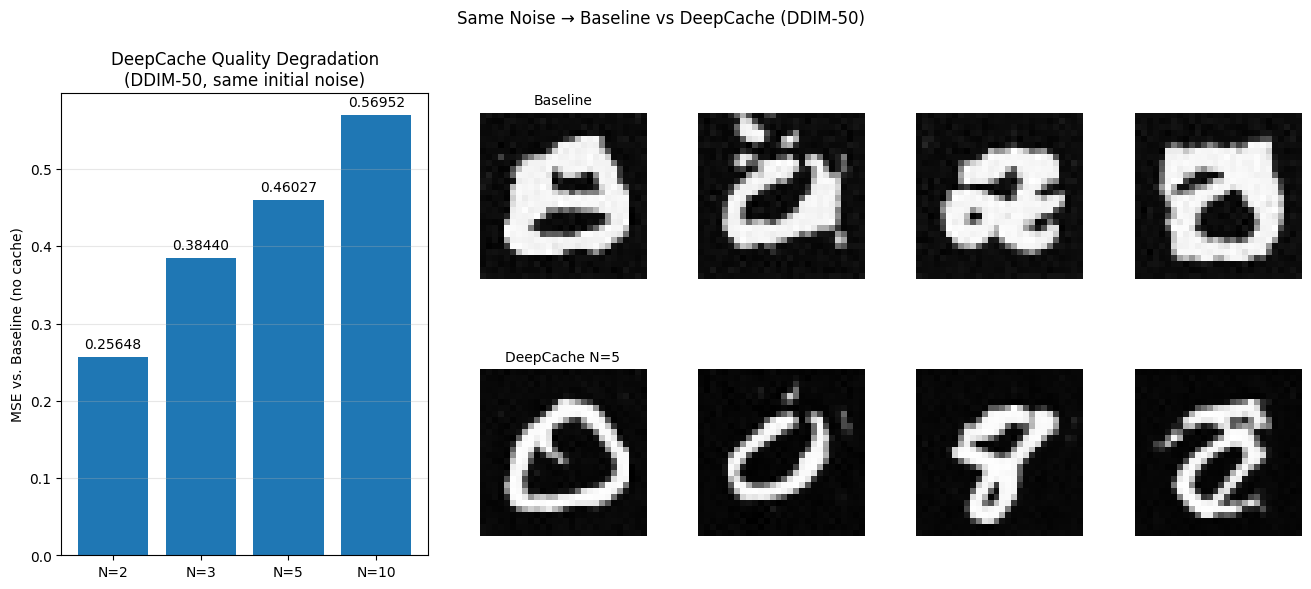

In [35]:
torch.manual_seed(42)
fixed_noise = torch.randn(16, 1, 28, 28, device=device)

@torch.no_grad()
def ddim_from_noise(noise, steps=50, cache_interval=1):
    ns = noise_schedule
    step_size = ns.T // steps
    timesteps = list(reversed(range(0, ns.T, step_size)))

    x = noise.clone()
    cache = None

    for i in range(len(timesteps)):
        t_cur = timesteps[i]
        t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else 0

        t_batch = torch.full((x.shape[0],), t_cur, device=device, dtype=torch.long)
        alpha_bar_t = ns.alpha_bar[t_cur]
        alpha_bar_prev = ns.alpha_bar[t_prev]

        if cache_interval > 1:
            use_cache = (cache is not None) and (i % cache_interval != 0)
            eps_pred, cache = model.forward_with_cache(x, t_batch, use_cache=use_cache, cache=cache)
        else:
            eps_pred = model(x, t_batch)

        x0_pred = ((x - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)).clamp(-1, 1)
        dir_xt = torch.sqrt(1 - alpha_bar_prev) * eps_pred
        x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt

    return x

model.eval()
baseline = ddim_from_noise(fixed_noise, steps=50, cache_interval=1)

cache_intervals_test = [2, 3, 5, 10]
mse_per_interval = {}

for N in cache_intervals_test:
    cached_out = ddim_from_noise(fixed_noise, steps=50, cache_interval=N)
    mse = F.mse_loss(cached_out, baseline).item()
    mse_per_interval[N] = mse
    print(f"DeepCache N={N}: MSE vs baseline = {mse:.6f}")

vis_baseline = denormalize(baseline[:4].detach()).cpu()
vis_cached = denormalize(ddim_from_noise(fixed_noise, steps=50, cache_interval=5)[:4].detach()).cpu()

fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(2, 5, width_ratios=[2.2, 1, 1, 1, 1], wspace=0.25, hspace=0.25)

ax_bar = fig.add_subplot(gs[:, 0])
Ns = list(mse_per_interval.keys())
mses = list(mse_per_interval.values())
ax_bar.bar([f"N={n}" for n in Ns], mses)
ax_bar.set_ylabel("MSE vs. Baseline (no cache)")
ax_bar.set_title("DeepCache Quality Degradation\n(DDIM-50, same initial noise)")
ax_bar.grid(axis="y", alpha=0.3)
y_offset = (max(mses) * 0.02) if len(mses) else 0.0
for i, m in enumerate(mses):
    ax_bar.text(i, m + y_offset, f"{m:.5f}", ha="center", fontsize=10)

for j in range(4):
    ax = fig.add_subplot(gs[0, 1 + j])
    ax.imshow(vis_baseline[j].squeeze(0), cmap="gray")
    ax.axis("off")
    if j == 0:
        ax.set_title("Baseline", fontsize=10)

for j in range(4):
    ax = fig.add_subplot(gs[1, 1 + j])
    ax.imshow(vis_cached[j].squeeze(0), cmap="gray")
    ax.axis("off")
    if j == 0:
        ax.set_title("DeepCache N=5", fontsize=10)

fig.suptitle("Same Noise → Baseline vs DeepCache (DDIM-50)", fontsize=12, y=1.02)
plt.show()

## Noise Prediction Quality Across Timesteps

Measures the MSE between the true noise and predicted noise at different timestep ranges on the test set

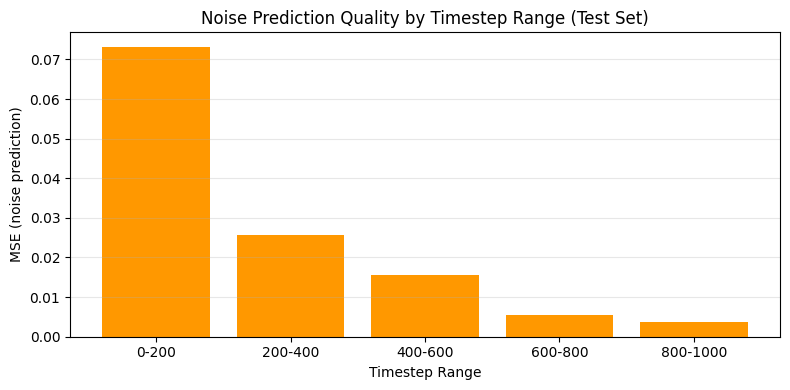

In [33]:
timestep_ranges = [(0, 200), (200, 400), (400, 600), (600, 800), (800, 1000)]
range_mses = {r: [] for r in timestep_ranges}

model.eval()
with torch.no_grad():
    for x0, _ in test_digits:
        x0 = x0.to(device)
        B = x0.shape[0]
        for t_lo, t_hi in timestep_ranges:
            t = torch.randint(t_lo, t_hi, (B,), device=device)
            noise = torch.randn_like(x0)
            xt, _ = noise_schedule.q_sample(x0, t, noise)
            noise_pred = model(xt, t)
            mse = F.mse_loss(noise_pred, noise).item()
            range_mses[(t_lo, t_hi)].append(mse)
        break

labels = [f"{lo}-{hi}" for lo, hi in timestep_ranges]
means = [np.mean(v) for v in range_mses.values()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, means, color="#FF9800")
ax.set_xlabel("Timestep Range")
ax.set_ylabel("MSE (noise prediction)")
ax.set_title("Noise Prediction Quality by Timestep Range (Test Set)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Results Discussion

## DDPM vs DDIM Sampling Analysis

### DDPM baseline (T=1000)
With the full 1000-step reverse process, DDPM produces clean, sharp, and diverse MNIST digits. The model and training setup are functioning as expected, and DDPM-1000 represents the best sample quality we can obtain from this checkpoint under standard sampling.

### DDIM (η = 0): deterministic sampling can degrade with more steps
A surprising outcome is that **deterministic DDIM (η=0)** does not monotonically improve with more steps. In our runs, DDIM-10/25 yields recognizable digits, while DDIM-50 and especially DDIM-100/200 drift toward thick, overfilled shapes and, in extreme cases, near-white blobs.

A practical interpretation is that η=0 turns sampling into a fully deterministic trajectory. Any small systematic bias in the noise prediction $\epsilon_\theta(x_t,t)$ is repeatedly applied without stochastic "resetting", so errors can accumulate across steps. This effect is amplified by repeatedly clamping $\hat{x}_0$ to $[-1,1]$, which can introduce a one-sided saturation bias over many iterations.

**Note:** if deterministic sampling is required, using very few DDIM steps (≈10) is more stable in our setup than using many small steps.

### DDIM (η = 1): stochasticity stabilizes the trajectory
When we set **η=1.0**, DDIM-50 produces sharp, well-formed digits and is much closer to DDPM-1000 quality than DDIM-50 (η=0). Injecting noise at each step helps prevent coherent drift and keeps intermediate states closer to the distribution the model was trained on. In practice, this acts like a stabilizer, so that prediction errors behave more random rather than accumulating in a single direction.

**Note:** for this model, DDIM with η close to 1 provides the best quality–speed trade-off (DDPM-like samples with far fewer steps).

### Summary of empirical pattern
- **DDPM-1000**: strongest reference quality
- **DDIM, η=0**: works at very low step counts, but quality can worsen as steps increase
- **DDIM, η=1**: stable and high quality at 50 steps, offering a substantial speedup

Potential improvements to reduce deterministic drift include using a cosine noise schedule, increasing U-Net capacity, switching to [v-prediction](https://arxiv.org/pdf/2202.00512#page=4), or training explicitly for fewer-step sampling (distillation).


## DeepCache Results — When Approximation Beats Precision

### DDPM + DeepCache: predictable speed–quality trade-off
For DDPM (1000 steps, stochastic), DeepCache behaves as expected. It speeds up sampling while keeping quality largely intact. Even with aggressive caching, digits remain recognizable and clean. The stochastic noise injected at each reverse step helps prevent cached features from causing systematic drift, so the approximation mostly shows up as mild softening rather than failure.

### DDIM (η = 0) + DeepCache: the unexpected reversal
The surprising result appears for deterministic DDIM (η=0). Recall that DDIM-50 (η=0) can produce thick, bloated digits and sometimes partially filled blobs. Adding DeepCache does not merely preserve quality, but often **improves** it. With caching enabled, samples become more structured, with thinner strokes and clearer digit shapes, despite the method being an approximation.

At higher step counts the effect is even more striking: cases where vanilla DDIM (η=0) drifts toward near-white outputs become noticeably more stable once caching is applied, producing digits rather than featureless blobs.

### Why would caching help deterministic DDIM?
Deterministic DDIM has no noise injection, so any small, consistent bias in $\epsilon_\theta(x_t,t)$ can accumulate step after step, same error increasing problem as before. DeepCache reduces how often the "deep" part of the network (encoder + bottleneck) recomputes features. If that part is where most of the systematic drift is introduced, running it only every N steps effectively throttles the rate of bias injection.

**Note:** DeepCache behaves like a stabilizer for deterministic sampling.

### Summary of empirical pattern
- **DDPM + DeepCache**: mostly a speedup method. Noise injection already stabilizes sampling, so caching is close to quality-neutral.
- **DDIM (η=0) + DeepCache**: can be quality-improving, because the main failure mode is deterministic drift, and caching directly reduces how often that drift is reinforced.

## Timing & Speedup Analysis

**1) DDIM speeds up sampling by using fewer steps**  
Reducing the reverse chain from DDPM-1000 (~6.7s) to DDIM-50 (~0.35s) gives the largest gain (≈19×). Runtime scales roughly with the number of denoising steps, so moving from 100 to 50 steps is close to a 2× reduction in time. Very low step counts (e.g., 10) are fastest, but require care with quality depending on the sampling settings.

**2) DeepCache speeds up sampling by reducing compute per step**  
For DDPM-1000, caching cuts runtime from ~6.7s to ~3.4s at N=10 (≈2×). Gains plateau as N grows because the decoder still runs at every step, so caching the encoder+bottleneck cannot remove all compute. In our setup, this effectively caps DeepCache to a ~2–2.5× speedup.

**3) The two effects combine**  
DDIM reduces the number of steps, DeepCache reduces the cost of each step. Together they stack well: DDIM-50 + DeepCache (e.g., N=5) reaches ~0.20s for 64 samples, which is ≈33× faster than DDPM-1000.

**4) Diminishing returns**  
Within each axis, improvements eventually become small. For DeepCache, increasing N beyond moderate values yields limited additional gains. For DDIM, reducing steps below ~25 saves little wall time on GPU, since overhead and the always-on decoder become dominant.

**Note:** DDIM step reduction is the primary driver of speed (order-of-magnitude gains). DeepCache is a useful secondary boost on top (typically ~30–50%). Beyond a moderate caching interval and ~50 DDIM steps, additional speed improvements are marginal for this model and hardware.



# Conclusions

- **DDPM-1000 is the quality reference.** With the full 1000-step reverse process, samples are consistently clean and diverse, confirming the model and training pipeline work as intended.

- **Deterministic DDIM (η=0) is not "more steps = better" in our setup.** DDIM-10/25 produces recognizable digits, but DDIM-50 and DDIM-100/200 can drift toward thick, overfilled shapes and even near-white blobs. This matches a practical failure mode where small systematic prediction errors accumulate when there is no stochastic correction.

- **Stochastic DDIM (η≈1) is the most reliable fast sampler here.** DDIM-50 with η=1 produces sharp digits and is much closer to DDPM-1000 quality than DDIM-50 with η=0, while being far faster.

- **DeepCache behaves as expected for DDPM and unexpectedly helps DDIM (η=0).**  
  - For DDPM, caching mainly provides speedup with only mild quality changes.  
  - For DDIM (η=0), caching often *improves* sample structure, likely by reducing how often deep features are recomputed and therefore limiting repeated drift reinforcement.

- **Speed results: DDIM is the main lever; DeepCache is the secondary one.** DDIM-50 yields ~19× speedup vs DDPM-1000, DeepCache provides up to ~2× by reducing per-step cost, and combined they reach ~33× (around 0.20s for 64 samples). Gains beyond moderate DDIM steps and cache intervals show diminishing returns.